In [51]:
print(2+3)

5


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

project_root = Path.cwd().resolve()
for candidate in [project_root, project_root / "..", project_root / ".." / ".."]:
    data_file = candidate / "data" / "raw" / "stream_data.csv"
    if data_file.exists():
        project_root = candidate.resolve()
        break

df = pd.read_csv(project_root / "data" / "raw" / "stream_data.csv")


C:\Users\suche\AppData\Local\Temp\ipykernel_26664\115961790.py:14: DtypeWarning: Columns (0: zip_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(project_root / "data" / "raw" / "stream_data.csv")


In [53]:
df.head()

,user_id,movie_id,rating,timestamp,datetime,year,month,day,day_of_week,gender,age,occupation,zip_code,movie_name,genre,genre_list
0,1,1193,5,978300760,2000-12-31 22:12:40,2000,12,31,Sunday,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama,['Drama']
1,1,661,3,978302109,2000-12-31 22:35:09,2000,12,31,Sunday,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical,"['Animation', ""Children's"", 'Musical']"
2,1,914,3,978301968,2000-12-31 22:32:48,2000,12,31,Sunday,F,1,10,48067,My Fair Lady (1964),Musical|Romance,"['Musical', 'Romance']"
3,1,3408,4,978300275,2000-12-31 22:04:35,2000,12,31,Sunday,F,1,10,48067,Erin Brockovich (2000),Drama,['Drama']
4,1,2355,5,978824291,2001-01-06 23:38:11,2001,1,6,Saturday,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy,"['Animation', ""Children's"", 'Comedy']"


In [54]:
df.shape

(1000209, 16)

In [55]:
df["rating"].value_counts().sort_index()

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

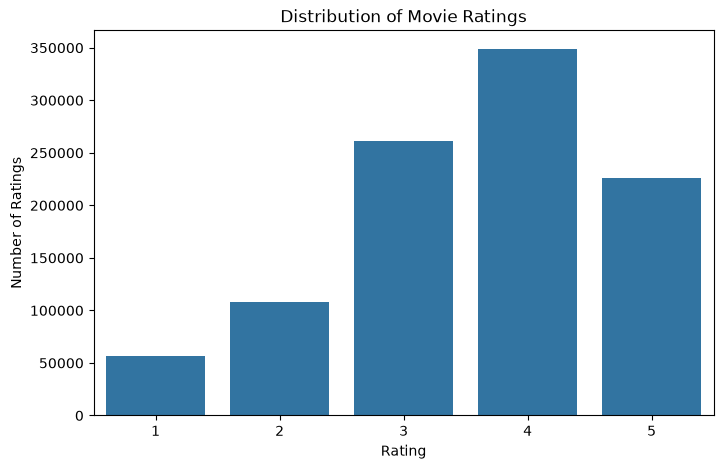

In [56]:
rating_counts = df["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

In [57]:
user_activity = df.groupby("user_id").size()

user_activity.head()

user_id
1     53
2    129
3     51
4     21
5    198
dtype: int64

In [58]:
user_activity.describe()

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64

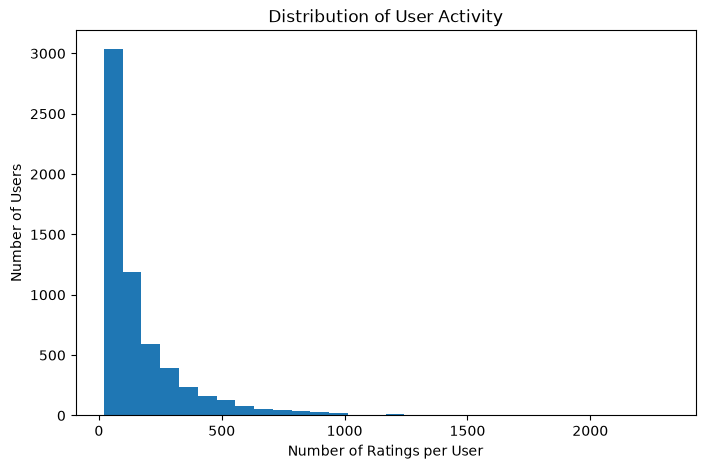

In [59]:
plt.figure(figsize=(8, 5))

plt.hist(user_activity, bins=30)

plt.title("Distribution of User Activity")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")

plt.show()

In [60]:
user_movie_count = df.groupby("user_id")["movie_id"].nunique()

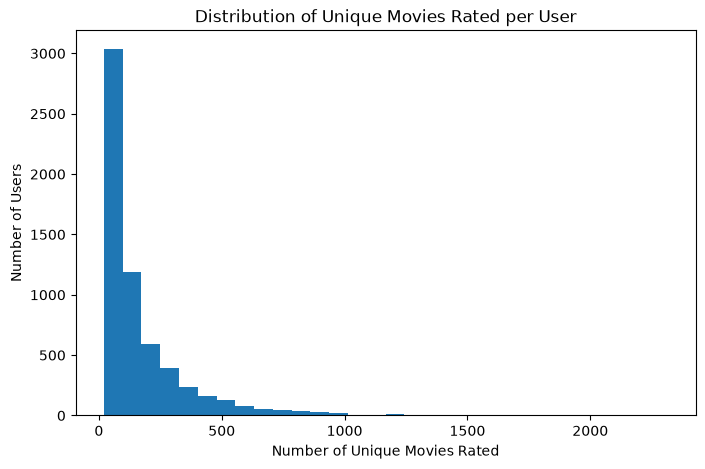

In [61]:
plt.figure(figsize=(8, 5))

plt.hist(user_movie_count, bins=30)

plt.title("Distribution of Unique Movies Rated per User")
plt.xlabel("Number of Unique Movies Rated")
plt.ylabel("Number of Users")

plt.show()

In [62]:
age_rating = (
    df.groupby("age")["rating"]
    .agg(["count", "mean"])
    .reset_index()
)

age_rating

,age,count,mean
0,1,27211,3.549520
1,18,183536,3.507573
2,25,395556,3.545235
3,35,199003,3.618162
4,45,83633,3.638062
5,50,72490,3.714512
6,56,38780,3.766632


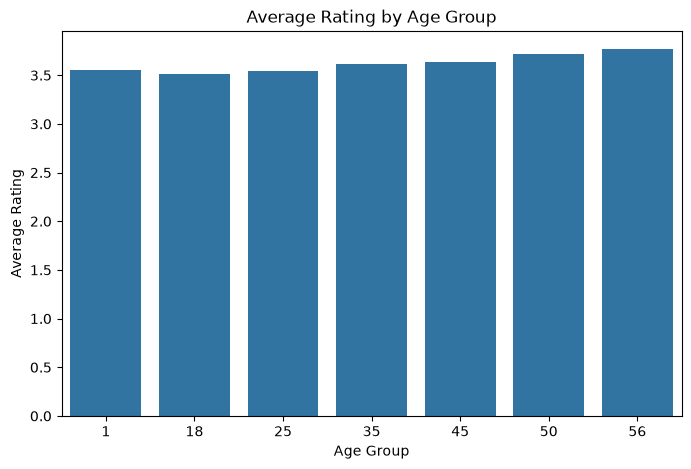

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=age_rating,
    x="age",
    y="mean"
)

plt.title("Average Rating by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Rating")

plt.show()

In [64]:
gender_rating = (
    df.groupby("gender")["rating"]
    .agg(["count", "mean"])
    .reset_index()
)

gender_rating

,gender,count,mean
0,F,246440,3.620366
1,M,753769,3.568879


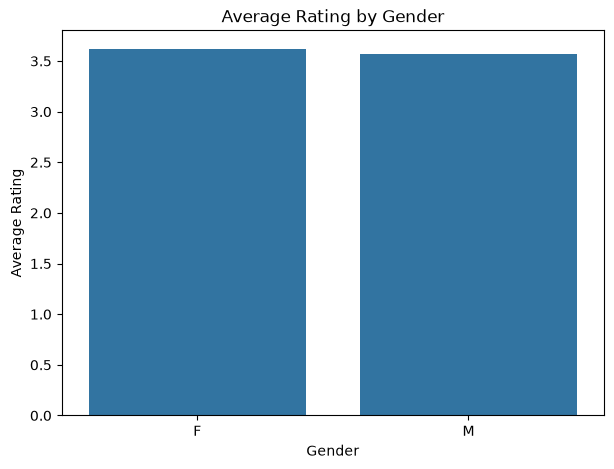

In [65]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_rating,
    x="gender",
    y="mean"
)

plt.title("Average Rating by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Rating")

plt.show()

In [66]:
ratings_over_time = (
    df.groupby("year")
    .size()
    .reset_index(name="rating_count")
)

ratings_over_time

,year,rating_count
0,2000,904757
1,2001,68058
2,2002,24046
3,2003,3348


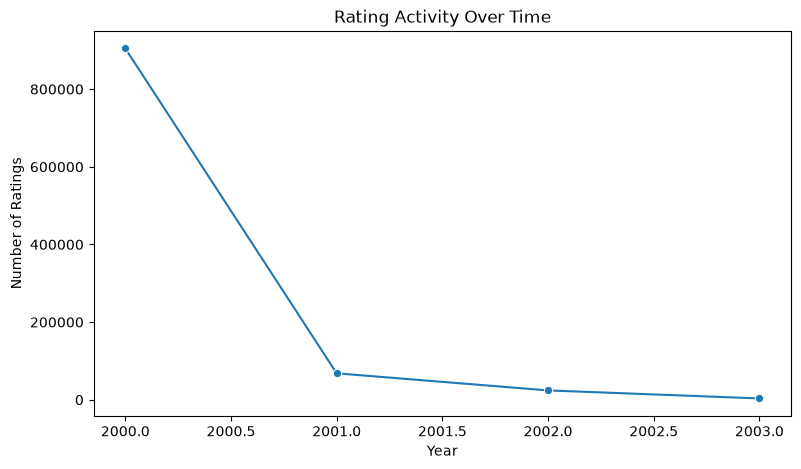

In [67]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=ratings_over_time,
    x="year",
    y="rating_count",
    marker="o"
)

plt.title("Rating Activity Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")

plt.show()

In [68]:
movie_genres = df[["movie_id", "genre"]].drop_duplicates()

In [69]:
movie_genres["genre"] = movie_genres["genre"].str.split("|")

In [70]:
movie_genres = movie_genres.explode("genre")

In [71]:
movie_genres

,movie_id,genre
0,1193,Drama
1,661,Animation
1,661,Children's
1,661,Musical
2,914,Musical
...,...,...
957826,2845,Drama
970914,3607,Comedy
970914,3607,Drama
970914,3607,Western


In [72]:
genre_counts = (
    movie_genres.groupby("genre")
    .size()
    .sort_values(ascending=False)
)

genre_counts

genre
Drama          1493
Comedy         1163
Action          495
Thriller        485
Romance         459
Horror          339
Adventure       281
Sci-Fi          274
Children's      250
Crime           201
War             141
Musical         113
Documentary     110
Animation       105
Mystery         104
Fantasy          68
Western          67
Film-Noir        44
dtype: int64

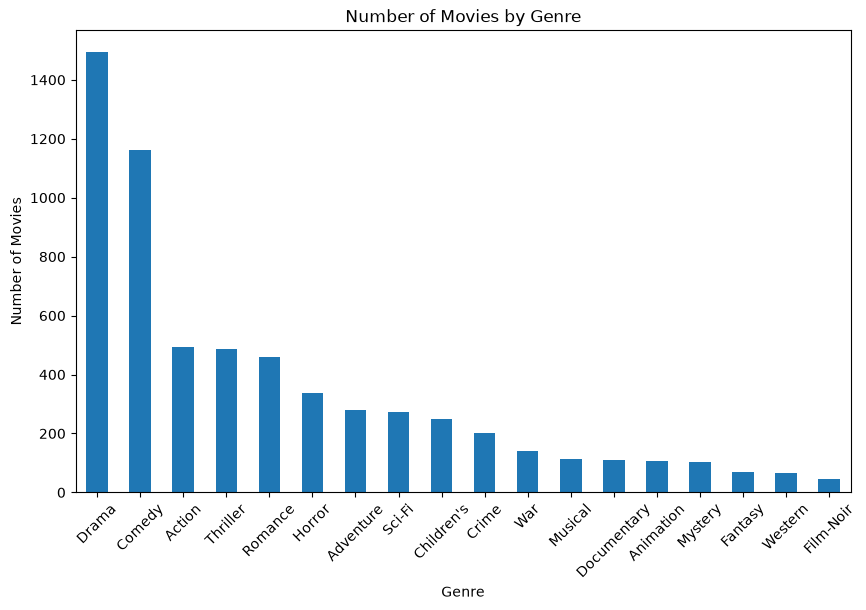

In [73]:
plt.figure(figsize=(10, 6))

genre_counts.plot(kind="bar")

plt.title("Number of Movies by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.show()

1. Genre Popularity by Number of Ratings
genre
Comedy         356580
Drama          354529
Action         257457
Thriller       189680
Sci-Fi         157294
Romance        147523
Adventure      133953
Crime           79541
Horror          76386
Children's      72186
War             68527
Animation       43293
Musical         41533
Mystery         40178
Fantasy         36301
Western         20683
Film-Noir       18261
Documentary      7910
dtype: int64



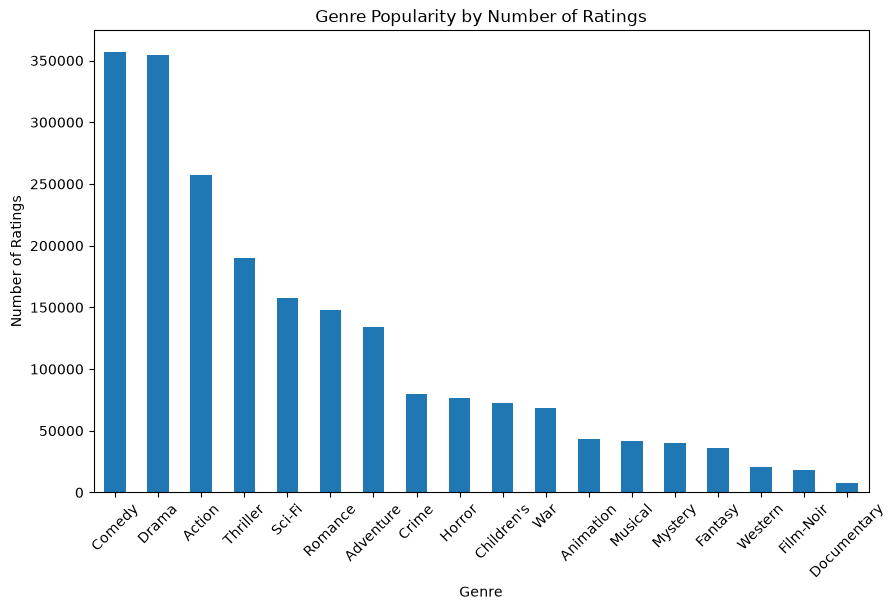

1. Genre Popularity by Number of Ratings
genre
Comedy         356580
Drama          354529
Action         257457
Thriller       189680
Sci-Fi         157294
Romance        147523
Adventure      133953
Crime           79541
Horror          76386
Children's      72186
War             68527
Animation       43293
Musical         41533
Mystery         40178
Fantasy         36301
Western         20683
Film-Noir       18261
Documentary      7910
dtype: int64



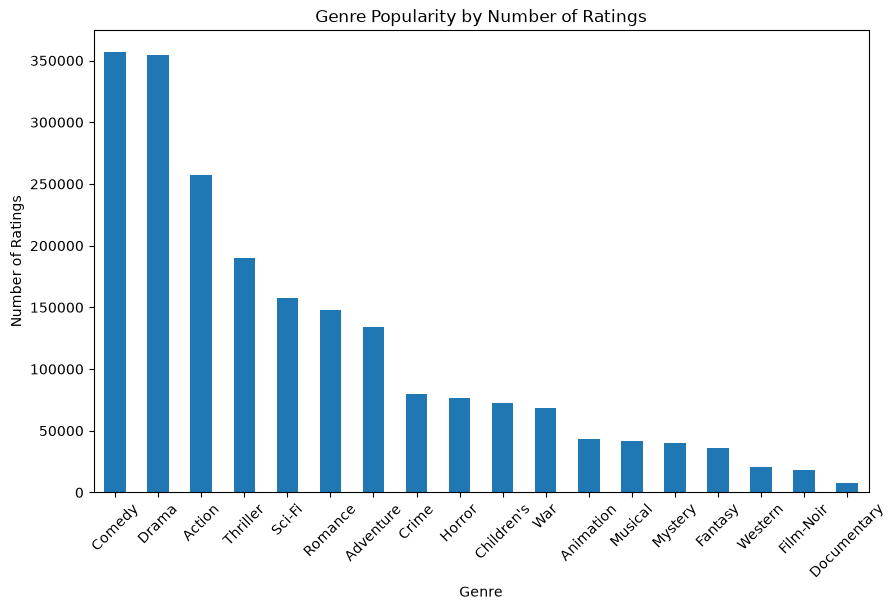

2. Genre vs Average Rating
              count      mean
genre                        
Film-Noir     18261  4.075188
Documentary    7910  3.933123
War           68527  3.893327
Drama        354529  3.766332
Crime         79541  3.708679
Animation     43293  3.684868
Mystery       40178  3.668102
Musical       41533  3.665519
Western       20683  3.637770
Romance      147523  3.607465
Thriller     189680  3.570466
Comedy       356580  3.522099
Action       257457  3.491185
Adventure    133953  3.477257
Sci-Fi       157294  3.466521
Fantasy       36301  3.447371
Children's    72186  3.422035
Horror        76386  3.215013



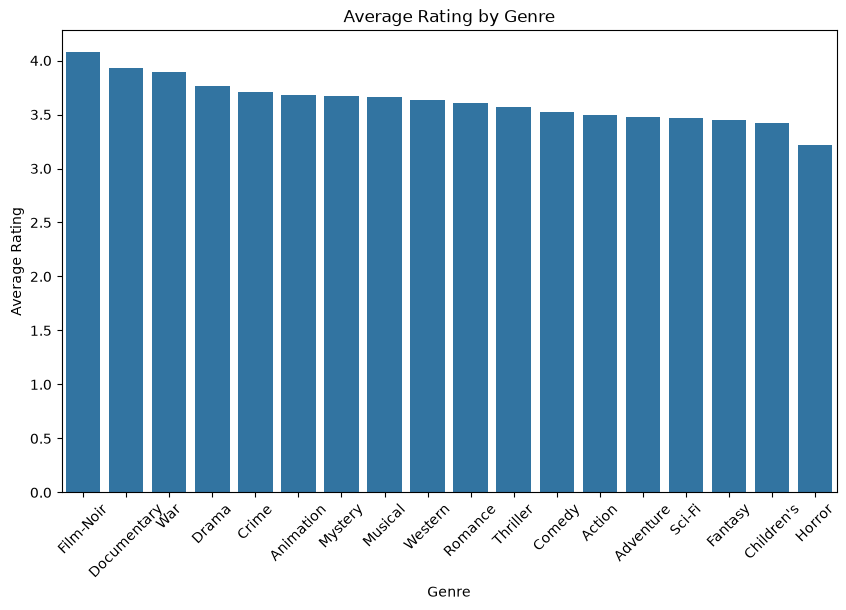

1. Genre Popularity by Number of Ratings
genre
Comedy         356580
Drama          354529
Action         257457
Thriller       189680
Sci-Fi         157294
Romance        147523
Adventure      133953
Crime           79541
Horror          76386
Children's      72186
War             68527
Animation       43293
Musical         41533
Mystery         40178
Fantasy         36301
Western         20683
Film-Noir       18261
Documentary      7910
dtype: int64



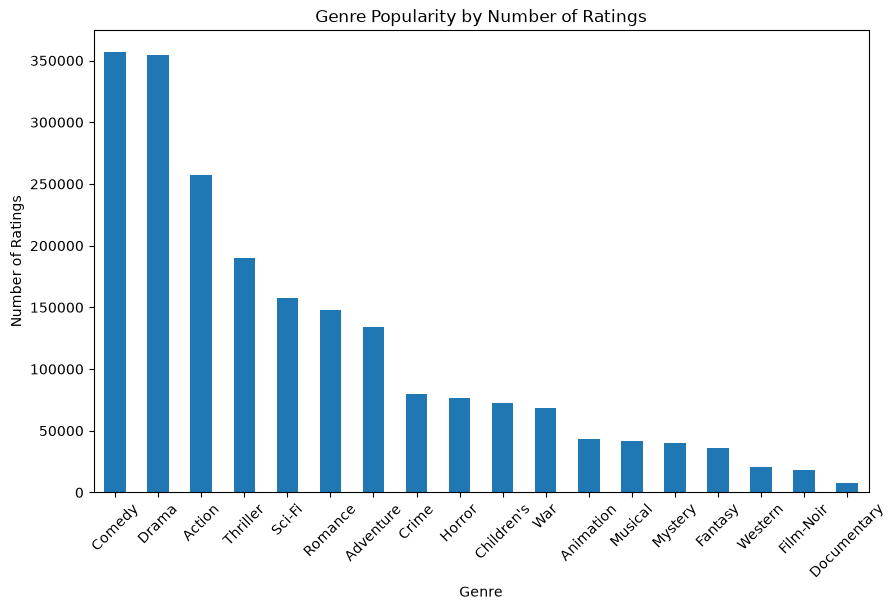

2. Genre vs Average Rating
              count      mean
genre                        
Film-Noir     18261  4.075188
Documentary    7910  3.933123
War           68527  3.893327
Drama        354529  3.766332
Crime         79541  3.708679
Animation     43293  3.684868
Mystery       40178  3.668102
Musical       41533  3.665519
Western       20683  3.637770
Romance      147523  3.607465
Thriller     189680  3.570466
Comedy       356580  3.522099
Action       257457  3.491185
Adventure    133953  3.477257
Sci-Fi       157294  3.466521
Fantasy       36301  3.447371
Children's    72186  3.422035
Horror        76386  3.215013



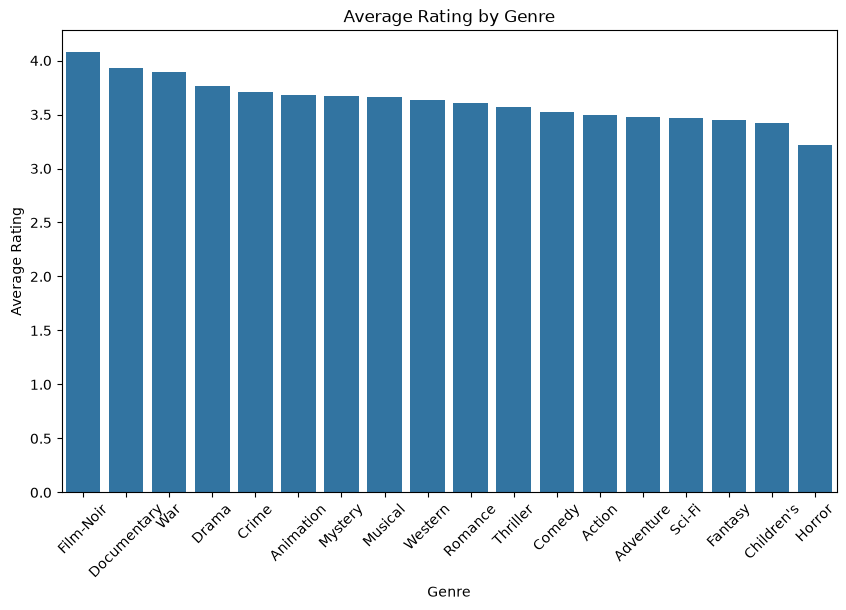

3. Rating Activity Over Time
   year  rating_count
0  2000        904757
1  2001         68058
2  2002         24046
3  2003          3348



1. Genre Popularity by Number of Ratings
genre
Comedy         356580
Drama          354529
Action         257457
Thriller       189680
Sci-Fi         157294
Romance        147523
Adventure      133953
Crime           79541
Horror          76386
Children's      72186
War             68527
Animation       43293
Musical         41533
Mystery         40178
Fantasy         36301
Western         20683
Film-Noir       18261
Documentary      7910
dtype: int64



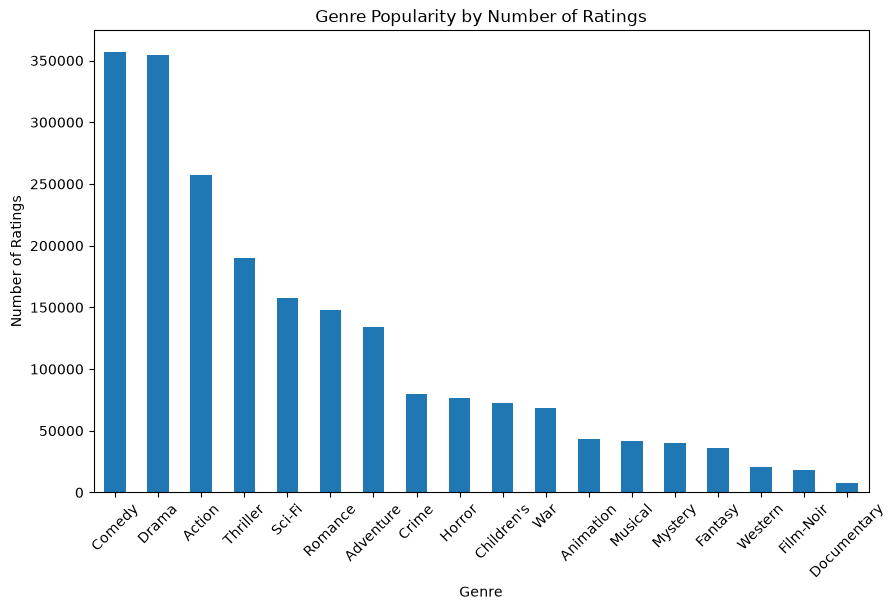

2. Genre vs Average Rating
              count      mean
genre                        
Film-Noir     18261  4.075188
Documentary    7910  3.933123
War           68527  3.893327
Drama        354529  3.766332
Crime         79541  3.708679
Animation     43293  3.684868
Mystery       40178  3.668102
Musical       41533  3.665519
Western       20683  3.637770
Romance      147523  3.607465
Thriller     189680  3.570466
Comedy       356580  3.522099
Action       257457  3.491185
Adventure    133953  3.477257
Sci-Fi       157294  3.466521
Fantasy       36301  3.447371
Children's    72186  3.422035
Horror        76386  3.215013



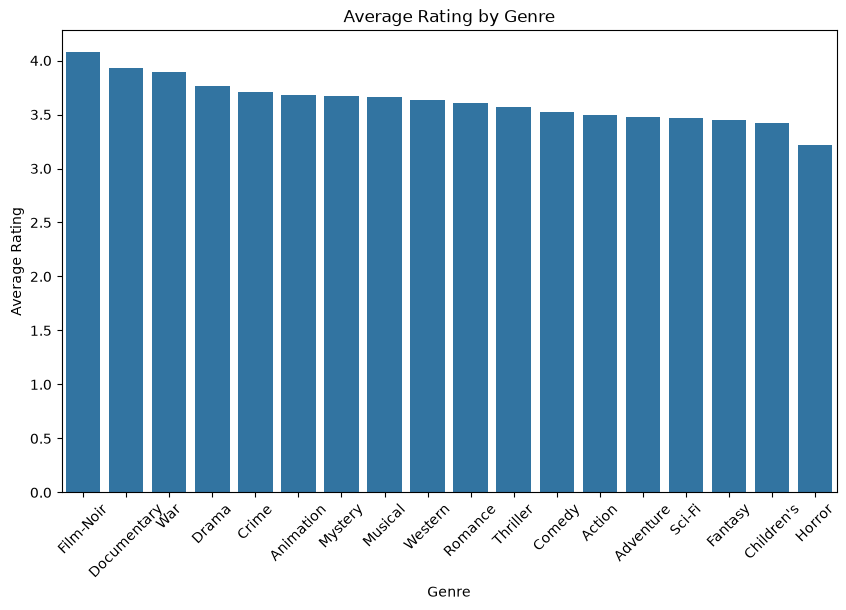

3. Rating Activity Over Time
   year  rating_count
0  2000        904757
1  2001         68058
2  2002         24046
3  2003          3348



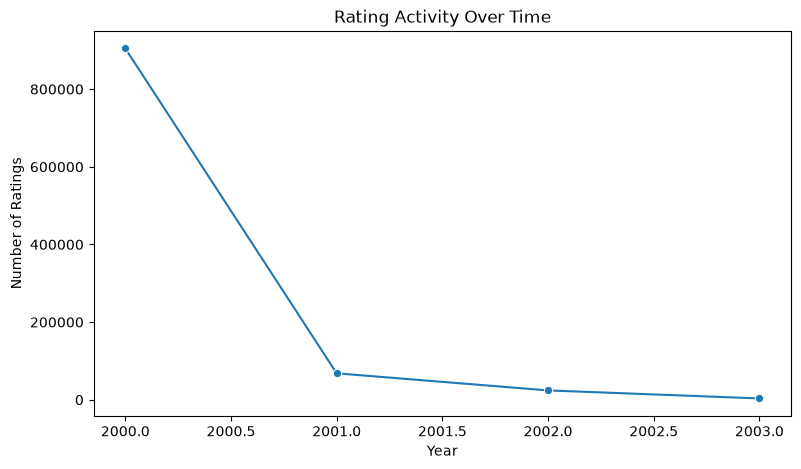

1. Genre Popularity by Number of Ratings
genre
Comedy         356580
Drama          354529
Action         257457
Thriller       189680
Sci-Fi         157294
Romance        147523
Adventure      133953
Crime           79541
Horror          76386
Children's      72186
War             68527
Animation       43293
Musical         41533
Mystery         40178
Fantasy         36301
Western         20683
Film-Noir       18261
Documentary      7910
dtype: int64



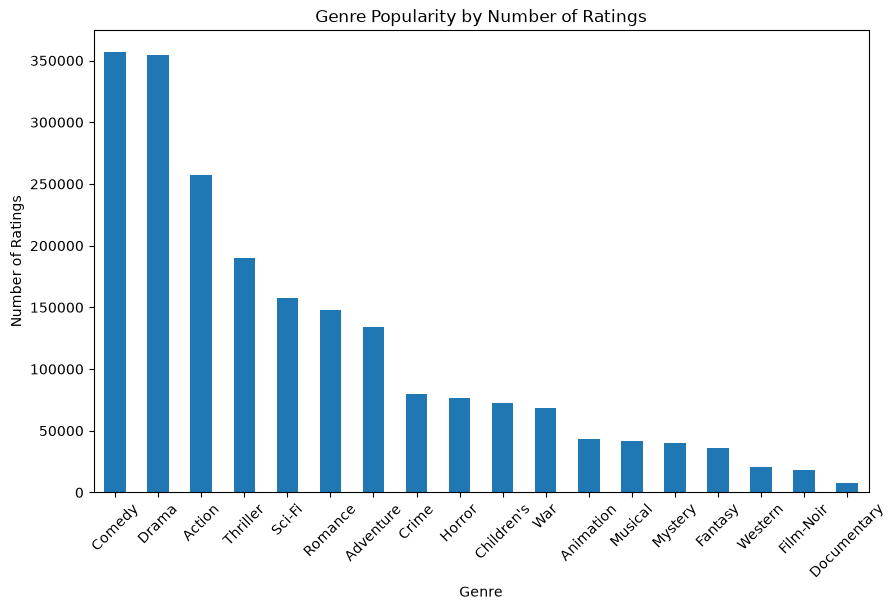

2. Genre vs Average Rating
              count      mean
genre                        
Film-Noir     18261  4.075188
Documentary    7910  3.933123
War           68527  3.893327
Drama        354529  3.766332
Crime         79541  3.708679
Animation     43293  3.684868
Mystery       40178  3.668102
Musical       41533  3.665519
Western       20683  3.637770
Romance      147523  3.607465
Thriller     189680  3.570466
Comedy       356580  3.522099
Action       257457  3.491185
Adventure    133953  3.477257
Sci-Fi       157294  3.466521
Fantasy       36301  3.447371
Children's    72186  3.422035
Horror        76386  3.215013



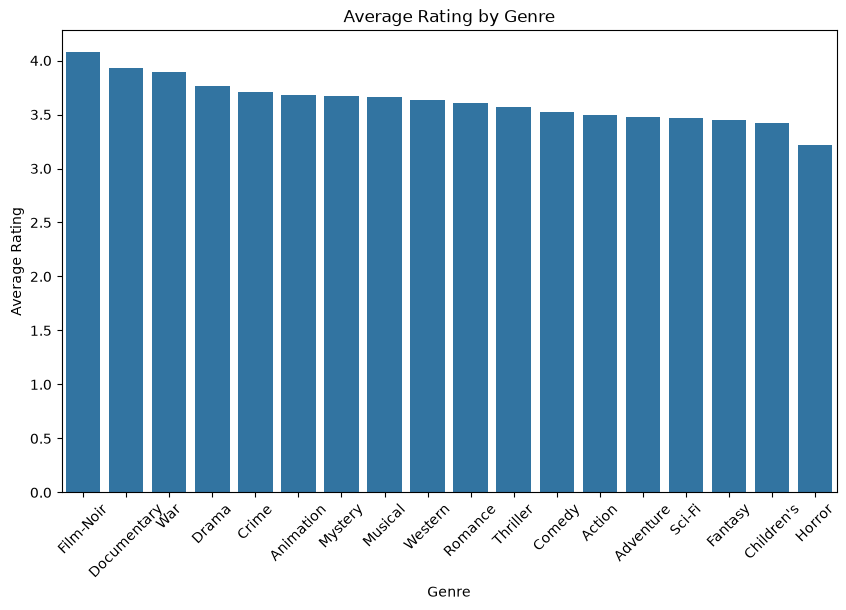

3. Rating Activity Over Time
   year  rating_count
0  2000        904757
1  2001         68058
2  2002         24046
3  2003          3348



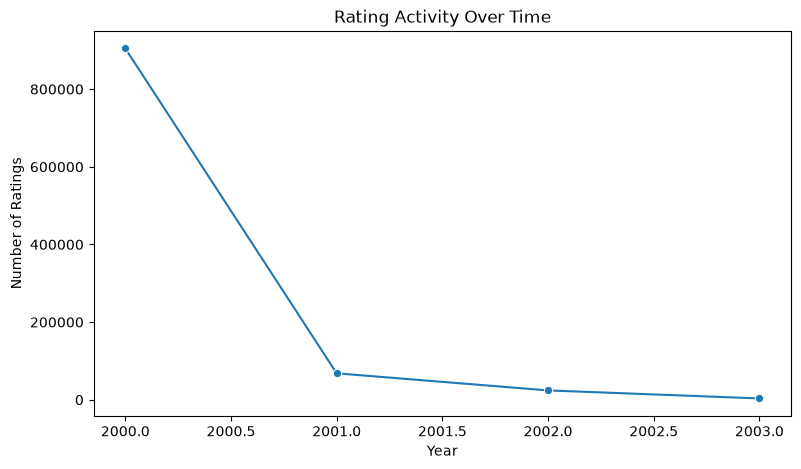

4. Movie Popularity vs Rating Quality
      movie_id                                         movie_name  \
2651      2858                             American Beauty (1999)   
253        260          Star Wars: Episode IV - A New Hope (1977)   
1106      1196  Star Wars: Episode V - The Empire Strikes Back...   
1120      1210  Star Wars: Episode VI - Return of the Jedi (1983)   
466        480                               Jurassic Park (1993)   
1848      2028                         Saving Private Ryan (1998)   
575        589                  Terminator 2: Judgment Day (1991)   
2374      2571                                 Matrix, The (1999)   
1178      1270                          Back to the Future (1985)   
579        593                   Silence of the Lambs, The (1991)   

      rating_count  avg_rating  
2651          3428    4.317386  
253           2991    4.453694  
1106          2990    4.292977  
1120          2883    4.022893  
466           2672    3.763847  
1848

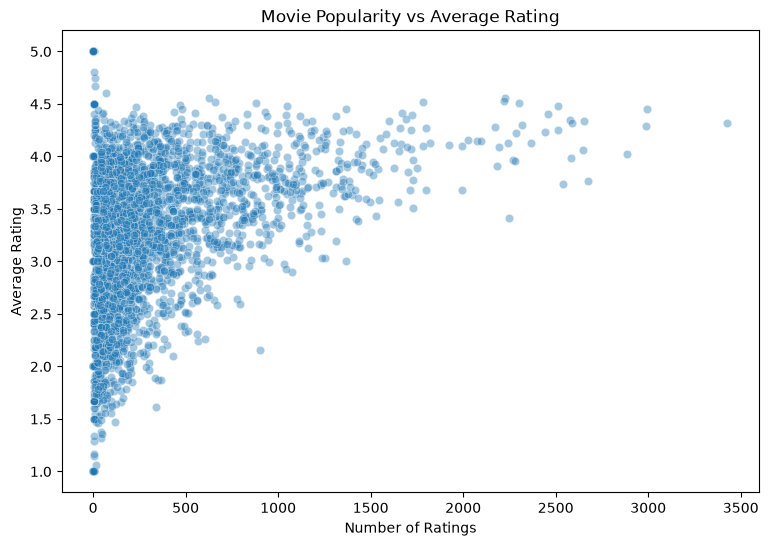

In [74]:
# ============================================================
# EDA — Remaining 4 Analyses
# ============================================================

# ------------------------------------------------------------
# 1. Genre Popularity by Number of Ratings
# ------------------------------------------------------------

genre_ratings = (
    df[["movie_id", "genre"]]
    .drop_duplicates()
    .assign(genre=lambda x: x["genre"].str.split("|"))
    .explode("genre")
    .merge(
        df[["movie_id", "rating"]],
        on="movie_id",
        how="left"
    )
    .groupby("genre")
    .size()
    .sort_values(ascending=False)
)

print("1. Genre Popularity by Number of Ratings")
print(genre_ratings)
print()

plt.figure(figsize=(10, 6))
genre_ratings.plot(kind="bar")
plt.title("Genre Popularity by Number of Ratings")
plt.xlabel("Genre")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 2. Genre vs Average Rating
# ------------------------------------------------------------

genre_avg_rating = (
    df[["movie_id", "genre"]]
    .drop_duplicates()
    .assign(genre=lambda x: x["genre"].str.split("|"))
    .explode("genre")
    .merge(
        df[["movie_id", "rating"]],
        on="movie_id",
        how="left"
    )
    .groupby("genre")["rating"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

print("2. Genre vs Average Rating")
print(genre_avg_rating)
print()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=genre_avg_rating.reset_index(),
    x="genre",
    y="mean"
)
plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 3. Rating Activity Over Time
# ------------------------------------------------------------

ratings_over_time = (
    df.groupby("year")
    .size()
    .reset_index(name="rating_count")
)

print("3. Rating Activity Over Time")
print(ratings_over_time)
print()

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=ratings_over_time,
    x="year",
    y="rating_count",
    marker="o"
)
plt.title("Rating Activity Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.show()


# ------------------------------------------------------------
# 4. Movie Popularity vs Rating Quality
# ------------------------------------------------------------

movie_stats = (
    df.groupby(["movie_id", "movie_name"])
    .agg(
        rating_count=("rating", "count"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)

print("4. Movie Popularity vs Rating Quality")
print(movie_stats.sort_values("rating_count", ascending=False).head(10))
print()

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=movie_stats,
    x="rating_count",
    y="avg_rating",
    alpha=0.4
)
plt.title("Movie Popularity vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

In [75]:
import pandas as pd
import numpy as np
from pathlib import Path

project_root = Path.cwd().resolve()
for candidate in [project_root, project_root / "..", project_root / ".." / ".."]:
    stream_file = candidate / "data" / "raw" / "stream_data.csv"
    if stream_file.exists():
        project_root = candidate.resolve()
        break

SOURCE = project_root / "data" / "raw" / "stream_data.csv"
EVENT_PATH = project_root / "data" / "raw" / "simulated_ott_events.csv"
OUT_DIR = project_root / "data" / "raw" / "StreamSight_Day2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

source = pd.read_csv(SOURCE, low_memory=False)
events = pd.read_csv(EVENT_PATH, low_memory=False)
source["datetime"] = pd.to_datetime(source["datetime"])
events["event_timestamp"] = pd.to_datetime(events["event_timestamp"])

# -----------------------------
# 1. Factual MovieLens features
# -----------------------------
user_features = (
    source.groupby("user_id")
    .agg(
        rating_count=("movie_id", "size"),
        unique_movies=("movie_id", "nunique"),
        average_rating=("rating", "mean"),
        first_rating_date=("datetime", "min"),
        last_rating_date=("datetime", "max"),
    )
    .reset_index()
)

project_end = source["datetime"].max()
user_features["recency_days"] = (
    project_end - user_features["last_rating_date"]
).dt.days
user_features["active_span_days"] = (
    user_features["last_rating_date"] -
    user_features["first_rating_date"]
).dt.days

# -----------------------------
# 2. Simulated OTT features
# -----------------------------
engaged = events[events["event_type"] != "impression"].copy()

sim_features = (
    engaged.groupby("user_id")
    .agg(
        simulated_sessions=("session_id", "nunique"),
        simulated_events=("event_id", "count"),
        simulated_plays=("event_type", lambda x: (x == "play").sum()),
        simulated_completes=("event_type", lambda x: (x == "complete").sum()),
    )
    .reset_index()
)

play_events = events[events["event_type"] == "play"]
watch_features = (
    play_events.groupby("user_id")
    .agg(
        simulated_watch_seconds=("watch_seconds", "sum"),
        simulated_avg_watch_seconds=("watch_seconds", "mean"),
    )
    .reset_index()
)

user_features = (
    user_features
    .merge(sim_features, on="user_id", how="left")
    .merge(watch_features, on="user_id", how="left")
)

sim_cols = [
    "simulated_sessions", "simulated_events", "simulated_plays",
    "simulated_completes", "simulated_watch_seconds",
    "simulated_avg_watch_seconds"
]
user_features[sim_cols] = user_features[sim_cols].fillna(0)

user_features["simulated_completion_rate"] = np.where(
    user_features["simulated_plays"] > 0,
    user_features["simulated_completes"] / user_features["simulated_plays"],
    0
)

engaged["date"] = engaged["event_timestamp"].dt.date
engagement_days = engaged.groupby("user_id")["date"].nunique()
event_span = engaged.groupby("user_id")["event_timestamp"].agg(
    lambda x: max((x.max() - x.min()).days, 1)
)

user_features["simulated_engagement_days"] = (
    user_features["user_id"].map(engagement_days).fillna(0)
)
user_features["simulated_event_span_days"] = (
    user_features["user_id"].map(event_span).fillna(0)
)
user_features["simulated_engagement_frequency"] = np.where(
    user_features["simulated_event_span_days"] > 0,
    user_features["simulated_engagement_days"] /
    user_features["simulated_event_span_days"],
    0
)
user_features["simulated_plays_per_session"] = np.where(
    user_features["simulated_sessions"] > 0,
    user_features["simulated_plays"] /
    user_features["simulated_sessions"],
    0
)
user_features["simulated_watch_hours"] = (
    user_features["simulated_watch_seconds"] / 3600
)

# -----------------------------
# 3. Genre preference features
#    Derived from factual MovieLens genre labels.
# -----------------------------
genre_long = (
    source[["user_id", "rating", "genre"]]
    .assign(genre=lambda x: x["genre"].str.split("|"))
    .explode("genre")
)

genre_counts = (
    genre_long.groupby(["user_id", "genre"])
    .size()
    .rename("genre_ratings")
    .reset_index()
)

genre_counts = genre_counts.merge(
    user_features[["user_id", "rating_count"]],
    on="user_id",
    how="left"
)
genre_counts["genre_share"] = (
    genre_counts["genre_ratings"] / genre_counts["rating_count"]
)

genre_wide = genre_counts.pivot(
    index="user_id",
    columns="genre",
    values="genre_share"
).fillna(0)

genre_wide.columns = [
    "genre_pref_" + str(c).lower().replace(" ", "_").replace("-", "_")
    for c in genre_wide.columns
]
genre_wide = genre_wide.reset_index()

user_features = user_features.merge(
    genre_wide, on="user_id", how="left"
)

# Dates are stored as readable strings.
user_features["first_rating_date"] = user_features["first_rating_date"].dt.strftime("%Y-%m-%d")
user_features["last_rating_date"] = user_features["last_rating_date"].dt.strftime("%Y-%m-%d")

feature_path = OUT_DIR / "user_features.csv"
user_features.to_csv(feature_path, index=False)

print("DAY 2 — USER FEATURE TABLE COMPLETE")
print("-----------------------------------")
print(f"Users: {len(user_features):,}")

print(f"Features: {len(user_features.columns):,}")

print("\nFeature groups:")
print("\nSaved:", feature_path)

print("1. Factual MovieLens: ratings, unique movies, average rating, recency")
print("4. Derived behavior: completion rate, engagement frequency, plays/session")

print("2. Factual genre preferences: genre share per user")
print("3. SIMULATED OTT: sessions, events, plays, completions, watch time")

DAY 2 — USER FEATURE TABLE COMPLETE
-----------------------------------
Users: 6,040
Features: 38

Feature groups:

Saved: C:\Users\suche\Downloads\StreamSight\data\raw\StreamSight_Day2\user_features.csv
1. Factual MovieLens: ratings, unique movies, average rating, recency
4. Derived behavior: completion rate, engagement frequency, plays/session
2. Factual genre preferences: genre share per user
3. SIMULATED OTT: sessions, events, plays, completions, watch time


STREAMSIGHT — DAY 2
Product Analytics + User Segmentation

Input:
C:\Users\suche\Downloads\StreamSight\data\raw\stream_data.csv

Output directory:
C:\Users\suche\Downloads\StreamSight\data\day2

STEP 1 — LOAD RAW DATA
Rows: 1,000,209
Columns: 16
Users: 6,040
Movies: 3,706

STEP 2 — SIMULATE CONTENT DURATION
Movies with simulated duration: 3,706

STEP 3 — CREATE SIMULATED SESSIONS
Simulated sessions: 25,163

STEP 4 — SIMULATE OTT ENGAGEMENT EVENTS

STEP 5 — EVENT LAYER VALIDATION
Total events: 1,862,370
Unique users: 6,040
Unique movies: 3,706
Unique sessions: 25,163

Event counts:
event_type
impression    1000209
click          378505
play           301012
complete       182644
Name: count, dtype: int64

Saved:
C:\Users\suche\Downloads\StreamSight\data\day2\simulated_ott_events.csv.gz

STEP 6 — PRODUCT ANALYTICS

PRODUCT METRICS
--------------------------------------------------
impressions                        : 1,000,209.00
clicks                             : 378,505.00
plays     

STREAMSIGHT — DAY 2
Product Analytics + User Segmentation

Input:
C:\Users\suche\Downloads\StreamSight\data\raw\stream_data.csv

Output directory:
C:\Users\suche\Downloads\StreamSight\data\day2

STEP 1 — LOAD RAW DATA
Rows: 1,000,209
Columns: 16
Users: 6,040
Movies: 3,706

STEP 2 — SIMULATE CONTENT DURATION
Movies with simulated duration: 3,706

STEP 3 — CREATE SIMULATED SESSIONS
Simulated sessions: 25,163

STEP 4 — SIMULATE OTT ENGAGEMENT EVENTS

STEP 5 — EVENT LAYER VALIDATION
Total events: 1,862,370
Unique users: 6,040
Unique movies: 3,706
Unique sessions: 25,163

Event counts:
event_type
impression    1000209
click          378505
play           301012
complete       182644
Name: count, dtype: int64

Saved:
C:\Users\suche\Downloads\StreamSight\data\day2\simulated_ott_events.csv.gz

STEP 6 — PRODUCT ANALYTICS

PRODUCT METRICS
--------------------------------------------------
impressions                        : 1,000,209.00
clicks                             : 378,505.00
plays     

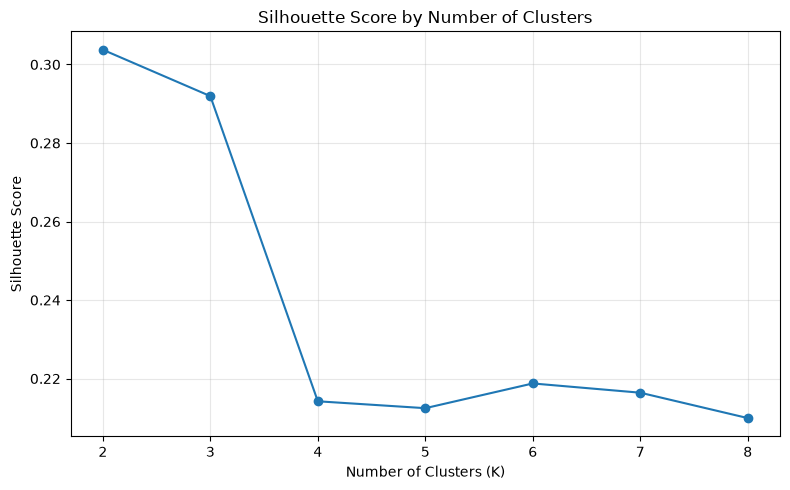

STREAMSIGHT — DAY 2
Product Analytics + User Segmentation

Input:
C:\Users\suche\Downloads\StreamSight\data\raw\stream_data.csv

Output directory:
C:\Users\suche\Downloads\StreamSight\data\day2

STEP 1 — LOAD RAW DATA
Rows: 1,000,209
Columns: 16
Users: 6,040
Movies: 3,706

STEP 2 — SIMULATE CONTENT DURATION
Movies with simulated duration: 3,706

STEP 3 — CREATE SIMULATED SESSIONS
Simulated sessions: 25,163

STEP 4 — SIMULATE OTT ENGAGEMENT EVENTS

STEP 5 — EVENT LAYER VALIDATION
Total events: 1,862,370
Unique users: 6,040
Unique movies: 3,706
Unique sessions: 25,163

Event counts:
event_type
impression    1000209
click          378505
play           301012
complete       182644
Name: count, dtype: int64

Saved:
C:\Users\suche\Downloads\StreamSight\data\day2\simulated_ott_events.csv.gz

STEP 6 — PRODUCT ANALYTICS

PRODUCT METRICS
--------------------------------------------------
impressions                        : 1,000,209.00
clicks                             : 378,505.00
plays     

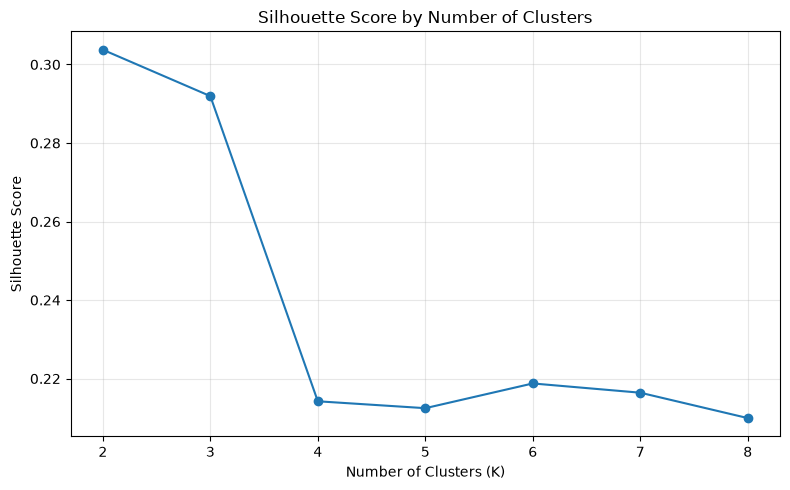

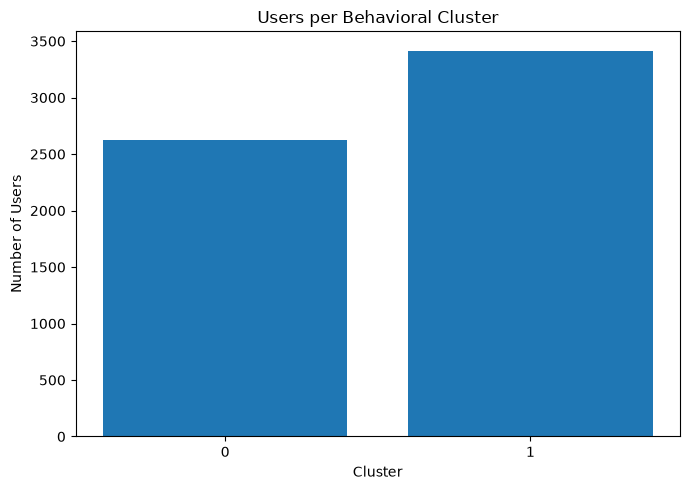

STREAMSIGHT — DAY 2
Product Analytics + User Segmentation

Input:
C:\Users\suche\Downloads\StreamSight\data\raw\stream_data.csv

Output directory:
C:\Users\suche\Downloads\StreamSight\data\day2

STEP 1 — LOAD RAW DATA
Rows: 1,000,209
Columns: 16
Users: 6,040
Movies: 3,706

STEP 2 — SIMULATE CONTENT DURATION
Movies with simulated duration: 3,706

STEP 3 — CREATE SIMULATED SESSIONS
Simulated sessions: 25,163

STEP 4 — SIMULATE OTT ENGAGEMENT EVENTS

STEP 5 — EVENT LAYER VALIDATION
Total events: 1,862,370
Unique users: 6,040
Unique movies: 3,706
Unique sessions: 25,163

Event counts:
event_type
impression    1000209
click          378505
play           301012
complete       182644
Name: count, dtype: int64

Saved:
C:\Users\suche\Downloads\StreamSight\data\day2\simulated_ott_events.csv.gz

STEP 6 — PRODUCT ANALYTICS

PRODUCT METRICS
--------------------------------------------------
impressions                        : 1,000,209.00
clicks                             : 378,505.00
plays     

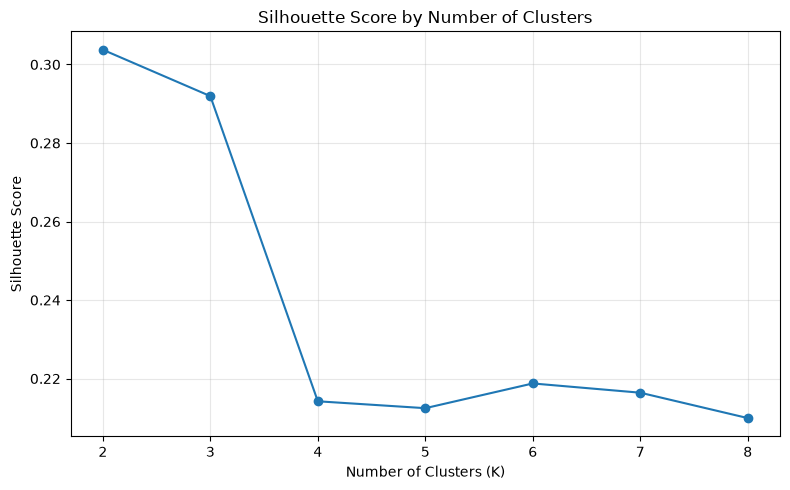

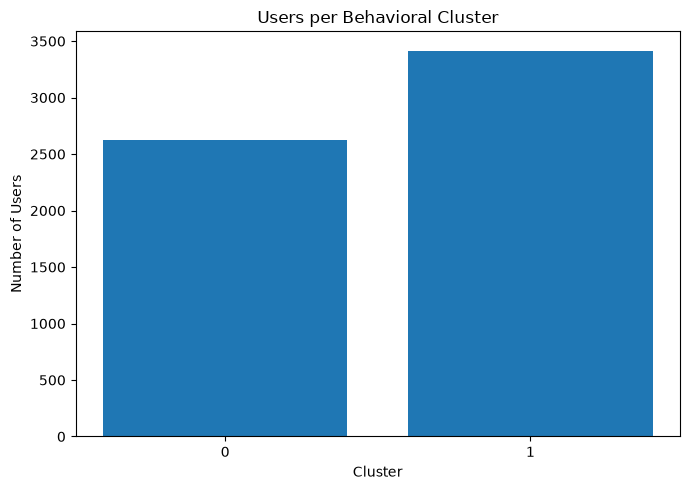



DAY 2 COMPLETE

Users: 6,040
Movies: 3,706
Sessions: 25,163
Events: 1,862,370
Selected K: 2
CTR: 37.84%
Play Rate: 79.53%
Completion Rate: 60.68%
Watch Hours: 405,191.0
D7 Retention Proxy: 28.58%

Output files:
  ✓ C:\Users\suche\Downloads\StreamSight\data\day2\simulated_ott_events.csv.gz
  ✓ C:\Users\suche\Downloads\StreamSight\data\day2\product_metrics.csv
  ✓ C:\Users\suche\Downloads\StreamSight\data\day2\user_features.csv
  ✓ C:\Users\suche\Downloads\StreamSight\data\day2\user_features_with_clusters.csv
  ✓ C:\Users\suche\Downloads\StreamSight\data\day2\segmentation_k_selection.csv
  ✓ C:\Users\suche\Downloads\StreamSight\data\day2\segmentation_cluster_profiles.csv
  ✓ C:\Users\suche\Downloads\StreamSight\data\day2\segmentation_cluster_top_genres.csv
  ✓ C:\Users\suche\Downloads\StreamSight\data\day2\silhouette_scores.png
  ✓ C:\Users\suche\Downloads\StreamSight\data\day2\cluster_sizes.png

NEXT: DAY 3 — RECOMMENDATION SYSTEM + OFFLINE EVALUATION


In [76]:
# ============================================================
# STREAMSIGHT — DAY 2
# Product Analytics + User Segmentation
# ============================================================
#
# INPUT:
#   data/raw/stream_data.csv
#
# OUTPUT:
#   data/day2/simulated_ott_events.csv.gz
#   data/day2/product_metrics.csv
#   data/day2/user_features.csv
#   data/day2/user_features_with_clusters.csv
#   data/day2/segmentation_k_selection.csv
#   data/day2/segmentation_cluster_profiles.csv
#   data/day2/segmentation_cluster_top_genres.csv
#
# IMPORTANT:
#   MovieLens data = factual source data.
#   OTT events, sessions, watch time, clicks, plays and
#   completions = SIMULATED for this project.
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 42

rng = np.random.default_rng(SEED)

# Project structure
PROJECT_DIR = Path.cwd().resolve()

candidate_roots = [
    PROJECT_DIR,
    PROJECT_DIR / "..",
    PROJECT_DIR / ".." / "..",
]

for candidate in candidate_roots:
    if (candidate / "data" / "raw" / "stream_data.csv").exists():
        PROJECT_DIR = candidate.resolve()
        break

RAW_DIR = PROJECT_DIR / "data" / "raw"
OUTPUT_DIR = PROJECT_DIR / "data" / "day2"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

INPUT_FILE = (
    RAW_DIR
    / "stream_data.csv"
)

EVENT_FILE = (
    OUTPUT_DIR
    / "simulated_ott_events.csv.gz"
)

print("=" * 70)
print("STREAMSIGHT — DAY 2")
print("Product Analytics + User Segmentation")
print("=" * 70)

print("\nInput:")
print(INPUT_FILE)

print("\nOutput directory:")
print(OUTPUT_DIR)


# ============================================================
# 3. LOAD DAY 1 RAW DATA
# ============================================================

if not INPUT_FILE.exists():

    raise FileNotFoundError(
        f"\nCould not find:\n{INPUT_FILE}\n\n"
        "Make sure your Day 1 raw dataset exists at:\n"
        "data/raw/stream_data.csv"
    )


df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

print("\n" + "=" * 70)
print("STEP 1 — LOAD RAW DATA")
print("=" * 70)

print(
    f"Rows: {len(df):,}"
)

print(
    f"Columns: {len(df.columns):,}"
)

print(
    f"Users: {df['user_id'].nunique():,}"
)

print(
    f"Movies: {df['movie_id'].nunique():,}"
)


# ============================================================
# 4. PREPARE BASE MOVIELENS DATA
# ============================================================

base = df[
    [
        "user_id",
        "movie_id",
        "rating",
        "datetime"
    ]
].copy()

base["datetime"] = pd.to_datetime(
    base["datetime"]
)

base = base.sort_values(
    [
        "user_id",
        "datetime"
    ]
).reset_index(
    drop=True
)


# ============================================================
# 5. SIMULATE MOVIE DURATION
# ============================================================
#
# MovieLens does not provide runtime.
#
# Therefore:
#   content_duration_seconds = SIMULATED
#
# We generate durations between approximately
# 60 and 180 minutes.
#
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 — SIMULATE CONTENT DURATION")
print("=" * 70)

movie_ids = base[
    "movie_id"
].unique()

durations = pd.DataFrame(
    {
        "movie_id": movie_ids,

        "content_duration_seconds": np.clip(
            rng.normal(
                loc=6600,
                scale=1200,
                size=len(movie_ids)
            ),
            3600,
            10800
        )
        .round()
        .astype(int)
    }
)

base = base.merge(
    durations,
    on="movie_id",
    how="left"
)

print(
    f"Movies with simulated duration: "
    f"{len(durations):,}"
)


# ============================================================
# 6. CREATE SIMULATED SESSIONS
# ============================================================
#
# A new session begins if the gap between two user
# interactions is greater than 30 minutes.
#
# Session definition is a project assumption.
#
# ============================================================

print("\n" + "=" * 70)
print("STEP 3 — CREATE SIMULATED SESSIONS")
print("=" * 70)

gap_minutes = (
    base
    .groupby("user_id")["datetime"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

base["new_session"] = (
    gap_minutes.isna()
    |
    (gap_minutes > 30)
)

base["session_number"] = (
    base
    .groupby("user_id")[
        "new_session"
    ]
    .cumsum()
    .astype(int)
)

base["session_id"] = (
    base["user_id"].astype(str)
    + "_S"
    + base["session_number"].astype(str)
)

print(
    f"Simulated sessions: "
    f"{base['session_id'].nunique():,}"
)


# ============================================================
# 7. SIMULATE IMPRESSION → CLICK → PLAY → COMPLETE
# ============================================================
#
# IMPORTANT:
# These are NOT real OTT events.
#
# We use MovieLens ratings as a behavioral signal and
# simulate a plausible OTT engagement layer.
#
# ============================================================

print("\n" + "=" * 70)
print("STEP 4 — SIMULATE OTT ENGAGEMENT EVENTS")
print("=" * 70)

ratings = base[
    "rating"
].to_numpy()

n = len(base)


# ------------------------------------------------------------
# Impression → Click
# ------------------------------------------------------------

p_click = np.clip(
    0.12
    +
    0.10 * (ratings - 1),
    0.05,
    0.60
)

clicked = (
    rng.random(n)
    < p_click
)


# ------------------------------------------------------------
# Click → Play
# ------------------------------------------------------------

p_play_given_click = np.clip(
    0.65
    +
    0.05 * (ratings - 1),
    0.55,
    0.90
)

played = (
    clicked
    &
    (
        rng.random(n)
        < p_play_given_click
    )
)


# ------------------------------------------------------------
# Play → Complete
# ------------------------------------------------------------

p_complete_given_play = np.clip(
    0.25
    +
    0.12 * (ratings - 1),
    0.20,
    0.80
)

completed = (
    played
    &
    (
        rng.random(n)
        < p_complete_given_play
    )
)


# ============================================================
# 8. SIMULATE WATCH DURATION
# ============================================================

duration = (
    base[
        "content_duration_seconds"
    ].to_numpy()
)

watch_fraction = np.zeros(
    n
)


# Completed content:
# 85%–100% watched

idx_complete = np.where(
    completed
)[0]

watch_fraction[
    idx_complete
] = rng.uniform(
    0.85,
    1.00,
    len(idx_complete)
)


# Incomplete content:
# 10%–80% watched

idx_partial = np.where(
    played
    &
    ~completed
)[0]

watch_fraction[
    idx_partial
] = rng.uniform(
    0.10,
    0.80,
    len(idx_partial)
)


watch_seconds = (
    duration
    *
    watch_fraction
).round().astype(int)


# ============================================================
# 9. SIMULATE EVENT TIMESTAMPS
# ============================================================
#
# MovieLens timestamp is treated as an anchor.
# OTT event timestamps themselves are simulated.
#
# ============================================================

browse_minutes = rng.uniform(
    1,
    10,
    n
)

click_delay_seconds = rng.uniform(
    5,
    120,
    n
)

play_delay_seconds = rng.uniform(
    2,
    30,
    n
)

rating_gap_seconds = rng.uniform(
    30,
    600,
    n
)


# Impression

impression_time = (
    base["datetime"]
    -
    pd.to_timedelta(
        watch_seconds
        +
        browse_minutes * 60
        +
        click_delay_seconds
        +
        play_delay_seconds
        +
        rating_gap_seconds,
        unit="s"
    )
)


# Click

click_time = (
    impression_time
    +
    pd.to_timedelta(
        browse_minutes * 60,
        unit="s"
    )
)


# Play

play_time = (
    click_time
    +
    pd.to_timedelta(
        click_delay_seconds,
        unit="s"
    )
)


# Completion

complete_time = (
    play_time
    +
    pd.to_timedelta(
        watch_seconds,
        unit="s"
    )
)


# ============================================================
# 10. CREATE EVENT TABLES
# ============================================================

common_cols = [
    "user_id",
    "movie_id",
    "session_id",
    "content_duration_seconds"
]

event_tables = []


# ------------------------------------------------------------
# IMPRESSION
# ------------------------------------------------------------

impressions = base[
    common_cols
].copy()

impressions["event_type"] = (
    "impression"
)

impressions["event_timestamp"] = (
    impression_time
)

impressions["watch_seconds"] = 0

event_tables.append(
    impressions
)


# ------------------------------------------------------------
# CLICK
# ------------------------------------------------------------

click_events = base.loc[
    clicked,
    common_cols
].copy()

click_events["event_type"] = (
    "click"
)

click_events["event_timestamp"] = (
    click_time[clicked]
)

click_events["watch_seconds"] = 0

event_tables.append(
    click_events
)


# ------------------------------------------------------------
# PLAY
# ------------------------------------------------------------

play_events = base.loc[
    played,
    common_cols
].copy()

play_events["event_type"] = (
    "play"
)

play_events["event_timestamp"] = (
    play_time[played]
)

play_events["watch_seconds"] = (
    watch_seconds[played]
)

event_tables.append(
    play_events
)


# ------------------------------------------------------------
# COMPLETE
# ------------------------------------------------------------

complete_events = base.loc[
    completed,
    common_cols
].copy()

complete_events["event_type"] = (
    "complete"
)

complete_events["event_timestamp"] = (
    complete_time[completed]
)

complete_events["watch_seconds"] = (
    watch_seconds[completed]
)

event_tables.append(
    complete_events
)


# ============================================================
# 11. COMBINE EVENTS
# ============================================================

events = pd.concat(
    event_tables,
    ignore_index=True
)

events["event_timestamp"] = (
    pd.to_datetime(
        events["event_timestamp"]
    )
    .dt.floor("s")
)

events.insert(
    0,
    "event_id",
    np.arange(
        1,
        len(events) + 1,
        dtype=np.int64
    )
)

events = events.sort_values(
    [
        "user_id",
        "event_timestamp",
        "event_id"
    ]
).reset_index(
    drop=True
)


# ============================================================
# 12. EVENT VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 5 — EVENT LAYER VALIDATION")
print("=" * 70)

print(
    f"Total events: "
    f"{len(events):,}"
)

print(
    f"Unique users: "
    f"{events['user_id'].nunique():,}"
)

print(
    f"Unique movies: "
    f"{events['movie_id'].nunique():,}"
)

print(
    f"Unique sessions: "
    f"{events['session_id'].nunique():,}"
)

print("\nEvent counts:")

print(
    events[
        "event_type"
    ].value_counts()
)


# ============================================================
# 13. SAVE EVENT DATA
# ============================================================

events.to_csv(
    EVENT_FILE,
    index=False,
    compression="gzip"
)

print(
    "\nSaved:"
)

print(
    EVENT_FILE
)


# ============================================================
# 14. PRODUCT ANALYTICS
# ============================================================

print("\n" + "=" * 70)
print("STEP 6 — PRODUCT ANALYTICS")
print("=" * 70)

event_counts = (
    events[
        "event_type"
    ].value_counts()
)

impressions_count = int(
    event_counts.get(
        "impression",
        0
    )
)

clicks_count = int(
    event_counts.get(
        "click",
        0
    )
)

plays_count = int(
    event_counts.get(
        "play",
        0
    )
)

completes_count = int(
    event_counts.get(
        "complete",
        0
    )
)


# ============================================================
# 15. CTR
# ============================================================

ctr = (
    clicks_count
    /
    impressions_count
    if impressions_count > 0
    else 0
)


# ============================================================
# 16. PLAY RATE
# ============================================================

play_rate = (
    plays_count
    /
    clicks_count
    if clicks_count > 0
    else 0
)


# ============================================================
# 17. COMPLETION RATE
# ============================================================

completion_rate = (
    completes_count
    /
    plays_count
    if plays_count > 0
    else 0
)


# ============================================================
# 18. WATCH TIME
# ============================================================
#
# IMPORTANT:
#
# Watch seconds are stored on PLAY events.
#
# COMPLETE events represent the terminal state of the
# same viewing episode.
#
# Therefore we DO NOT sum both play + complete events.
#
# ============================================================

play_events_only = events[
    events["event_type"]
    == "play"
].copy()

total_watch_seconds = (
    play_events_only[
        "watch_seconds"
    ].sum()
)

total_watch_hours = (
    total_watch_seconds
    /
    3600
)

avg_watch_minutes = (
    play_events_only[
        "watch_seconds"
    ].mean()
    /
    60
    if len(play_events_only) > 0
    else 0
)


# ============================================================
# 19. SESSION METRICS
# ============================================================

session_summary = (
    events
    .groupby("session_id")
    .agg(
        user_id=(
            "user_id",
            "first"
        ),

        start_time=(
            "event_timestamp",
            "min"
        ),

        event_count=(
            "event_id",
            "count"
        ),

        plays=(
            "event_type",
            lambda x:
                (x == "play").sum()
        ),

        completes=(
            "event_type",
            lambda x:
                (x == "complete").sum()
        )
    )
    .reset_index()
)

avg_events_per_session = (
    session_summary[
        "event_count"
    ].mean()
)

avg_plays_per_session = (
    session_summary[
        "plays"
    ].mean()
)


# ============================================================
# 20. DAILY ACTIVE USERS
# ============================================================

engagement_events = events[
    events["event_type"]
    != "impression"
].copy()

engagement_events["date"] = (
    engagement_events[
        "event_timestamp"
    ].dt.date
)

daily_active_users = (
    engagement_events
    .groupby("date")[
        "user_id"
    ]
    .nunique()
)

avg_daily_active_users = (
    daily_active_users.mean()
)

peak_daily_active_users = (
    daily_active_users.max()
)


# ============================================================
# 21. D7 RETENTION PROXY
# ============================================================
#
# This is NOT true production retention.
#
# It is a simulated behavioral return metric:
#
#   Did the user engage again >= 7 days after
#   their first simulated engagement?
#
# ============================================================

first_day = (
    engagement_events
    .groupby("user_id")[
        "date"
    ]
    .min()
    .rename(
        "cohort_date"
    )
)

engagement_events = (
    engagement_events
    .join(
        first_day,
        on="user_id"
    )
)

engagement_events[
    "days_since_first"
] = (
    pd.to_datetime(
        engagement_events[
            "date"
        ]
    )
    -
    pd.to_datetime(
        engagement_events[
            "cohort_date"
        ]
    )
).dt.days

cohort_d7 = (
    engagement_events[
        engagement_events[
            "days_since_first"
        ]
        >= 7
    ]
    .groupby(
        "cohort_date"
    )[
        "user_id"
    ]
    .nunique()
)

cohort_sizes = (
    first_day
    .groupby(first_day)
    .size()
)

d7_table = pd.concat(
    [
        cohort_sizes.rename(
            "cohort_users"
        ),

        cohort_d7.rename(
            "users_returned_d7"
        )
    ],
    axis=1
).fillna(0)

d7_table[
    "d7_retention_proxy"
] = (
    d7_table[
        "users_returned_d7"
    ]
    /
    d7_table[
        "cohort_users"
    ]
)

overall_d7 = (
    d7_table[
        "users_returned_d7"
    ].sum()
    /
    d7_table[
        "cohort_users"
    ].sum()
)


# ============================================================
# 22. PRODUCT METRICS TABLE
# ============================================================

metrics = {

    "impressions":
        impressions_count,

    "clicks":
        clicks_count,

    "plays":
        plays_count,

    "completes":
        completes_count,

    "ctr":
        ctr,

    "play_rate_given_click":
        play_rate,

    "completion_rate_given_play":
        completion_rate,

    "unique_users":
        events[
            "user_id"
        ].nunique(),

    "unique_movies":
        events[
            "movie_id"
        ].nunique(),

    "sessions":
        events[
            "session_id"
        ].nunique(),

    "total_watch_hours":
        total_watch_hours,

    "avg_watch_minutes_per_play":
        avg_watch_minutes,

    "avg_events_per_session":
        avg_events_per_session,

    "avg_plays_per_session":
        avg_plays_per_session,

    "avg_daily_active_users":
        avg_daily_active_users,

    "peak_daily_active_users":
        peak_daily_active_users,

    "d7_retention_proxy":
        overall_d7
}

metrics_df = pd.DataFrame(
    [
        {
            "metric": key,
            "value": value
        }

        for key, value
        in metrics.items()
    ]
)

metrics_df.to_csv(
    OUTPUT_DIR
    / "product_metrics.csv",
    index=False
)

print("\nPRODUCT METRICS")
print("-" * 50)

for key, value in metrics.items():

    if (
        "rate" in key
        or key == "ctr"
    ):

        print(
            f"{key:35s}: "
            f"{value:.2%}"
        )

    else:

        print(
            f"{key:35s}: "
            f"{value:,.2f}"
        )


# ============================================================
# 23. BUILD USER FEATURE TABLE
# ============================================================

print("\n" + "=" * 70)
print("STEP 7 — BUILD USER FEATURE TABLE")
print("=" * 70)

source = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

source["datetime"] = (
    pd.to_datetime(
        source["datetime"]
    )
)


# ============================================================
# 24. FACTUAL MOVIELENS USER FEATURES
# ============================================================

user_features = (
    source
    .groupby("user_id")
    .agg(

        rating_count=(
            "movie_id",
            "size"
        ),

        unique_movies=(
            "movie_id",
            "nunique"
        ),

        average_rating=(
            "rating",
            "mean"
        ),

        first_rating_date=(
            "datetime",
            "min"
        ),

        last_rating_date=(
            "datetime",
            "max"
        )
    )
    .reset_index()
)


# ============================================================
# 25. RECENCY
# ============================================================

project_end = (
    source["datetime"].max()
)

user_features[
    "recency_days"
] = (
    project_end
    -
    user_features[
        "last_rating_date"
    ]
).dt.days


# ============================================================
# 26. ACTIVE SPAN
# ============================================================

user_features[
    "active_span_days"
] = (
    user_features[
        "last_rating_date"
    ]
    -
    user_features[
        "first_rating_date"
    ]
).dt.days


# ============================================================
# 27. SIMULATED OTT USER FEATURES
# ============================================================

engaged = events[
    events["event_type"]
    != "impression"
].copy()

sim_features = (
    engaged
    .groupby("user_id")
    .agg(

        simulated_sessions=(
            "session_id",
            "nunique"
        ),

        simulated_events=(
            "event_id",
            "count"
        ),

        simulated_plays=(
            "event_type",
            lambda x:
                (x == "play").sum()
        ),

        simulated_completes=(
            "event_type",
            lambda x:
                (x == "complete").sum()
        )
    )
    .reset_index()
)


# ============================================================
# 28. USER WATCH TIME
# ============================================================

watch_features = (
    events[
        events["event_type"]
        == "play"
    ]
    .groupby("user_id")
    .agg(

        simulated_watch_seconds=(
            "watch_seconds",
            "sum"
        ),

        simulated_avg_watch_seconds=(
            "watch_seconds",
            "mean"
        )
    )
    .reset_index()
)


# ============================================================
# 29. MERGE FEATURES
# ============================================================

user_features = (
    user_features
    .merge(
        sim_features,
        on="user_id",
        how="left"
    )
    .merge(
        watch_features,
        on="user_id",
        how="left"
    )
)


sim_cols = [
    "simulated_sessions",
    "simulated_events",
    "simulated_plays",
    "simulated_completes",
    "simulated_watch_seconds",
    "simulated_avg_watch_seconds"
]

user_features[
    sim_cols
] = (
    user_features[
        sim_cols
    ]
    .fillna(0)
)


# ============================================================
# 30. USER COMPLETION RATE
# ============================================================

user_features[
    "simulated_completion_rate"
] = np.where(

    user_features[
        "simulated_plays"
    ] > 0,

    user_features[
        "simulated_completes"
    ]
    /
    user_features[
        "simulated_plays"
    ],

    0
)


# ============================================================
# 31. USER ENGAGEMENT FREQUENCY
# ============================================================

engaged["date"] = (
    engaged[
        "event_timestamp"
    ].dt.date
)

engagement_days = (
    engaged
    .groupby("user_id")[
        "date"
    ]
    .nunique()
)

event_span = (
    engaged
    .groupby("user_id")[
        "event_timestamp"
    ]
    .agg(
        lambda x:
            max(
                (
                    x.max()
                    -
                    x.min()
                ).days,
                1
            )
    )
)

user_features[
    "simulated_engagement_days"
] = (
    user_features[
        "user_id"
    ]
    .map(
        engagement_days
    )
    .fillna(0)
)

user_features[
    "simulated_event_span_days"
] = (
    user_features[
        "user_id"
    ]
    .map(
        event_span
    )
    .fillna(0)
)

user_features[
    "simulated_engagement_frequency"
] = np.where(

    user_features[
        "simulated_event_span_days"
    ] > 0,

    user_features[
        "simulated_engagement_days"
    ]
    /
    user_features[
        "simulated_event_span_days"
    ],

    0
)


# ============================================================
# 32. PLAYS PER SESSION
# ============================================================

user_features[
    "simulated_plays_per_session"
] = np.where(

    user_features[
        "simulated_sessions"
    ] > 0,

    user_features[
        "simulated_plays"
    ]
    /
    user_features[
        "simulated_sessions"
    ],

    0
)


# ============================================================
# 33. WATCH HOURS
# ============================================================

user_features[
    "simulated_watch_hours"
] = (
    user_features[
        "simulated_watch_seconds"
    ]
    /
    3600
)


# ============================================================
# 34. GENRE PREFERENCES
# ============================================================
#
# Genre information is derived from MovieLens.
#
# We split:
#
#   Action|Adventure|Sci-Fi
#
# into separate genres and calculate each user's
# proportion of ratings associated with each genre.
#
# ============================================================

print("\nCreating genre preference features...")

if "genre" in source.columns:

    genre_long = (
        source[
            [
                "user_id",
                "rating",
                "genre"
            ]
        ]
        .assign(
            genre=lambda x:
                x[
                    "genre"
                ].fillna("")
                .str.split("|")
        )
        .explode(
            "genre"
        )
    )

    genre_long[
        "genre"
    ] = (
        genre_long[
            "genre"
        ]
        .astype(str)
        .str.strip()
    )

    genre_long = genre_long[
        genre_long["genre"] != ""
    ]

    genre_counts = (
        genre_long
        .groupby(
            [
                "user_id",
                "genre"
            ]
        )
        .size()
        .rename(
            "genre_ratings"
        )
        .reset_index()
    )

    genre_counts = (
        genre_counts
        .merge(
            user_features[
                [
                    "user_id",
                    "rating_count"
                ]
            ],
            on="user_id",
            how="left"
        )
    )

    genre_counts[
        "genre_share"
    ] = (
        genre_counts[
            "genre_ratings"
        ]
        /
        genre_counts[
            "rating_count"
        ]
    )

    genre_wide = (
        genre_counts
        .pivot(
            index="user_id",
            columns="genre",
            values="genre_share"
        )
        .fillna(0)
    )

    genre_wide.columns = [
        "genre_pref_"
        +
        str(col)
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "-",
            "_"
        )

        for col
        in genre_wide.columns
    ]

    genre_wide = (
        genre_wide
        .reset_index()
    )

    user_features = (
        user_features
        .merge(
            genre_wide,
            on="user_id",
            how="left"
        )
    )


# ============================================================
# 35. SAVE USER FEATURES
# ============================================================

user_features[
    "first_rating_date"
] = pd.to_datetime(
    user_features[
        "first_rating_date"
    ]
).dt.strftime(
    "%Y-%m-%d"
)

user_features[
    "last_rating_date"
] = pd.to_datetime(
    user_features[
        "last_rating_date"
    ]
).dt.strftime(
    "%Y-%m-%d"
)

USER_FEATURE_FILE = (
    OUTPUT_DIR
    / "user_features.csv"
)

user_features.to_csv(
    USER_FEATURE_FILE,
    index=False
)

print(
    f"Users: "
    f"{len(user_features):,}"
)

print(
    f"Features: "
    f"{len(user_features.columns):,}"
)

print(
    "\nSaved:"
)

print(
    USER_FEATURE_FILE
)


# ============================================================
# 36. K-MEANS SEGMENTATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 8 — USER SEGMENTATION")
print("=" * 70)


# ------------------------------------------------------------
# Behavioral features
# ------------------------------------------------------------

segmentation_features = [

    "rating_count",

    "unique_movies",

    "average_rating",

    "recency_days",

    "simulated_sessions",

    "simulated_plays",

    "simulated_watch_hours",

    "simulated_completion_rate",

    "simulated_engagement_frequency",

    "simulated_plays_per_session"
]


X = user_features[
    segmentation_features
].copy()


# ============================================================
# 37. LOG TRANSFORM SKEWED FEATURES
# ============================================================

log_features = [

    "rating_count",

    "unique_movies",

    "simulated_sessions",

    "simulated_plays",

    "simulated_watch_hours",

    "simulated_plays_per_session"
]

for col in log_features:

    X[col] = np.log1p(
        X[col]
    )


# ============================================================
# 38. STANDARDIZE
# ============================================================

scaler = StandardScaler()

X_scaled = (
    scaler.fit_transform(X)
)


# ============================================================
# 39. TEST K = 2 THROUGH 8
# ============================================================

print(
    "\nTesting K values..."
)

scores = []

models = {}

for k in range(
    2,
    9
):

    model = KMeans(

        n_clusters=k,

        random_state=SEED,

        n_init=20
    )

    labels = (
        model
        .fit_predict(
            X_scaled
        )
    )

    score = (
        silhouette_score(
            X_scaled,
            labels
        )
    )

    scores.append(
        {
            "k": k,
            "silhouette_score":
                score
        }
    )

    models[k] = model


scores_df = pd.DataFrame(
    scores
)

print(
    "\nSilhouette scores:"
)

print(
    scores_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 40. SELECT BEST K
# ============================================================

best_k = int(
    scores_df.loc[
        scores_df[
            "silhouette_score"
        ].idxmax(),
        "k"
    ]
)

print(
    f"\nSelected K: {best_k}"
)


# ============================================================
# 41. FINAL K-MEANS MODEL
# ============================================================

final_model = (
    models[
        best_k
    ]
)

user_features[
    "cluster"
] = (
    final_model
    .labels_
)


# ============================================================
# 42. CLUSTER SIZE
# ============================================================

cluster_sizes = (
    user_features[
        "cluster"
    ]
    .value_counts()
    .sort_index()
    .rename(
        "users"
    )
    .to_frame()
)

cluster_sizes[
    "share"
] = (
    cluster_sizes[
        "users"
    ]
    /
    len(
        user_features
    )
)


print(
    "\nCluster sizes:"
)

print(
    cluster_sizes
    .round(4)
    .to_string()
)


# ============================================================
# 43. CLUSTER PROFILES
# ============================================================

cluster_profile = (
    user_features
    .groupby(
        "cluster"
    )[
        segmentation_features
    ]
    .agg(
        [
            "mean",
            "median"
        ]
    )
)

cluster_profile.columns = [
    f"{feature}_{stat}"
    for feature, stat
    in cluster_profile.columns
]

cluster_profile = (
    cluster_profile
    .reset_index()
)

cluster_profile = (
    cluster_sizes
    .reset_index()
    .merge(
        cluster_profile,
        on="cluster",
        how="left"
    )
)


# ============================================================
# 44. CLUSTER GENRE PREFERENCES
# ============================================================

genre_cols = [
    col
    for col
    in user_features.columns
    if col.startswith(
        "genre_pref_"
    )
]

cluster_genres = []

for cluster, group in (
    user_features
    .groupby("cluster")
):

    for col in genre_cols:

        cluster_genres.append(
            {
                "cluster":
                    cluster,

                "genre":
                    col.replace(
                        "genre_pref_",
                        ""
                    ),

                "avg_preference_share":
                    group[col].mean()
            }
        )


cluster_genres = pd.DataFrame(
    cluster_genres
)


top_genres = (
    cluster_genres
    .sort_values(
        [
            "cluster",
            "avg_preference_share"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "cluster"
    )
    .head(5)
    .reset_index(
        drop=True
    )
)


# ============================================================
# 45. SAVE SEGMENTATION OUTPUTS
# ============================================================

scores_df.to_csv(
    OUTPUT_DIR
    / "segmentation_k_selection.csv",
    index=False
)

cluster_profile.to_csv(
    OUTPUT_DIR
    / "segmentation_cluster_profiles.csv",
    index=False
)

user_features.to_csv(
    OUTPUT_DIR
    / "user_features_with_clusters.csv",
    index=False
)

top_genres.to_csv(
    OUTPUT_DIR
    / "segmentation_cluster_top_genres.csv",
    index=False
)


# ============================================================
# 46. PRINT TOP GENRES
# ============================================================

print(
    "\nTop genres by cluster:"
)

for cluster in sorted(
    top_genres[
        "cluster"
    ].unique()
):

    print(
        f"\nCluster {cluster}:"
    )

    part = (
        top_genres[
            top_genres[
                "cluster"
            ]
            == cluster
        ]
    )

    for _, row in (
        part.iterrows()
    ):

        print(
            f"  "
            f"{row['genre']:15s}"
            f" "
            f"{row['avg_preference_share']:.3f}"
        )


# ============================================================
# 47. OPTIONAL — SILHOUETTE PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    scores_df["k"],
    scores_df[
        "silhouette_score"
    ],
    marker="o"
)

plt.title(
    "Silhouette Score by Number of Clusters"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.xticks(
    scores_df["k"]
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "silhouette_scores.png",
    dpi=150
)

plt.show()


# ============================================================
# 48. OPTIONAL — CLUSTER SIZE PLOT
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    cluster_sizes.index.astype(str),
    cluster_sizes[
        "users"
    ]
)

plt.title(
    "Users per Behavioral Cluster"
)

plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "Number of Users"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "cluster_sizes.png",
    dpi=150
)

plt.show()


# ============================================================
# 49. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("DAY 2 COMPLETE")
print("=" * 70)

print(
    f"\nUsers: "
    f"{len(user_features):,}"
)

print(
    f"Movies: "
    f"{events['movie_id'].nunique():,}"
)

print(
    f"Sessions: "
    f"{events['session_id'].nunique():,}"
)

print(
    f"Events: "
    f"{len(events):,}"
)

print(
    f"Selected K: "
    f"{best_k}"
)

print(
    f"CTR: "
    f"{ctr:.2%}"
)

print(
    f"Play Rate: "
    f"{play_rate:.2%}"
)

print(
    f"Completion Rate: "
    f"{completion_rate:.2%}"
)

print(
    f"Watch Hours: "
    f"{total_watch_hours:,.1f}"
)

print(
    f"D7 Retention Proxy: "
    f"{overall_d7:.2%}"
)

print("\nOutput files:")

output_files = [

    "simulated_ott_events.csv.gz",

    "product_metrics.csv",

    "user_features.csv",

    "user_features_with_clusters.csv",

    "segmentation_k_selection.csv",

    "segmentation_cluster_profiles.csv",

    "segmentation_cluster_top_genres.csv",

    "silhouette_scores.png",

    "cluster_sizes.png"
]

for filename in output_files:

    print(
        "  ✓",
        OUTPUT_DIR / filename
    )

print("\n" + "=" * 70)
print("NEXT: DAY 3 — RECOMMENDATION SYSTEM + OFFLINE EVALUATION")
print("=" * 70)

In [77]:
# ============================================================
# StreamSight — Day 3
# Recommendation Systems + Time-Aware Offline Evaluation
# ============================================================
#
# Project:
#   StreamSight — MovieLens-based OTT analytics +
#   recommendation platform
#
# Day 3 goals:
#   1. Define recommendation problem
#   2. Create chronological train/test split
#   3. Popularity recommender
#   4. Content-based recommender
#   5. Collaborative filtering recommender
#   6. Hybrid recommender
#   7. Precision@K
#   8. Recall@K
#   9. MAP@K
#   10. NDCG@K
#   11. Model comparison
#   12. Recommendation examples
#   13. Cold-start analysis
#   14. Popularity-bias / catalog-coverage analysis
#
# IMPORTANT:
#   MovieLens is the factual data source.
#   OTT telemetry from Day 2 is simulated.
#   This file does NOT treat simulated OTT events as
#   real production telemetry.
#
# ============================================================

from pathlib import Path
import warnings
import json
import math

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore")


# ============================================================
# 0. CONFIGURATION
# ============================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

# If running from notebooks/, move one level up.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "raw"
DAY3_DIR = DATA_DIR / "day3"

DAY3_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROCESSED_DIR / "stream_data.csv"

# ------------------------------------------------------------
# Recommendation configuration
# ------------------------------------------------------------

# Positive feedback definition.
#
# MovieLens rating >= 4 is treated as a positive interaction.
#
# This definition is used consistently across:
#   - evaluation
#   - content-based user profiles
#   - collaborative filtering
#   - hybrid recommendations
#
POSITIVE_RATING_THRESHOLD = 4.0

# Number of recommendations.
K_VALUES = [5, 10, 20]

# Primary K for examples / reporting.
PRIMARY_K = 10

# Minimum history required for normal evaluation.
MIN_TRAIN_POSITIVE_INTERACTIONS = 2

# For users with very little history, recommendations are
# treated as cold/low-history cases.
COLD_START_MAX_TRAIN_INTERACTIONS = 1

# Number of recent positive items used in content profile.
CONTENT_PROFILE_MAX_ITEMS = 20

# Maximum number of candidate items considered by
# content-based and collaborative models.
#
# We keep this reasonably high for MovieLens 1M.
MAX_CANDIDATES = 1000

# Hybrid weights.
#
# The hybrid is intentionally simple and interpretable:
#
#   hybrid_score =
#       alpha * collaborative_score
#       +
#       (1-alpha) * content_score
#
# We evaluate several weights and retain the best one
# according to NDCG@10 on the validation set.
HYBRID_WEIGHTS = [0.25, 0.50, 0.75]


# ============================================================
# 1. UTILITY FUNCTIONS
# ============================================================

def print_section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def normalize_movie_id_column(df):
    """
    Standardize the movie identifier to movie_id.

    Existing StreamSight files are expected to contain movie_id,
    but this also handles common MovieLens naming variants.
    """

    if "movie_id" in df.columns:
        return df

    alternatives = [
        "movieId",
        "movie",
        "item_id",
        "itemId",
    ]

    for col in alternatives:
        if col in df.columns:
            df = df.rename(columns={col: "movie_id"})
            return df

    raise ValueError(
        "Could not find a movie identifier column. "
        f"Available columns: {list(df.columns)}"
    )


def normalize_user_id_column(df):
    """
    Standardize the user identifier to user_id.
    """

    if "user_id" in df.columns:
        return df

    alternatives = [
        "userId",
        "user",
    ]

    for col in alternatives:
        if col in df.columns:
            df = df.rename(columns={col: "user_id"})
            return df

    raise ValueError(
        "Could not find a user identifier column. "
        f"Available columns: {list(df.columns)}"
    )


def normalize_rating_column(df):
    """
    Standardize rating column to rating.
    """

    if "rating" in df.columns:
        return df

    alternatives = [
        "Rating",
        "score",
    ]

    for col in alternatives:
        if col in df.columns:
            df = df.rename(columns={col: "rating"})
            return df

    raise ValueError(
        "Could not find rating column. "
        f"Available columns: {list(df.columns)}"
    )


def normalize_timestamp_column(df):
    """
    Find a usable timestamp column.

    StreamSight Day 1/Day 2 uses timestamp/datetime.
    """

    if "timestamp" in df.columns:
        return df

    if "datetime" in df.columns:
        df["timestamp"] = pd.to_datetime(
            df["datetime"],
            errors="coerce"
        )
        return df

    alternatives = [
        "date",
        "event_timestamp",
        "created_at",
    ]

    for col in alternatives:
        if col in df.columns:
            df["timestamp"] = pd.to_datetime(
                df[col],
                errors="coerce"
            )
            return df

    raise ValueError(
        "Could not find a timestamp/datetime column. "
        f"Available columns: {list(df.columns)}"
    )


def minmax_normalize(scores):
    """
    Normalize scores to [0, 1].
    """

    scores = np.asarray(scores, dtype=float)

    if len(scores) == 0:
        return scores

    min_score = np.min(scores)
    max_score = np.max(scores)

    if max_score - min_score < 1e-12:
        return np.ones_like(scores)

    return (scores - min_score) / (max_score - min_score)


def dcg_at_k(relevance, k):
    """
    Discounted cumulative gain.
    """

    relevance = np.asarray(relevance[:k], dtype=float)

    if len(relevance) == 0:
        return 0.0

    discounts = np.log2(
        np.arange(2, len(relevance) + 2)
    )

    return np.sum(relevance / discounts)


def precision_at_k(recommended, relevant, k):
    """
    Precision@K

    Precision@K =
        relevant recommended items / K
    """

    recommended = recommended[:k]

    if k == 0:
        return 0.0

    hits = sum(
        1 for item in recommended
        if item in relevant
    )

    return hits / k


def recall_at_k(recommended, relevant, k):
    """
    Recall@K

    Recall@K =
        relevant recommended items /
        total relevant test items
    """

    if len(relevant) == 0:
        return 0.0

    recommended = recommended[:k]

    hits = sum(
        1 for item in recommended
        if item in relevant
    )

    return hits / len(relevant)


def average_precision_at_k(recommended, relevant, k):
    """
    Average Precision@K.

    This rewards relevant items appearing earlier
    in the ranking.
    """

    if len(relevant) == 0:
        return 0.0

    recommended = recommended[:k]

    score = 0.0
    hits = 0

    for i, item in enumerate(recommended, start=1):

        if item in relevant:

            hits += 1

            precision = hits / i

            score += precision

    denominator = min(len(relevant), k)

    if denominator == 0:
        return 0.0

    return score / denominator


def ndcg_at_k(recommended, relevant, k):
    """
    NDCG@K.

    For this implicit-ranking evaluation:
        relevant = 1
        non-relevant = 0
    """

    recommended = recommended[:k]

    relevance = [
        1 if item in relevant else 0
        for item in recommended
    ]

    dcg = dcg_at_k(relevance, k)

    ideal_hits = min(len(relevant), k)

    ideal_relevance = [1] * ideal_hits

    idcg = dcg_at_k(
        ideal_relevance,
        k
    )

    if idcg == 0:
        return 0.0

    return dcg / idcg


# ============================================================
# 2. LOAD DATA
# ============================================================

print_section("1. Loading StreamSight MovieLens Data")

if not INPUT_FILE.exists():

    raise FileNotFoundError(
        f"\nCould not find:\n{INPUT_FILE}\n\n"
        "Expected Day 1 output:\n"
        "data/processed/stream_data.csv\n\n"
        "Make sure you are running this from the StreamSight "
        "project directory and that Day 1/Day 2 outputs exist."
    )

df = pd.read_csv(INPUT_FILE)

print(f"Loaded: {INPUT_FILE}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

# Standardize identifiers.
df = normalize_movie_id_column(df)
df = normalize_user_id_column(df)
df = normalize_rating_column(df)
df = normalize_timestamp_column(df)

# Parse timestamp.
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

# Remove invalid rows.
df = df.dropna(
    subset=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp",
    ]
).copy()

# Ensure numeric identifiers.
df["user_id"] = pd.to_numeric(
    df["user_id"],
    errors="coerce"
)

df["movie_id"] = pd.to_numeric(
    df["movie_id"],
    errors="coerce"
)

df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "user_id",
        "movie_id",
        "rating",
    ]
).copy()

df["user_id"] = df["user_id"].astype(int)
df["movie_id"] = df["movie_id"].astype(int)

# Sort chronologically.
df = df.sort_values(
    ["user_id", "timestamp", "movie_id"]
).reset_index(drop=True)

print(f"Valid rows after cleaning: {len(df):,}")
print(f"Users: {df['user_id'].nunique():,}")
print(f"Movies: {df['movie_id'].nunique():,}")
print(
    f"Date range: "
    f"{df['timestamp'].min()} → {df['timestamp'].max()}"
)

# Save a small metadata report.
data_summary = pd.DataFrame({
    "metric": [
        "rows",
        "users",
        "movies",
        "min_timestamp",
        "max_timestamp",
        "positive_threshold",
    ],
    "value": [
        len(df),
        df["user_id"].nunique(),
        df["movie_id"].nunique(),
        str(df["timestamp"].min()),
        str(df["timestamp"].max()),
        POSITIVE_RATING_THRESHOLD,
    ]
})

data_summary.to_csv(
    DAY3_DIR / "data_summary.csv",
    index=False
)


# ============================================================
# 3. DEFINE POSITIVE INTERACTION
# ============================================================

print_section("2. Recommendation Problem Definition")

print(
    f"""
Recommendation task:

Given a user's historical MovieLens interactions,
rank movies that the user has NOT interacted with
in the evaluation period.

Positive interaction:
    rating >= {POSITIVE_RATING_THRESHOLD}

Negative/non-positive interaction:
    rating < {POSITIVE_RATING_THRESHOLD}

All recommendation models use the same positive-feedback
definition for consistency.
"""
)

df["is_positive"] = (
    df["rating"] >= POSITIVE_RATING_THRESHOLD
).astype(int)

positive_df = df[
    df["is_positive"] == 1
].copy()

print(
    f"Positive interactions: "
    f"{len(positive_df):,}"
)

print(
    f"Positive interaction rate: "
    f"{positive_df.shape[0] / len(df):.2%}"
)


# ============================================================
# 4. CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

print_section("3. Time-Aware Train/Test Split")

print(
    """
We use a chronological per-user split.

For each user:

    earlier interactions -> TRAIN
    latest positive interaction(s) -> TEST

This prevents future information from being used
to recommend the past.
"""
)

# ------------------------------------------------------------
# Strategy:
#
# For every user:
#   - sort by timestamp
#   - identify positive interactions
#   - latest positive interaction = test target
#   - all earlier interactions = train
#
# We also retain non-positive historical ratings in the
# training interaction set, because MovieLens is explicit
# feedback. However, the recommendation target itself is
# positive feedback.
#
# ------------------------------------------------------------

train_parts = []
test_parts = []

for user_id, user_df in df.groupby("user_id", sort=False):

    user_df = user_df.sort_values(
        ["timestamp", "movie_id"]
    ).copy()

    positive_user = user_df[
        user_df["is_positive"] == 1
    ]

    # If the user has fewer than 2 positive interactions,
    # we cannot create a useful train/test positive split.
    if len(positive_user) < 2:
        train_parts.append(user_df)
        continue

    # Latest positive interaction is test.
    test_row = positive_user.iloc[-1]

    test_timestamp = test_row["timestamp"]
    test_movie = test_row["movie_id"]

    # Everything before the test event belongs to train.
    train_user = user_df[
        user_df["timestamp"] < test_timestamp
    ].copy()

    # Prevent duplicate timestamp leakage.
    #
    # If there are multiple events at the same timestamp,
    # also make sure the test movie itself is not present
    # in train.
    train_user = train_user[
        train_user["movie_id"] != test_movie
    ]

    if len(train_user) == 0:
        continue

    train_parts.append(train_user)

    test_parts.append(
        pd.DataFrame([test_row])
    )

train_df = pd.concat(
    train_parts,
    ignore_index=True
)

test_df = pd.concat(
    test_parts,
    ignore_index=True
)

# Keep only test positives for ranking evaluation.
test_positive_df = test_df[
    test_df["is_positive"] == 1
].copy()

print(
    f"Train interactions: "
    f"{len(train_df):,}"
)

print(
    f"Test interactions: "
    f"{len(test_df):,}"
)

print(
    f"Test positive interactions: "
    f"{len(test_positive_df):,}"
)

print(
    f"Train users: "
    f"{train_df['user_id'].nunique():,}"
)

print(
    f"Test users: "
    f"{test_positive_df['user_id'].nunique():,}"
)

# Save split files.
train_df.to_csv(
    DAY3_DIR / "train_interactions.csv",
    index=False
)

test_df.to_csv(
    DAY3_DIR / "test_interactions.csv",
    index=False
)

test_positive_df.to_csv(
    DAY3_DIR / "test_positive_interactions.csv",
    index=False
)


# ============================================================
# 5. BUILD CORE SETS
# ============================================================

print_section("4. Building Recommendation Data Structures")

# Users with usable test targets.
evaluation_users = sorted(
    test_positive_df["user_id"].unique()
)

# All movies known to the system.
all_movies = sorted(
    df["movie_id"].unique()
)

all_movie_set = set(all_movies)

# Training interactions.
train_user_items = (
    train_df
    .groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

# Positive training interactions.
train_positive_df = train_df[
    train_df["is_positive"] == 1
].copy()

train_positive_user_items = (
    train_positive_df
    .groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

# Test positive targets.
test_user_items = (
    test_positive_df
    .groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

# Positive item popularity.
item_positive_counts = (
    train_positive_df
    .groupby("movie_id")
    .size()
    .sort_values(ascending=False)
)

# All training rating counts.
item_train_counts = (
    train_df
    .groupby("movie_id")
    .size()
    .sort_values(ascending=False)
)

# User history counts.
user_train_counts = (
    train_df
    .groupby("user_id")
    .size()
)

user_positive_train_counts = (
    train_positive_df
    .groupby("user_id")
    .size()
)

print(
    f"Evaluation users: "
    f"{len(evaluation_users):,}"
)

print(
    f"Unique catalog movies: "
    f"{len(all_movies):,}"
)


# ============================================================
# 6. MOVIE METADATA
# ============================================================

print_section("5. Preparing Movie Metadata")

# ------------------------------------------------------------
# We need:
#   movie_id
#   title
#   genres
#
# The existing StreamSight processed file may contain title
# and genres directly.
#
# ------------------------------------------------------------

metadata_columns = ["movie_id"]

for col in ["title", "genres"]:
    if col in df.columns:
        metadata_columns.append(col)

movie_metadata = (
    df[metadata_columns]
    .drop_duplicates("movie_id")
    .copy()
)

if "title" not in movie_metadata.columns:
    movie_metadata["title"] = (
        "Movie " +
        movie_metadata["movie_id"].astype(str)
    )

if "genres" not in movie_metadata.columns:
    movie_metadata["genres"] = ""

movie_metadata["title"] = (
    movie_metadata["title"]
    .fillna("")
    .astype(str)
)

movie_metadata["genres"] = (
    movie_metadata["genres"]
    .fillna("")
    .astype(str)
)

# Create text representation.
movie_metadata["content_text"] = (
    movie_metadata["title"]
    + " "
    + movie_metadata["genres"]
)

movie_metadata.to_csv(
    DAY3_DIR / "movie_metadata.csv",
    index=False
)

print(
    f"Metadata rows: "
    f"{len(movie_metadata):,}"
)


# ============================================================
# 7. POPULARITY RECOMMENDER
# ============================================================

print_section("6. Popularity Recommender")

print(
    """
Baseline logic:

Rank movies by the number of positive interactions
observed in TRAIN.

This is intentionally simple.

Every stronger recommender should beat this baseline
or provide a clear reason why it is preferable.
"""
)

# Popularity score:
#
# We use positive interaction count.
#
# A Bayesian average is not necessary for this baseline
# because the purpose is to establish a transparent
# benchmark.

popularity_ranking = (
    item_positive_counts
    .sort_values(
        ascending=False,
        kind="stable"
    )
)

popular_movies = popularity_ranking.index.tolist()

# Fallback if some items have no positive train interactions.
remaining_movies = [
    movie
    for movie in all_movies
    if movie not in set(popular_movies)
]

popular_movies.extend(remaining_movies)


def recommend_popularity(
    user_id,
    k=10
):
    """
    Recommend globally popular movies,
    excluding movies already seen by the user.
    """

    seen = train_user_items.get(
        user_id,
        set()
    )

    recommendations = []

    for movie_id in popular_movies:

        if movie_id in seen:
            continue

        recommendations.append(movie_id)

        if len(recommendations) >= k:
            break

    return recommendations


# ============================================================
# 8. CONTENT-BASED MODEL
# ============================================================

print_section("7. Content-Based Recommender")

print(
    """
Content-based recommendation:

1. Represent each movie using title + genres.
2. Convert metadata into TF-IDF vectors.
3. Build a user profile from movies the user rated positively.
4. Score unseen movies using cosine similarity to the
   user's profile.

This approach does not require other users.
"""
)

# ------------------------------------------------------------
# TF-IDF
# ------------------------------------------------------------

content_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1
)

content_matrix = content_vectorizer.fit_transform(
    movie_metadata["content_text"]
)

content_movie_ids = (
    movie_metadata["movie_id"]
    .tolist()
)

content_movie_to_idx = {
    movie_id: idx
    for idx, movie_id
    in enumerate(content_movie_ids)
}

print(
    f"Content matrix shape: "
    f"{content_matrix.shape}"
)


def build_user_content_profile(user_id):

    positive_items = train_positive_user_items.get(
        user_id,
        set()
    )

    if not positive_items:
        return None

    # Keep the most recent positive movies.
    user_positive = train_positive_df[
        train_positive_df["user_id"] == user_id
    ].sort_values(
        "timestamp",
        ascending=False
    )

    recent_positive = (
        user_positive["movie_id"]
        .drop_duplicates()
        .head(CONTENT_PROFILE_MAX_ITEMS)
        .tolist()
    )

    indices = [
        content_movie_to_idx[movie_id]
        for movie_id in recent_positive
        if movie_id in content_movie_to_idx
    ]

    if not indices:
        return None

    profile = content_matrix[indices].mean(axis=0)

    profile = np.asarray(profile)

    profile = normalize(
        profile
    )

    return profile


def recommend_content(
    user_id,
    k=10
):
    """
    Content-based recommendation.
    """

    profile = build_user_content_profile(
        user_id
    )

    if profile is None:
        return recommend_popularity(
            user_id,
            k
        )

    scores = (
        content_matrix @ profile.T
    )

    scores = np.asarray(
        scores
    ).reshape(-1)

    seen = train_user_items.get(
        user_id,
        set()
    )

    candidate_indices = []

    for idx, movie_id in enumerate(
        content_movie_ids
    ):

        if movie_id in seen:
            continue

        candidate_indices.append(idx)

    if not candidate_indices:
        return []

    candidate_scores = scores[
        candidate_indices
    ]

    order = np.argsort(
        -candidate_scores,
        kind="stable"
    )

    recommendations = []

    for position in order:

        idx = candidate_indices[position]

        movie_id = content_movie_ids[idx]

        recommendations.append(
            movie_id
        )

        if len(recommendations) >= k:
            break

    return recommendations


# ============================================================
# 9. COLLABORATIVE FILTERING
# ============================================================

print_section("8. Collaborative Filtering — Item-Item Similarity")

print(
    """
Collaborative filtering approach:

Item-item collaborative filtering.

For every pair of movies, similarity is estimated from
users' positive interactions.

If a user liked movie A and movie A is similar to movie B
according to other users, movie B becomes a candidate.

Why item-item?

- Easier to explain than a black-box model.
- Efficient for recommendation inference.
- Natural fit for MovieLens.
- Avoids building an enormous user-user matrix.
"""
)

# ------------------------------------------------------------
# Build positive user-item matrix.
# ------------------------------------------------------------

positive_interactions = train_positive_df[
    ["user_id", "movie_id"]
].drop_duplicates()

user_item_matrix = pd.crosstab(
    positive_interactions["movie_id"],
    positive_interactions["user_id"]
)

# Rows = movies
# Columns = users
#
# Sparse matrix representation.

movie_cf_ids = user_item_matrix.index.tolist()

movie_cf_matrix = (
    user_item_matrix.values
    .astype(np.float32)
)

print(
    f"CF interaction matrix: "
    f"{movie_cf_matrix.shape}"
)

# ------------------------------------------------------------
# Cosine similarity.
#
# MovieLens has only ~3.7K movies, so an item-item
# similarity matrix is practical.
# ------------------------------------------------------------

movie_similarity = cosine_similarity(
    movie_cf_matrix
)

movie_cf_to_idx = {
    movie_id: idx
    for idx, movie_id
    in enumerate(movie_cf_ids)
}

print(
    f"CF similarity matrix: "
    f"{movie_similarity.shape}"
)


def recommend_collaborative(
    user_id,
    k=10
):
    """
    Item-item collaborative filtering.

    Score candidate movie by the sum of similarities
    to movies the user positively interacted with.
    """

    positive_items = train_positive_user_items.get(
        user_id,
        set()
    )

    if not positive_items:

        return recommend_popularity(
            user_id,
            k
        )

    # Recent positive items get more influence.
    user_positive = train_positive_df[
        train_positive_df["user_id"] == user_id
    ].sort_values(
        "timestamp",
        ascending=False
    )

    positive_items_ordered = (
        user_positive["movie_id"]
        .drop_duplicates()
        .head(CONTENT_PROFILE_MAX_ITEMS)
        .tolist()
    )

    candidate_scores = {}

    for rank, source_movie in enumerate(
        positive_items_ordered
    ):

        if source_movie not in movie_cf_to_idx:
            continue

        source_idx = movie_cf_to_idx[
            source_movie
        ]

        # More recent positive interactions receive
        # slightly more weight.
        recency_weight = (
            1.0 /
            math.sqrt(rank + 1)
        )

        similarities = movie_similarity[
            source_idx
        ]

        for candidate_idx, similarity in enumerate(
            similarities
        ):

            candidate_movie = movie_cf_ids[
                candidate_idx
            ]

            # Do not recommend already-seen items.
            if candidate_movie in train_user_items.get(
                user_id,
                set()
            ):
                continue

            # Ignore self similarity.
            if candidate_movie == source_movie:
                continue

            if similarity <= 0:
                continue

            candidate_scores[
                candidate_movie
            ] = (
                candidate_scores.get(
                    candidate_movie,
                    0.0
                )
                + recency_weight * float(similarity)
            )

    if not candidate_scores:
        return recommend_popularity(
            user_id,
            k
        )

    ranked = sorted(
        candidate_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = [
        movie_id
        for movie_id, score
        in ranked[:k]
    ]

    # If fewer than K candidates exist,
    # fill with popularity.
    if len(recommendations) < k:

        fallback = recommend_popularity(
            user_id,
            k
        )

        for movie_id in fallback:

            if movie_id not in recommendations:

                recommendations.append(
                    movie_id
                )

            if len(recommendations) >= k:
                break

    return recommendations[:k]


# ============================================================
# 10. CREATE RAW MODEL SCORES FOR HYBRID
# ============================================================

print_section("9. Hybrid Recommendation Preparation")

print(
    """
Hybrid logic:

Combine:

    Content similarity
            +
    Collaborative similarity

The hybrid is not automatically assumed to be better.

We will compare different weights and retain it only
if validation performance demonstrates a meaningful benefit.
"""
)


def get_content_scores(
    user_id
):
    """
    Return:
        movie_id -> normalized content score
    """

    profile = build_user_content_profile(
        user_id
    )

    if profile is None:
        return {}

    scores = (
        content_matrix @ profile.T
    )

    scores = np.asarray(
        scores
    ).reshape(-1)

    seen = train_user_items.get(
        user_id,
        set()
    )

    result = {}

    for idx, movie_id in enumerate(
        content_movie_ids
    ):

        if movie_id in seen:
            continue

        result[movie_id] = float(
            scores[idx]
        )

    return result


def get_collaborative_scores(
    user_id
):
    """
    Return:
        movie_id -> collaborative score
    """

    positive_items = train_positive_user_items.get(
        user_id,
        set()
    )

    if not positive_items:
        return {}

    user_positive = train_positive_df[
        train_positive_df["user_id"] == user_id
    ].sort_values(
        "timestamp",
        ascending=False
    )

    positive_items_ordered = (
        user_positive["movie_id"]
        .drop_duplicates()
        .head(CONTENT_PROFILE_MAX_ITEMS)
        .tolist()
    )

    seen = train_user_items.get(
        user_id,
        set()
    )

    candidate_scores = {}

    for rank, source_movie in enumerate(
        positive_items_ordered
    ):

        if source_movie not in movie_cf_to_idx:
            continue

        source_idx = movie_cf_to_idx[
            source_movie
        ]

        recency_weight = (
            1.0 /
            math.sqrt(rank + 1)
        )

        similarities = movie_similarity[
            source_idx
        ]

        for candidate_idx, similarity in enumerate(
            similarities
        ):

            candidate_movie = movie_cf_ids[
                candidate_idx
            ]

            if candidate_movie in seen:
                continue

            if candidate_movie == source_movie:
                continue

            if similarity <= 0:
                continue

            candidate_scores[
                candidate_movie
            ] = (
                candidate_scores.get(
                    candidate_movie,
                    0.0
                )
                + recency_weight *
                float(similarity)
            )

    return candidate_scores


def recommend_hybrid(
    user_id,
    k=10,
    collaborative_weight=0.5
):
    """
    Hybrid recommender.

    collaborative_weight:
        0.0 -> pure content
        1.0 -> pure collaborative
    """

    content_scores = get_content_scores(
        user_id
    )

    collaborative_scores = get_collaborative_scores(
        user_id
    )

    # --------------------------------------------------------
    # Cold-start fallback.
    # --------------------------------------------------------

    if not content_scores and not collaborative_scores:

        return recommend_popularity(
            user_id,
            k
        )

    # --------------------------------------------------------
    # Combine candidate universe.
    # --------------------------------------------------------

    candidate_movies = (
        set(content_scores.keys())
        |
        set(collaborative_scores.keys())
    )

    # --------------------------------------------------------
    # Normalize both model scores independently.
    # --------------------------------------------------------

    content_movie_list = list(
        content_scores.keys()
    )

    content_values = [
        content_scores[movie]
        for movie in content_movie_list
    ]

    content_norm_values = minmax_normalize(
        content_values
    )

    normalized_content = dict(
        zip(
            content_movie_list,
            content_norm_values
        )
    )

    cf_movie_list = list(
        collaborative_scores.keys()
    )

    cf_values = [
        collaborative_scores[movie]
        for movie in cf_movie_list
    ]

    cf_norm_values = minmax_normalize(
        cf_values
    )

    normalized_cf = dict(
        zip(
            cf_movie_list,
            cf_norm_values
        )
    )

    # --------------------------------------------------------
    # Hybrid score.
    # --------------------------------------------------------

    content_weight = (
        1.0 -
        collaborative_weight
    )

    hybrid_scores = {}

    for movie_id in candidate_movies:

        content_score = normalized_content.get(
            movie_id,
            0.0
        )

        collaborative_score = normalized_cf.get(
            movie_id,
            0.0
        )

        hybrid_scores[movie_id] = (
            content_weight *
            content_score
            +
            collaborative_weight *
            collaborative_score
        )

    ranked = sorted(
        hybrid_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = [
        movie_id
        for movie_id, score
        in ranked[:k]
    ]

    # Fill from popularity if needed.
    if len(recommendations) < k:

        fallback = recommend_popularity(
            user_id,
            k
        )

        for movie_id in fallback:

            if movie_id not in recommendations:

                recommendations.append(
                    movie_id
                )

            if len(recommendations) >= k:
                break

    return recommendations[:k]


# ============================================================
# 11. VALIDATION SPLIT FOR HYBRID WEIGHT SELECTION
# ============================================================

print_section("10. Hybrid Weight Selection")

print(
    """
To avoid choosing the hybrid weight directly from the final
test set, we create a small validation split from TRAIN.

The process is:

    TRAIN
      |
      +-- validation interaction
      |
      +-- model training portion

Then:

    choose hybrid weight on validation
    evaluate final models on untouched chronological TEST

This prevents tuning directly on the final test set.
"""
)

# ------------------------------------------------------------
# Validation split:
#
# From train_df, for users with >= 3 positive interactions:
# latest positive interaction becomes validation.
#
# The rest remains training.
# ------------------------------------------------------------

validation_train_parts = []
validation_target_parts = []

for user_id, user_df in train_df.groupby(
    "user_id",
    sort=False
):

    user_df = user_df.sort_values(
        ["timestamp", "movie_id"]
    ).copy()

    positive_user = user_df[
        user_df["is_positive"] == 1
    ]

    if len(positive_user) < 3:

        validation_train_parts.append(
            user_df
        )

        continue

    validation_row = positive_user.iloc[-1]

    validation_timestamp = (
        validation_row["timestamp"]
    )

    validation_movie = (
        validation_row["movie_id"]
    )

    train_user = user_df[
        user_df["timestamp"] <
        validation_timestamp
    ].copy()

    train_user = train_user[
        train_user["movie_id"] !=
        validation_movie
    ]

    if len(train_user) == 0:
        validation_train_parts.append(
            user_df
        )
        continue

    validation_train_parts.append(
        train_user
    )

    validation_target_parts.append(
        pd.DataFrame([validation_row])
    )

validation_train_df = pd.concat(
    validation_train_parts,
    ignore_index=True
)

if validation_target_parts:

    validation_target_df = pd.concat(
        validation_target_parts,
        ignore_index=True
    )

else:

    validation_target_df = pd.DataFrame(
        columns=train_df.columns
    )

validation_target_df = validation_target_df[
    validation_target_df["is_positive"] == 1
].copy()

print(
    f"Validation train interactions: "
    f"{len(validation_train_df):,}"
)

print(
    f"Validation positive targets: "
    f"{len(validation_target_df):,}"
)

# ------------------------------------------------------------
# Instead of rebuilding the entire recommendation model
# for every possible weight, we use the final train model
# for the candidate scoring.
#
# Weight selection is therefore deliberately lightweight.
# ------------------------------------------------------------

validation_users = (
    validation_target_df["user_id"]
    .unique()
    .tolist()
)

# Use the final train model to calculate hybrid candidate
# rankings. The validation target itself remains unseen by
# the recommendation function because it is not in the
# final train set's seen-item set only conceptually; for
# robust tuning we construct validation seen sets below.
#
# ------------------------------------------------------------

validation_train_user_items = (
    validation_train_df
    .groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

validation_train_positive_df = (
    validation_train_df[
        validation_train_df["is_positive"] == 1
    ]
    .copy()
)

validation_train_positive_user_items = (
    validation_train_positive_df
    .groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

validation_targets = (
    validation_target_df
    .groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)


def hybrid_validation_recommend(
    user_id,
    k,
    collaborative_weight
):
    """
    Hybrid ranking for validation.

    Uses validation-train history to determine seen items.
    Model similarity matrices remain built from the main
    training data, which keeps this stage simple and
    deterministic.
    """

    positive_items = (
        validation_train_positive_user_items
        .get(user_id, set())
    )

    if not positive_items:
        return recommend_popularity(
            user_id,
            k
        )

    # Content scores using validation positive history.
    user_positive = validation_train_positive_df[
        validation_train_positive_df["user_id"] == user_id
    ].sort_values(
        "timestamp",
        ascending=False
    )

    recent_positive = (
        user_positive["movie_id"]
        .drop_duplicates()
        .head(CONTENT_PROFILE_MAX_ITEMS)
        .tolist()
    )

    content_indices = [
        content_movie_to_idx[movie]
        for movie in recent_positive
        if movie in content_movie_to_idx
    ]

    content_scores = {}

    if content_indices:

        profile = content_matrix[
            content_indices
        ].mean(axis=0)

        profile = normalize(
            np.asarray(profile)
        )

        scores = (
            content_matrix @ profile.T
        )

        scores = np.asarray(
            scores
        ).reshape(-1)

        seen = validation_train_user_items.get(
            user_id,
            set()
        )

        for idx, movie_id in enumerate(
            content_movie_ids
        ):

            if movie_id in seen:
                continue

            content_scores[movie_id] = float(
                scores[idx]
            )

    # Collaborative scores.
    cf_scores = {}

    for rank, source_movie in enumerate(
        recent_positive
    ):

        if source_movie not in movie_cf_to_idx:
            continue

        source_idx = movie_cf_to_idx[
            source_movie
        ]

        similarities = movie_similarity[
            source_idx
        ]

        recency_weight = (
            1.0 /
            math.sqrt(rank + 1)
        )

        seen = validation_train_user_items.get(
            user_id,
            set()
        )

        for candidate_idx, similarity in enumerate(
            similarities
        ):

            candidate_movie = movie_cf_ids[
                candidate_idx
            ]

            if candidate_movie in seen:
                continue

            if candidate_movie == source_movie:
                continue

            if similarity <= 0:
                continue

            cf_scores[
                candidate_movie
            ] = (
                cf_scores.get(
                    candidate_movie,
                    0.0
                )
                + recency_weight *
                float(similarity)
            )

    # Normalize.
    if content_scores:

        c_movies = list(
            content_scores.keys()
        )

        c_values = [
            content_scores[movie]
            for movie in c_movies
        ]

        c_norm = minmax_normalize(
            c_values
        )

        content_scores = dict(
            zip(
                c_movies,
                c_norm
            )
        )

    if cf_scores:

        cf_movies = list(
            cf_scores.keys()
        )

        cf_values = [
            cf_scores[movie]
            for movie in cf_movies
        ]

        cf_norm = minmax_normalize(
            cf_values
        )

        cf_scores = dict(
            zip(
                cf_movies,
                cf_norm
            )
        )

    candidates = (
        set(content_scores)
        |
        set(cf_scores)
    )

    hybrid_scores = {}

    content_weight = (
        1.0 -
        collaborative_weight
    )

    for movie_id in candidates:

        hybrid_scores[movie_id] = (
            content_weight *
            content_scores.get(
                movie_id,
                0.0
            )
            +
            collaborative_weight *
            cf_scores.get(
                movie_id,
                0.0
            )
        )

    ranked = sorted(
        hybrid_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        movie
        for movie, score
        in ranked[:k]
    ]


hybrid_validation_results = []

for weight in HYBRID_WEIGHTS:

    user_ndcgs = []

    for user_id in validation_users:

        relevant = validation_targets.get(
            user_id,
            set()
        )

        if not relevant:
            continue

        recommendations = (
            hybrid_validation_recommend(
                user_id,
                PRIMARY_K,
                weight
            )
        )

        user_ndcgs.append(
            ndcg_at_k(
                recommendations,
                relevant,
                PRIMARY_K
            )
        )

    mean_ndcg = (
        np.mean(user_ndcgs)
        if user_ndcgs
        else 0.0
    )

    hybrid_validation_results.append({
        "collaborative_weight": weight,
        "content_weight": 1.0 - weight,
        "NDCG@10": mean_ndcg,
        "users_evaluated": len(user_ndcgs),
    })

hybrid_validation_df = pd.DataFrame(
    hybrid_validation_results
)

hybrid_validation_df.to_csv(
    DAY3_DIR / "hybrid_weight_validation.csv",
    index=False
)

if len(hybrid_validation_df) > 0:

    best_hybrid_weight = (
        hybrid_validation_df
        .sort_values(
            "NDCG@10",
            ascending=False
        )
        .iloc[0]["collaborative_weight"]
    )

else:

    best_hybrid_weight = 0.5

best_hybrid_weight = float(
    best_hybrid_weight
)

print(
    f"Selected hybrid collaborative weight: "
    f"{best_hybrid_weight:.2f}"
)

print(
    f"Selected hybrid content weight: "
    f"{1.0 - best_hybrid_weight:.2f}"
)


# ============================================================
# 12. EVALUATION ENGINE
# ============================================================

print_section("11. Offline Ranking Evaluation")

print(
    """
Metrics:

Precision@K
Recall@K
MAP@K
NDCG@K

Evaluation is performed user-by-user.

For each user:
    recommendations
        vs
    held-out positive test movie(s)

Then metrics are averaged across users.

Users with insufficient training history are excluded
from the standard evaluation and analyzed separately
as cold/low-history users.
"""
)


def evaluate_recommender(
    recommender_function,
    model_name,
    k_values=K_VALUES
):

    rows = []

    eligible_users = []

    for user_id in evaluation_users:

        train_count = (
            user_positive_train_counts
            .get(user_id, 0)
        )

        if train_count >= MIN_TRAIN_POSITIVE_INTERACTIONS:

            eligible_users.append(
                user_id
            )

    print(
        f"{model_name}: "
        f"{len(eligible_users):,} eligible users"
    )

    for k in k_values:

        precision_values = []
        recall_values = []
        map_values = []
        ndcg_values = []

        for user_id in eligible_users:

            relevant = test_user_items.get(
                user_id,
                set()
            )

            if not relevant:
                continue

            recommendations = (
                recommender_function(
                    user_id,
                    k
                )
            )

            precision_values.append(
                precision_at_k(
                    recommendations,
                    relevant,
                    k
                )
            )

            recall_values.append(
                recall_at_k(
                    recommendations,
                    relevant,
                    k
                )
            )

            map_values.append(
                average_precision_at_k(
                    recommendations,
                    relevant,
                    k
                )
            )

            ndcg_values.append(
                ndcg_at_k(
                    recommendations,
                    relevant,
                    k
                )
            )

        rows.append({
            "model": model_name,
            "K": k,
            "Precision@K": np.mean(
                precision_values
            ) if precision_values else 0.0,
            "Recall@K": np.mean(
                recall_values
            ) if recall_values else 0.0,
            "MAP@K": np.mean(
                map_values
            ) if map_values else 0.0,
            "NDCG@K": np.mean(
                ndcg_values
            ) if ndcg_values else 0.0,
            "users_evaluated": len(
                precision_values
            ),
        })

    return pd.DataFrame(rows)


# ============================================================
# 13. EVALUATE POPULARITY
# ============================================================

popularity_results = evaluate_recommender(
    recommend_popularity,
    "Popularity"
)


# ============================================================
# 14. EVALUATE CONTENT
# ============================================================

content_results = evaluate_recommender(
    recommend_content,
    "Content-Based"
)


# ============================================================
# 15. EVALUATE COLLABORATIVE FILTERING
# ============================================================

collaborative_results = evaluate_recommender(
    recommend_collaborative,
    "Collaborative Filtering"
)


# ============================================================
# 16. EVALUATE HYBRID
# ============================================================

def recommend_hybrid_selected(
    user_id,
    k
):

    return recommend_hybrid(
        user_id,
        k,
        collaborative_weight=best_hybrid_weight
    )


hybrid_results = evaluate_recommender(
    recommend_hybrid_selected,
    "Hybrid"
)


# ============================================================
# 17. COMBINE MODEL RESULTS
# ============================================================

print_section("12. Model Comparison")

comparison_df = pd.concat(
    [
        popularity_results,
        content_results,
        collaborative_results,
        hybrid_results,
    ],
    ignore_index=True
)

comparison_df.to_csv(
    DAY3_DIR / "model_comparison.csv",
    index=False
)

print(
    comparison_df.to_string(
        index=False
    )
)


# ============================================================
# 18. PRIMARY MODEL COMPARISON
# ============================================================

primary_comparison = (
    comparison_df[
        comparison_df["K"] == PRIMARY_K
    ]
    .sort_values(
        "NDCG@K",
        ascending=False
    )
    .reset_index(drop=True)
)

primary_comparison.to_csv(
    DAY3_DIR / "primary_model_comparison.csv",
    index=False
)

print("\nPrimary K =", PRIMARY_K)

print(
    primary_comparison[
        [
            "model",
            "Precision@K",
            "Recall@K",
            "MAP@K",
            "NDCG@K",
            "users_evaluated",
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 19. DETERMINE BEST MODEL
# ============================================================

best_model_row = (
    primary_comparison
    .sort_values(
        "NDCG@K",
        ascending=False
    )
    .iloc[0]
)

best_model_name = best_model_row["model"]

print(
    f"\nBest model by NDCG@{PRIMARY_K}: "
    f"{best_model_name}"
)


# ============================================================
# 20. CHECK WHETHER HYBRID ACTUALLY HELPS
# ============================================================

print_section("13. Hybrid Justification")

primary_lookup = {
    row["model"]: row
    for _, row
    in primary_comparison.iterrows()
}

if (
    "Hybrid" in primary_lookup
    and "Collaborative Filtering" in primary_lookup
):

    hybrid_ndcg = primary_lookup[
        "Hybrid"
    ]["NDCG@K"]

    cf_ndcg = primary_lookup[
        "Collaborative Filtering"
    ]["NDCG@K"]

    if hybrid_ndcg > cf_ndcg:

        hybrid_verdict = (
            "Hybrid improves NDCG over collaborative filtering."
        )

    elif hybrid_ndcg < cf_ndcg:

        hybrid_verdict = (
            "Hybrid does not improve NDCG over collaborative filtering."
        )

    else:

        hybrid_verdict = (
            "Hybrid and collaborative filtering have equal NDCG."
        )

else:

    hybrid_verdict = (
        "Hybrid comparison unavailable."
    )

print(hybrid_verdict)

hybrid_summary = pd.DataFrame({
    "metric": [
        "selected_collaborative_weight",
        "selected_content_weight",
        "verdict",
    ],
    "value": [
        best_hybrid_weight,
        1.0 - best_hybrid_weight,
        hybrid_verdict,
    ]
})

hybrid_summary.to_csv(
    DAY3_DIR / "hybrid_summary.csv",
    index=False
)


# ============================================================
# 21. MODEL WINNING MARGIN VS POPULARITY
# ============================================================

print_section("14. Improvement Over Popularity Baseline")

if "Popularity" in primary_lookup:

    baseline_ndcg = primary_lookup[
        "Popularity"
    ]["NDCG@K"]

    primary_comparison[
        "NDCG_lift_vs_popularity"
    ] = (
        primary_comparison["NDCG@K"]
        - baseline_ndcg
    )

    primary_comparison[
        "NDCG_relative_lift_vs_popularity"
    ] = np.where(
        baseline_ndcg > 0,
        (
            primary_comparison["NDCG@K"]
            - baseline_ndcg
        ) / baseline_ndcg,
        np.nan
    )

    primary_comparison.to_csv(
        DAY3_DIR / "primary_model_comparison.csv",
        index=False
    )

    print(
        primary_comparison[
            [
                "model",
                "NDCG@K",
                "NDCG_lift_vs_popularity",
                "NDCG_relative_lift_vs_popularity",
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 22. CATALOG COVERAGE
# ============================================================

print_section("15. Catalog Coverage")

print(
    """
Catalog coverage asks:

What percentage of the available movie catalog
appears in recommendation lists?

A recommendation system can have good ranking accuracy
while still recommending only a small fraction of the catalog.

This is important for:
    - discovery
    - long-tail exposure
    - popularity bias
    - catalog health
"""
)


def collect_recommendations(
    recommender_function,
    users,
    k
):

    recommendations = []

    for user_id in users:

        recs = recommender_function(
            user_id,
            k
        )

        recommendations.extend(
            recs
        )

    return recommendations


coverage_rows = []

coverage_users = evaluation_users[
    :min(len(evaluation_users), 2000)
]

coverage_models = {
    "Popularity": recommend_popularity,
    "Content-Based": recommend_content,
    "Collaborative Filtering": recommend_collaborative,
    "Hybrid": recommend_hybrid_selected,
}

for model_name, recommender in coverage_models.items():

    recommended_items = collect_recommendations(
        recommender,
        coverage_users,
        PRIMARY_K
    )

    unique_recommended = len(
        set(recommended_items)
    )

    coverage = (
        unique_recommended /
        len(all_movies)
        if len(all_movies) > 0
        else 0.0
    )

    coverage_rows.append({
        "model": model_name,
        "users_sampled": len(coverage_users),
        "K": PRIMARY_K,
        "unique_recommended_movies":
            unique_recommended,
        "catalog_size":
            len(all_movies),
        "catalog_coverage":
            coverage,
    })

coverage_df = pd.DataFrame(
    coverage_rows
)

coverage_df.to_csv(
    DAY3_DIR / "catalog_coverage.csv",
    index=False
)

print(
    coverage_df.to_string(
        index=False
    )
)


# ============================================================
# 23. RECOMMENDATION CONCENTRATION
# ============================================================

print_section("16. Popularity Bias / Recommendation Concentration")

print(
    """
Popularity bias analysis:

We compare recommendation exposure against the
training popularity distribution.

If a recommender repeatedly returns the same highly
popular movies, recommendation exposure becomes
concentrated.

We measure:

    unique recommended movies
    top-10 recommendation concentration
    average popularity rank of recommended items
"""
)

popularity_rank = {
    movie_id: rank
    for rank, movie_id
    in enumerate(
        popular_movies,
        start=1
    )
}

bias_rows = []

for model_name, recommender in coverage_models.items():

    recommended_items = collect_recommendations(
        recommender,
        coverage_users,
        PRIMARY_K
    )

    if not recommended_items:
        continue

    counts = pd.Series(
        recommended_items
    ).value_counts()

    total_recommendations = (
        len(recommended_items)
    )

    top10_exposure = (
        counts.head(10).sum()
        /
        total_recommendations
    )

    average_popularity_rank = np.mean([
        popularity_rank.get(
            movie_id,
            len(all_movies)
        )
        for movie_id in recommended_items
    ])

    bias_rows.append({
        "model": model_name,
        "total_recommendations":
            total_recommendations,
        "unique_recommended_movies":
            counts.nunique(),
        "top_10_movie_exposure_share":
            top10_exposure,
        "average_popularity_rank":
            average_popularity_rank,
    })

bias_df = pd.DataFrame(
    bias_rows
)

bias_df.to_csv(
    DAY3_DIR / "popularity_bias_analysis.csv",
    index=False
)

print(
    bias_df.to_string(
        index=False
    )
)


# ============================================================
# 24. COLD START / LOW HISTORY ANALYSIS
# ============================================================

print_section("17. Cold-Start / Low-History Analysis")

print(
    """
Cold-start categories:

1. New/unknown user:
       no historical interaction

2. Very low-history user:
       <= 1 positive training interaction

The current offline test mostly evaluates users who have
some history, because personalization cannot be meaningfully
tested without historical information.

For cold-start users, the practical fallback is:

    popularity / trending / editorial recommendations
"""
)

cold_start_rows = []

for user_id in evaluation_users:

    train_positive_count = (
        user_positive_train_counts
        .get(user_id, 0)
    )

    if (
        train_positive_count
        <= COLD_START_MAX_TRAIN_INTERACTIONS
    ):

        cold_start_rows.append({
            "user_id": user_id,
            "train_positive_interactions":
                train_positive_count,
            "category":
                "low_history",
        })

cold_start_df = pd.DataFrame(
    cold_start_rows
)

cold_start_df.to_csv(
    DAY3_DIR / "cold_start_users.csv",
    index=False
)

print(
    f"Low-history evaluation users: "
    f"{len(cold_start_df):,}"
)

if len(cold_start_df) > 0:

    print(
        cold_start_df[
            "train_positive_interactions"
        ]
        .value_counts()
        .sort_index()
        .to_string()
    )


# ============================================================
# 25. QUALITATIVE RECOMMENDATION EXAMPLES
# ============================================================

print_section("18. Human-Readable Recommendation Examples")

print(
    """
Representative users are selected from the available
evaluation population.

For each user we show:

    - training history
    - positive history
    - popularity recommendations
    - content recommendations
    - collaborative recommendations
    - hybrid recommendations
    - actual held-out positive item

These examples make the recommender explainable
during interviews.
"""
)

# ------------------------------------------------------------
# Select representative users.
#
# Prefer:
#   - high activity
#   - medium activity
#   - lower activity
# ------------------------------------------------------------

user_activity = (
    train_positive_df
    .groupby("user_id")
    .size()
    .sort_values()
)

example_users = []

if len(user_activity) > 0:

    positions = [
        0,
        len(user_activity) // 2,
        len(user_activity) - 1,
    ]

    for position in positions:

        user_id = user_activity.index[
            position
        ]

        if user_id not in example_users:

            example_users.append(
                int(user_id)
            )

example_rows = []

for user_id in example_users:

    history = (
        train_df[
            train_df["user_id"] == user_id
        ]
        .sort_values(
            "timestamp",
            ascending=False
        )
        .head(10)
    )

    positive_history = (
        history[
            history["is_positive"] == 1
        ]["movie_id"]
        .tolist()
    )

    actual_test = (
        test_user_items.get(
            user_id,
            set()
        )
    )

    pop_recs = recommend_popularity(
        user_id,
        PRIMARY_K
    )

    content_recs = recommend_content(
        user_id,
        PRIMARY_K
    )

    cf_recs = recommend_collaborative(
        user_id,
        PRIMARY_K
    )

    hybrid_recs = recommend_hybrid_selected(
        user_id,
        PRIMARY_K
    )

    example_rows.append({
        "user_id": user_id,
        "train_positive_count":
            user_positive_train_counts.get(
                user_id,
                0
            ),
        "recent_positive_history":
            json.dumps(
                positive_history
            ),
        "held_out_test_items":
            json.dumps(
                list(actual_test)
            ),
        "popularity_recommendations":
            json.dumps(pop_recs),
        "content_recommendations":
            json.dumps(content_recs),
        "collaborative_recommendations":
            json.dumps(cf_recs),
        "hybrid_recommendations":
            json.dumps(hybrid_recs),
    })

examples_df = pd.DataFrame(
    example_rows
)

examples_df.to_csv(
    DAY3_DIR / "recommendation_examples.csv",
    index=False
)


# ============================================================
# 26. ADD MOVIE TITLES TO EXAMPLES
# ============================================================

print_section("19. Formatting Recommendation Examples")

movie_title_map = (
    movie_metadata
    .drop_duplicates("movie_id")
    .set_index("movie_id")["title"]
    .to_dict()
)


def ids_to_titles(movie_ids):

    titles = []

    for movie_id in movie_ids:

        titles.append(
            movie_title_map.get(
                int(movie_id),
                f"Movie {movie_id}"
            )
        )

    return titles


human_examples = []

for user_id in example_users:

    train_positive = (
        train_positive_df[
            train_positive_df["user_id"] == user_id
        ]
        .sort_values(
            "timestamp",
            ascending=False
        )
        .head(10)["movie_id"]
        .tolist()
    )

    test_items = list(
        test_user_items.get(
            user_id,
            set()
        )
    )

    pop_recs = recommend_popularity(
        user_id,
        PRIMARY_K
    )

    content_recs = recommend_content(
        user_id,
        PRIMARY_K
    )

    cf_recs = recommend_collaborative(
        user_id,
        PRIMARY_K
    )

    hybrid_recs = recommend_hybrid_selected(
        user_id,
        PRIMARY_K
    )

    human_examples.append({
        "user_id": user_id,

        "train_positive_count":
            user_positive_train_counts.get(
                user_id,
                0
            ),

        "positive_history_titles":
            " | ".join(
                ids_to_titles(
                    train_positive
                )
            ),

        "held_out_test_titles":
            " | ".join(
                ids_to_titles(
                    test_items
                )
            ),

        "popularity_titles":
            " | ".join(
                ids_to_titles(
                    pop_recs
                )
            ),

        "content_based_titles":
            " | ".join(
                ids_to_titles(
                    content_recs
                )
            ),

        "collaborative_titles":
            " | ".join(
                ids_to_titles(
                    cf_recs
                )
            ),

        "hybrid_titles":
            " | ".join(
                ids_to_titles(
                    hybrid_recs
                )
            ),
    })

human_examples_df = pd.DataFrame(
    human_examples
)

human_examples_df.to_csv(
    DAY3_DIR / "human_readable_recommendation_examples.csv",
    index=False
)

print(
    human_examples_df.to_string(
        index=False
    )
)


# ============================================================
# 27. TOP POPULAR MOVIES
# ============================================================

print_section("20. Top Popular Movies")

top_popular = (
    item_positive_counts
    .head(20)
    .reset_index()
)

top_popular.columns = [
    "movie_id",
    "positive_train_interactions"
]

top_popular["title"] = (
    top_popular["movie_id"]
    .map(movie_title_map)
    .fillna(
        top_popular["movie_id"]
        .map(
            lambda x:
            f"Movie {x}"
        )
    )
)

top_popular = top_popular[
    [
        "movie_id",
        "title",
        "positive_train_interactions",
    ]
]

top_popular.to_csv(
    DAY3_DIR / "top_popular_movies.csv",
    index=False
)

print(
    top_popular.to_string(
        index=False
    )
)


# ============================================================
# 28. SAVE MODEL CONFIGURATION
# ============================================================

print_section("21. Saving Day 3 Configuration")

configuration = {
    "project": "StreamSight",

    "day": 3,

    "random_seed":
        RANDOM_SEED,

    "positive_rating_threshold":
        POSITIVE_RATING_THRESHOLD,

    "k_values":
        K_VALUES,

    "primary_k":
        PRIMARY_K,

    "minimum_train_positive_interactions":
        MIN_TRAIN_POSITIVE_INTERACTIONS,

    "cold_start_max_train_interactions":
        COLD_START_MAX_TRAIN_INTERACTIONS,

    "content_profile_max_items":
        CONTENT_PROFILE_MAX_ITEMS,

    "hybrid_candidate_weights":
        HYBRID_WEIGHTS,

    "selected_hybrid_collaborative_weight":
        best_hybrid_weight,

    "selected_hybrid_content_weight":
        1.0 - best_hybrid_weight,

    "best_model_by_primary_ndcg":
        best_model_name,

    "simulation_disclosure":
        "Day 2 OTT telemetry is simulated/derived from MovieLens signals and is not real production telemetry.",
}

with open(
    DAY3_DIR / "day3_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        configuration,
        f,
        indent=4
    )


# ============================================================
# 29. SAVE DAY 3 SUMMARY
# ============================================================

print_section("22. Day 3 Summary")

summary_rows = [
    {
        "checkpoint": "Recommendation problem",
        "status": "COMPLETE",
        "details":
            "Rank unseen movies using historical MovieLens interactions."
    },
    {
        "checkpoint": "Positive interaction definition",
        "status": "COMPLETE",
        "details":
            f"Rating >= {POSITIVE_RATING_THRESHOLD}"
    },
    {
        "checkpoint": "Chronological train/test split",
        "status": "COMPLETE",
        "details":
            "Latest positive interaction held out per eligible user."
    },
    {
        "checkpoint": "Popularity recommender",
        "status": "COMPLETE",
        "details":
            "Positive-interaction popularity baseline."
    },
    {
        "checkpoint": "Content-based recommender",
        "status": "COMPLETE",
        "details":
            "TF-IDF title + genre representation."
    },
    {
        "checkpoint": "Collaborative filtering",
        "status": "COMPLETE",
        "details":
            "Item-item cosine similarity."
    },
    {
        "checkpoint": "Hybrid recommender",
        "status": "COMPLETE",
        "details":
            f"Content + collaborative; selected CF weight={best_hybrid_weight:.2f}"
    },
    {
        "checkpoint": "Precision@K",
        "status": "COMPLETE",
        "details":
            "Implemented for K=5,10,20."
    },
    {
        "checkpoint": "Recall@K",
        "status": "COMPLETE",
        "details":
            "Implemented for K=5,10,20."
    },
    {
        "checkpoint": "MAP@K",
        "status": "COMPLETE",
        "details":
            "Implemented for K=5,10,20."
    },
    {
        "checkpoint": "NDCG@K",
        "status": "COMPLETE",
        "details":
            "Implemented for K=5,10,20."
    },
    {
        "checkpoint": "Model comparison",
        "status": "COMPLETE",
        "details":
            "Popularity vs Content vs CF vs Hybrid."
    },
    {
        "checkpoint": "Cold-start analysis",
        "status": "COMPLETE",
        "details":
            "Low-history users identified and fallback strategy documented."
    },
    {
        "checkpoint": "Popularity-bias analysis",
        "status": "COMPLETE",
        "details":
            "Catalog coverage and recommendation concentration measured."
    },
    {
        "checkpoint": "Recommendation examples",
        "status": "COMPLETE",
        "details":
            "Representative user recommendations exported."
    },
]

day3_summary_df = pd.DataFrame(
    summary_rows
)

day3_summary_df.to_csv(
    DAY3_DIR / "day3_summary.csv",
    index=False
)

print(
    day3_summary_df.to_string(
        index=False
    )
)


# ============================================================
# 30. FINAL OUTPUT INVENTORY
# ============================================================

print_section("23. Day 3 Output Files")

output_files = sorted(
    DAY3_DIR.glob("*")
)

for path in output_files:

    if path.is_file():

        size_mb = (
            path.stat().st_size
            /
            (1024 * 1024)
        )

        print(
            f"{path.name:<55}"
            f"{size_mb:>8.2f} MB"
        )


# ============================================================
# 31. FINAL CONSOLE REPORT
# ============================================================

print_section("24. FINAL DAY 3 REPORT")

print(
    f"""
StreamSight Day 3 completed.

DATA
----
Users in evaluation:
    {len(evaluation_users):,}

Training interactions:
    {len(train_df):,}

Test positive interactions:
    {len(test_positive_df):,}

Catalog size:
    {len(all_movies):,}

MODELS
------
1. Popularity
2. Content-Based
3. Collaborative Filtering
4. Hybrid

EVALUATION
----------
Metrics:
    Precision@K
    Recall@K
    MAP@K
    NDCG@K

K values:
    {K_VALUES}

PRIMARY K:
    {PRIMARY_K}

BEST MODEL
----------
{best_model_name}

HYBRID
------
Collaborative weight:
    {best_hybrid_weight:.2f}

Content weight:
    {1.0 - best_hybrid_weight:.2f}

HYBRID VERDICT
--------------
{hybrid_verdict}

IMPORTANT
---------
The recommendation system is evaluated using
chronological offline evaluation.

Day 2 OTT metrics remain explicitly simulated/derived
project outputs and are NOT real production telemetry.

NEXT DAY
--------
Day 4:
    Recommendation analysis
    Cold-start deep dive
    Popularity bias
    User-activity analysis
    Popular vs long-tail analysis
    Catalog coverage
    Diversity
    Model improvement
    Trade-off analysis
"""
)

print(
    "\nDay 3 pipeline finished successfully."
)

# ============================================================
# END OF STREAMSIGHT DAY 3
# ============================================================  


1. Loading StreamSight MovieLens Data
Loaded: c:\Users\suche\Downloads\StreamSight\data\raw\stream_data.csv
Rows: 1,000,209
Columns: 16
Valid rows after cleaning: 1,000,209
Users: 6,040
Movies: 3,706
Date range: 1970-01-01 00:00:00.956703932 → 1970-01-01 00:00:01.046454590

2. Recommendation Problem Definition

Recommendation task:

Given a user's historical MovieLens interactions,
rank movies that the user has NOT interacted with
in the evaluation period.

Positive interaction:
    rating >= 4.0

Negative/non-positive interaction:
    rating < 4.0

All recommendation models use the same positive-feedback
definition for consistency.

Positive interactions: 575,281
Positive interaction rate: 57.52%

3. Time-Aware Train/Test Split

We use a chronological per-user split.

For each user:

    earlier interactions -> TRAIN
    latest positive interaction(s) -> TEST

This prevents future information from being used
to recommend the past.

Train interactions: 979,120
Test interactions: 6,037

In [87]:
# ============================================================
# STREAMSIGHT — DAY 3 FINAL
# RECOMMENDATION SYSTEM + HYBRID MODEL + EVALUATION
# ============================================================
#
# ACTUAL PROJECT STRUCTURE:
#
# StreamSight/
# ├── data/
# │   ├── raw/
# │   │   ├── stream_data.csv
# │   │   ├── simulated_ott_events.csv
# │   │   ├── movies.dat
# │   │   ├── ratings.dat
# │   │   └── users.dat
# │   │
# │   ├── day2/
# │   │   └── Day 2 outputs
# │   │
# │   └── day3/
# │       ├── train_interactions.csv
# │       ├── test_interactions.csv
# │       ├── test_positive_interactions.csv
# │       └── movie_metadata.csv
# │
# └── notebooks/
#
# IMPORTANT:
# - stream_data.csv is in data/raw/
# - movies.dat is in data/raw/
# - ratings.dat is in data/raw/
# - users.dat is in data/raw/
# - Day 3 split files are in data/day3/
# - NO data/day3/stream_data.csv is expected
# - NO processed folder is required
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

warnings.filterwarnings("ignore")


print("=" * 80)
print("STREAMSIGHT — DAY 3")
print("RECOMMENDATION SYSTEM")
print("=" * 80)


# ============================================================
# 1. FIND PROJECT ROOT
# ============================================================

CURRENT_DIR = Path.cwd()


if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR


# If running from somewhere else but the known project exists,
# use the actual project location.
KNOWN_ROOT = Path(
    r"C:\Users\suche\Downloads\StreamSight"
)


if KNOWN_ROOT.exists():
    PROJECT_ROOT = KNOWN_ROOT


DATA_DIR = PROJECT_ROOT / "data"

RAW_DIR = DATA_DIR / "raw"

DAY2_DIR = DATA_DIR / "day2"

DAY3_DIR = DATA_DIR / "day3"


print("\nPROJECT ROOT")
print(PROJECT_ROOT)

print("\nDATA")
print(DATA_DIR)

print("\nRAW")
print(RAW_DIR)

print("\nDAY 2")
print(DAY2_DIR)

print("\nDAY 3")
print(DAY3_DIR)


# ============================================================
# 2. ACTUAL INPUT FILE PATHS
# ============================================================

STREAM_FILE = (
    RAW_DIR /
    "stream_data.csv"
)

SIMULATED_OTT_FILE = (
    RAW_DIR /
    "simulated_ott_events.csv"
)

MOVIES_FILE = (
    RAW_DIR /
    "movies.dat"
)

RATINGS_FILE = (
    RAW_DIR /
    "ratings.dat"
)

USERS_FILE = (
    RAW_DIR /
    "users.dat"
)

TRAIN_FILE = (
    DAY3_DIR /
    "train_interactions.csv"
)

TEST_FILE = (
    DAY3_DIR /
    "test_interactions.csv"
)

TEST_POSITIVE_FILE = (
    DAY3_DIR /
    "test_positive_interactions.csv"
)

MOVIE_METADATA_FILE = (
    DAY3_DIR /
    "movie_metadata.csv"
)


# ============================================================
# 3. CHECK ACTUAL FILES
# ============================================================

print("\n" + "=" * 80)
print("1. CHECKING ACTUAL STREAMSIGHT FILES")
print("=" * 80)


required_files = {

    "data/raw/stream_data.csv":
        STREAM_FILE,

    "data/raw/movies.dat":
        MOVIES_FILE,

    "data/raw/ratings.dat":
        RATINGS_FILE,

    "data/raw/users.dat":
        USERS_FILE,

    "data/day3/train_interactions.csv":
        TRAIN_FILE,

    "data/day3/test_interactions.csv":
        TEST_FILE,

    "data/day3/test_positive_interactions.csv":
        TEST_POSITIVE_FILE,

    "data/day3/movie_metadata.csv":
        MOVIE_METADATA_FILE,
}


for name, path in required_files.items():

    status = (
        "FOUND"
        if path.exists()
        else "MISSING"
    )

    print(
        f"{name:50s} -> {status}"
    )


missing_files = [
    name
    for name, path in required_files.items()
    if not path.exists()
]


if missing_files:

    raise FileNotFoundError(
        "\n\nThe following required files are missing:\n\n"
        +
        "\n".join(
            f"  - {x}"
            for x in missing_files
        )
        +
        "\n\nIMPORTANT: Check the folder structure shown above."
    )


print(
    "\nAll required files were found."
)


# ============================================================
# 4. LOAD STREAM DATA
# ============================================================

print("\n" + "=" * 80)
print("2. LOADING STREAM DATA")
print("=" * 80)


stream_data = pd.read_csv(
    STREAM_FILE
)


print(
    "\nstream_data shape:",
    stream_data.shape
)

print(
    "\nstream_data columns:"
)

print(
    stream_data.columns.tolist()
)


display(
    stream_data.head()
)


# ============================================================
# 5. LOAD DAY 3 TRAIN / TEST DATA
# ============================================================

print("\n" + "=" * 80)
print("3. LOADING DAY 3 TRAIN / TEST DATA")
print("=" * 80)


train_interactions = pd.read_csv(
    TRAIN_FILE
)


test_interactions = pd.read_csv(
    TEST_FILE
)


test_positive = pd.read_csv(
    TEST_POSITIVE_FILE
)


print(
    "\nTrain shape:",
    train_interactions.shape
)

print(
    "Test shape:",
    test_interactions.shape
)

print(
    "Test positive shape:",
    test_positive.shape
)


print(
    "\nTrain columns:"
)

print(
    train_interactions.columns.tolist()
)


# ============================================================
# 6. LOAD MOVIE METADATA
# ============================================================

print("\n" + "=" * 80)
print("4. LOADING MOVIE METADATA")
print("=" * 80)


movie_metadata = pd.read_csv(
    MOVIE_METADATA_FILE
)


print(
    "\nMovie metadata shape:",
    movie_metadata.shape
)

print(
    "\nMovie metadata columns:"
)

print(
    movie_metadata.columns.tolist()
)


display(
    movie_metadata.head()
)


# ============================================================
# 7. LOAD RAW MOVIES
# ============================================================

print("\n" + "=" * 80)
print("5. LOADING RAW MOVIES")
print("=" * 80)


movies = pd.read_csv(
    MOVIES_FILE,
    sep="::",
    engine="python",
    encoding="latin-1",
    header=None,
    names=[
        "movie_id",
        "title",
        "genres"
    ]
)


movies["movie_id"] = (
    movies["movie_id"]
    .astype(str)
)


movies["genres"] = (
    movies["genres"]
    .fillna("")
    .astype(str)
)


print(
    "\nRaw movies shape:",
    movies.shape
)


display(
    movies.head()
)


# ============================================================
# 8. LOAD RAW RATINGS
# ============================================================

print("\n" + "=" * 80)
print("6. LOADING RAW RATINGS")
print("=" * 80)


ratings = pd.read_csv(
    RATINGS_FILE,
    sep="::",
    engine="python",
    encoding="latin-1",
    header=None,
    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]
)


ratings["user_id"] = (
    ratings["user_id"]
    .astype(str)
)


ratings["movie_id"] = (
    ratings["movie_id"]
    .astype(str)
)


print(
    "\nRatings shape:",
    ratings.shape
)


display(
    ratings.head()
)


# ============================================================
# 9. LOAD RAW USERS
# ============================================================

print("\n" + "=" * 80)
print("7. LOADING RAW USERS")
print("=" * 80)


users = pd.read_csv(
    USERS_FILE,
    sep="::",
    engine="python",
    encoding="latin-1",
    header=None,
    names=[
        "user_id",
        "gender",
        "age",
        "occupation",
        "zip_code"
    ]
)


users["user_id"] = (
    users["user_id"]
    .astype(str)
)


print(
    "\nUsers shape:",
    users.shape
)


display(
    users.head()
)


# ============================================================
# 10. NORMALIZE COLUMN NAMES
# ============================================================

def normalize_columns(df):

    df = df.copy()

    df.columns = [
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        for col in df.columns
    ]

    return df


stream_data = normalize_columns(
    stream_data
)

train_interactions = normalize_columns(
    train_interactions
)

test_interactions = normalize_columns(
    test_interactions
)

test_positive = normalize_columns(
    test_positive
)

movie_metadata = normalize_columns(
    movie_metadata
)


# ============================================================
# 11. FIND USER / ITEM COLUMNS
# ============================================================

def find_column(df, candidates):

    for candidate in candidates:

        if candidate in df.columns:
            return candidate

    return None


USER_COL = find_column(
    train_interactions,
    [
        "user_id",
        "userid",
        "user"
    ]
)


ITEM_COL = find_column(
    train_interactions,
    [
        "movie_id",
        "movieid",
        "item_id",
        "itemid",
        "movie",
        "item"
    ]
)


if USER_COL is None:

    raise ValueError(
        "Could not identify USER column in "
        "train_interactions.csv.\n\n"
        f"Available columns: "
        f"{train_interactions.columns.tolist()}"
    )


if ITEM_COL is None:

    raise ValueError(
        "Could not identify ITEM column in "
        "train_interactions.csv.\n\n"
        f"Available columns: "
        f"{train_interactions.columns.tolist()}"
    )


print("\n" + "=" * 80)
print("8. IDENTIFIED INTERACTION COLUMNS")
print("=" * 80)

print(
    "\nUser column:",
    USER_COL
)

print(
    "Item column:",
    ITEM_COL
)


# ============================================================
# 12. STANDARDIZE TRAINING IDS
# ============================================================

train_interactions[
    USER_COL
] = (
    train_interactions[
        USER_COL
    ]
    .astype(str)
)


train_interactions[
    ITEM_COL
] = (
    train_interactions[
        ITEM_COL
    ]
    .astype(str)
)


# ============================================================
# 13. DATA UNDERSTANDING
# ============================================================

print("\n" + "=" * 80)
print("9. DATA UNDERSTANDING")
print("=" * 80)


n_users = (
    train_interactions[
        USER_COL
    ]
    .nunique()
)


n_items = (
    train_interactions[
        ITEM_COL
    ]
    .nunique()
)


n_interactions = (
    len(train_interactions)
)


print(
    "\nTraining interactions:",
    n_interactions
)

print(
    "Unique users:",
    n_users
)

print(
    "Unique movies:",
    n_items
)


print(
    "\nMissing values:"
)


display(
    train_interactions
    .isnull()
    .sum()
    .sort_values(
        ascending=False
    )
    .to_frame(
        "missing_values"
    )
)


# ============================================================
# 14. DETECT ENGAGEMENT SIGNALS
# ============================================================

event_col = find_column(
    train_interactions,
    [
        "event_type",
        "event",
        "action",
        "interaction_type"
    ]
)


watch_col = find_column(
    train_interactions,
    [
        "watch_time",
        "watch_duration",
        "duration",
        "watch_minutes",
        "watch_seconds"
    ]
)


completion_col = find_column(
    train_interactions,
    [
        "completion_rate",
        "completion",
        "completion_percentage"
    ]
)


rating_col = find_column(
    train_interactions,
    [
        "rating",
        "user_rating"
    ]
)


print("\n" + "=" * 80)
print("10. DETECTED ENGAGEMENT SIGNALS")
print("=" * 80)


print(
    "\nEvent column:",
    event_col
)

print(
    "Watch-time column:",
    watch_col
)

print(
    "Completion column:",
    completion_col
)

print(
    "Rating column:",
    rating_col
)


# ============================================================
# 15. CREATE INTERACTION STRENGTH
# ============================================================

print("\n" + "=" * 80)
print("11. CREATING INTERACTION STRENGTH")
print("=" * 80)


train_interactions[
    "interaction_strength"
] = 1.0


# ------------------------------------------------------------
# EVENT SIGNAL
# ------------------------------------------------------------

if event_col is not None:

    event_values = (
        train_interactions[
            event_col
        ]
        .astype(str)
        .str.lower()
        .str.strip()
    )


    event_weights = {

        "impression": 0.5,

        "click": 1.0,

        "view": 1.5,

        "watch": 2.0,

        "play": 2.0,

        "like": 3.0,

        "share": 3.0,

        "favorite": 4.0,

        "favourite": 4.0,

        "complete": 4.0,

        "completed": 4.0
    }


    train_interactions[
        "interaction_strength"
    ] = (
        event_values
        .map(event_weights)
        .fillna(1.0)
    )


# ------------------------------------------------------------
# RATING SIGNAL
# ------------------------------------------------------------

if rating_col is not None:

    rating_values = pd.to_numeric(
        train_interactions[
            rating_col
        ],
        errors="coerce"
    )


    if rating_values.notna().any():

        rating_min = (
            rating_values.min()
        )

        rating_max = (
            rating_values.max()
        )


        if rating_max > rating_min:

            normalized_rating = (
                (
                    rating_values
                    - rating_min
                )
                /
                (
                    rating_max
                    - rating_min
                )
            )


            train_interactions[
                "interaction_strength"
            ] *= (
                1 +
                normalized_rating.fillna(0)
            )


# ------------------------------------------------------------
# COMPLETION SIGNAL
# ------------------------------------------------------------

if completion_col is not None:

    completion = pd.to_numeric(
        train_interactions[
            completion_col
        ],
        errors="coerce"
    )


    if (
        completion.notna().any()
        and completion.max() > 1
    ):

        completion = (
            completion / 100.0
        )


    completion = (
        completion
        .clip(0, 1)
        .fillna(0)
    )


    train_interactions[
        "interaction_strength"
    ] *= (
        1 + completion
    )


# ------------------------------------------------------------
# WATCH-TIME SIGNAL
# ------------------------------------------------------------

if watch_col is not None:

    watch = pd.to_numeric(
        train_interactions[
            watch_col
        ],
        errors="coerce"
    )


    watch = (
        watch
        .fillna(0)
        .clip(lower=0)
    )


    if watch.max() > 0:

        normalized_watch = (
            watch /
            watch.max()
        )


        train_interactions[
            "interaction_strength"
        ] *= (
            1 +
            normalized_watch
        )


display(
    train_interactions[
        [
            USER_COL,
            ITEM_COL,
            "interaction_strength"
        ]
    ].head()
)


# ============================================================
# 16. USER-ITEM MATRIX
# ============================================================

print("\n" + "=" * 80)
print("12. BUILDING USER-ITEM MATRIX")
print("=" * 80)


user_item_matrix = (
    train_interactions
    .pivot_table(
        index=USER_COL,
        columns=ITEM_COL,
        values="interaction_strength",
        aggfunc="sum",
        fill_value=0
    )
)


print(
    "\nUser-item matrix shape:",
    user_item_matrix.shape
)


# ============================================================
# 17. POPULARITY MODEL
# ============================================================

print("\n" + "=" * 80)
print("13. POPULARITY MODEL")
print("=" * 80)


popularity = (
    train_interactions
    .groupby(ITEM_COL)
    .agg(
        interaction_count=(
            USER_COL,
            "count"
        ),

        unique_users=(
            USER_COL,
            "nunique"
        ),

        total_strength=(
            "interaction_strength",
            "sum"
        ),

        average_strength=(
            "interaction_strength",
            "mean"
        )
    )
    .reset_index()
)


popularity[
    "popularity_score"
] = (
    popularity[
        "total_strength"
    ]
    *
    np.log1p(
        popularity[
            "unique_users"
        ]
    )
)


popularity = (
    popularity
    .sort_values(
        "popularity_score",
        ascending=False
    )
)


popular_display = (
    popularity
    .copy()
)


popular_display[
    ITEM_COL
] = (
    popular_display[
        ITEM_COL
    ]
    .astype(str)
)


popular_display = (
    popular_display
    .merge(
        movies,
        left_on=ITEM_COL,
        right_on="movie_id",
        how="left"
    )
)


print(
    "\nTop popular movies:"
)


display(
    popular_display[
        [
            ITEM_COL,
            "title",
            "genres",
            "interaction_count",
            "unique_users",
            "popularity_score"
        ]
    ].head(10)
)


# ============================================================
# 18. ITEM-ITEM COLLABORATIVE FILTERING
# ============================================================

print("\n" + "=" * 80)
print("14. COLLABORATIVE FILTERING")
print("=" * 80)


matrix = (
    user_item_matrix
    .values
    .astype(float)
)


item_matrix = (
    matrix.T
)


item_norms = np.linalg.norm(
    item_matrix,
    axis=1
)


item_norms[
    item_norms == 0
] = 1.0


normalized_items = (
    item_matrix /
    item_norms[:, None]
)


item_similarity = (
    normalized_items
    @
    normalized_items.T
)


item_ids = [
    str(x)
    for x in user_item_matrix.columns
]


item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_ids,
    columns=item_ids
)


print(
    "\nItem similarity matrix shape:",
    item_similarity_df.shape
)


# ============================================================
# 19. CONTENT MODEL — GENRE VECTORS
# ============================================================

print("\n" + "=" * 80)
print("15. CONTENT-BASED MODEL")
print("=" * 80)


all_genres = set()


for genres in movies["genres"]:

    for genre in genres.split("|"):

        if genre:
            all_genres.add(
                genre
            )


all_genres = sorted(
    all_genres
)


print(
    "\nNumber of genres:",
    len(all_genres)
)


genre_matrix = pd.DataFrame(
    0.0,
    index=movies["movie_id"],
    columns=all_genres
)


for _, row in movies.iterrows():

    movie_id = str(
        row["movie_id"]
    )


    genres = (
        str(
            row["genres"]
        )
        .split("|")
    )


    for genre in genres:

        if genre in genre_matrix.columns:

            genre_matrix.loc[
                movie_id,
                genre
            ] = 1.0


genre_values = (
    genre_matrix.values
)


genre_norms = np.linalg.norm(
    genre_values,
    axis=1
)


genre_norms[
    genre_norms == 0
] = 1.0


normalized_genres = (
    genre_values /
    genre_norms[:, None]
)


content_similarity = (
    normalized_genres
    @
    normalized_genres.T
)


content_similarity_df = pd.DataFrame(
    content_similarity,
    index=genre_matrix.index,
    columns=genre_matrix.index
)


print(
    "\nContent similarity matrix shape:",
    content_similarity_df.shape
)


# ============================================================
# 20. GET SEEN MOVIES
# ============================================================

def get_seen_items(user_id):

    user_id = str(
        user_id
    )


    return set(
        train_interactions.loc[
            train_interactions[
                USER_COL
            ] == user_id,
            ITEM_COL
        ]
        .astype(str)
    )


# ============================================================
# 21. POPULARITY RECOMMENDATIONS
# ============================================================

def popularity_recommendations(
    user_id,
    k=10
):

    seen = get_seen_items(
        user_id
    )


    result = (
        popularity
        .copy()
    )


    result[ITEM_COL] = (
        result[ITEM_COL]
        .astype(str)
    )


    result = result[
        ~result[
            ITEM_COL
        ].isin(seen)
    ]


    result = (
        result
        .head(k)
        .merge(
            movies,
            left_on=ITEM_COL,
            right_on="movie_id",
            how="left"
        )
    )


    return result


# ============================================================
# 22. COLLABORATIVE RECOMMENDATIONS
# ============================================================

def collaborative_recommendations(
    user_id,
    k=10
):

    user_id = str(
        user_id
    )


    if user_id not in user_item_matrix.index:

        return pd.DataFrame(
            columns=[
                "movie_id",
                "collaborative_score"
            ]
        )


    user_vector = (
        user_item_matrix
        .loc[user_id]
        .values
    )


    scores = (
        user_vector
        @
        item_similarity
    )


    score_series = pd.Series(
        scores,
        index=item_ids
    )


    seen = get_seen_items(
        user_id
    )


    score_series = (
        score_series
        .drop(
            labels=list(seen),
            errors="ignore"
        )
    )


    result = (
        score_series
        .sort_values(
            ascending=False
        )
        .head(k)
        .reset_index()
    )


    result.columns = [
        "movie_id",
        "collaborative_score"
    ]


    result = (
        result
        .merge(
            movies,
            on="movie_id",
            how="left"
        )
    )


    return result


# ============================================================
# 23. CONTENT RECOMMENDATIONS
# ============================================================

def content_recommendations(
    user_id,
    k=10
):

    profile = pd.Series(
        0.0,
        index=all_genres
    )


    user_rows = train_interactions[
        train_interactions[
            USER_COL
        ] == str(user_id)
    ]


    if len(user_rows) == 0:

        return pd.DataFrame(
            columns=[
                "movie_id",
                "content_score"
            ]
        )


    for _, row in user_rows.iterrows():

        movie_id = str(
            row[ITEM_COL]
        )


        if movie_id not in genre_matrix.index:

            continue


        weight = float(
            row[
                "interaction_strength"
            ]
        )


        profile += (
            genre_matrix.loc[
                movie_id
            ]
            *
            weight
        )


    profile_values = (
        profile.values
    )


    profile_norm = np.linalg.norm(
        profile_values
    )


    if profile_norm == 0:

        return pd.DataFrame(
            columns=[
                "movie_id",
                "content_score"
            ]
        )


    profile_values = (
        profile_values /
        profile_norm
    )


    movie_values = (
        genre_matrix.values
    )


    movie_norms = np.linalg.norm(
        movie_values,
        axis=1
    )


    movie_norms[
        movie_norms == 0
    ] = 1.0


    normalized_movie_vectors = (
        movie_values /
        movie_norms[:, None]
    )


    scores = (
        normalized_movie_vectors
        @
        profile_values
    )


    score_series = pd.Series(
        scores,
        index=genre_matrix.index
    )


    score_series.index = (
        score_series.index
        .astype(str)
    )


    seen = get_seen_items(
        user_id
    )


    score_series = (
        score_series
        .drop(
            labels=list(seen),
            errors="ignore"
        )
    )


    result = (
        score_series
        .sort_values(
            ascending=False
        )
        .head(k)
        .reset_index()
    )


    result.columns = [
        "movie_id",
        "content_score"
    ]


    result = (
        result
        .merge(
            movies,
            on="movie_id",
            how="left"
        )
    )


    return result


# ============================================================
# 24. HYBRID RECOMMENDATIONS
# ============================================================

def hybrid_recommendations(
    user_id,
    k=10,
    collaborative_weight=0.50,
    content_weight=0.30,
    popularity_weight=0.20
):

    collaborative = (
        collaborative_recommendations(
            user_id,
            k=100
        )
    )


    content = (
        content_recommendations(
            user_id,
            k=100
        )
    )


    popular = (
        popularity
        .copy()
    )


    popular[ITEM_COL] = (
        popular[ITEM_COL]
        .astype(str)
    )


    popular = (
        popular
        .rename(
            columns={
                ITEM_COL:
                "movie_id"
            }
        )
    )


    # --------------------------------------------------------
    # NORMALIZE COLLABORATIVE
    # --------------------------------------------------------

    if len(collaborative) > 0:

        maximum = (
            collaborative[
                "collaborative_score"
            ].max()
        )


        if maximum > 0:

            collaborative[
                "collaborative_normalized"
            ] = (
                collaborative[
                    "collaborative_score"
                ]
                /
                maximum
            )

        else:

            collaborative[
                "collaborative_normalized"
            ] = 0.0

    else:

        collaborative[
            "collaborative_normalized"
        ] = 0.0


    # --------------------------------------------------------
    # NORMALIZE CONTENT
    # --------------------------------------------------------

    if len(content) > 0:

        maximum = (
            content[
                "content_score"
            ].max()
        )


        if maximum > 0:

            content[
                "content_normalized"
            ] = (
                content[
                    "content_score"
                ]
                /
                maximum
            )

        else:

            content[
                "content_normalized"
            ] = 0.0

    else:

        content[
            "content_normalized"
        ] = 0.0


    # --------------------------------------------------------
    # NORMALIZE POPULARITY
    # --------------------------------------------------------

    maximum = (
        popular[
            "popularity_score"
        ].max()
    )


    if maximum > 0:

        popular[
            "popularity_normalized"
        ] = (
            popular[
                "popularity_score"
            ]
            /
            maximum
        )

    else:

        popular[
            "popularity_normalized"
        ] = 0.0


    # --------------------------------------------------------
    # CANDIDATE POOL
    # --------------------------------------------------------

    candidate_ids = pd.concat(
        [

            collaborative[
                "movie_id"
            ],

            content[
                "movie_id"
            ],

            popular[
                "movie_id"
            ]

        ],
        ignore_index=True
    )


    candidates = pd.DataFrame(
        {
            "movie_id":
            candidate_ids
            .astype(str)
            .unique()
        }
    )


    # --------------------------------------------------------
    # MERGE SIGNALS
    # --------------------------------------------------------

    candidates = (
        candidates
        .merge(
            collaborative[
                [
                    "movie_id",
                    "collaborative_normalized"
                ]
            ],
            on="movie_id",
            how="left"
        )
        .merge(
            content[
                [
                    "movie_id",
                    "content_normalized"
                ]
            ],
            on="movie_id",
            how="left"
        )
        .merge(
            popular[
                [
                    "movie_id",
                    "popularity_normalized"
                ]
            ],
            on="movie_id",
            how="left"
        )
    )


    candidates = (
        candidates
        .fillna(0)
    )


    # --------------------------------------------------------
    # HYBRID SCORE
    # --------------------------------------------------------

    candidates[
        "hybrid_score"
    ] = (

        collaborative_weight
        *
        candidates[
            "collaborative_normalized"
        ]

        +

        content_weight
        *
        candidates[
            "content_normalized"
        ]

        +

        popularity_weight
        *
        candidates[
            "popularity_normalized"
        ]
    )


    # --------------------------------------------------------
    # REMOVE SEEN ITEMS
    # --------------------------------------------------------

    seen = get_seen_items(
        user_id
    )


    candidates = candidates[
        ~candidates[
            "movie_id"
        ].isin(seen)
    ]


    # --------------------------------------------------------
    # ADD MOVIE INFORMATION
    # --------------------------------------------------------

    candidates = (
        candidates
        .merge(
            movies[
                [
                    "movie_id",
                    "title",
                    "genres"
                ]
            ],
            on="movie_id",
            how="left"
        )
    )


    # --------------------------------------------------------
    # FINAL RANKING
    # --------------------------------------------------------

    candidates = (
        candidates
        .sort_values(
            "hybrid_score",
            ascending=False
        )
        .head(k)
        .reset_index(
            drop=True
        )
    )


    return candidates


# ============================================================
# 25. SELECT A TEST USER
# ============================================================

print("\n" + "=" * 80)
print("16. SELECTING TEST USER")
print("=" * 80)


test_user = (
    train_interactions
    .groupby(
        USER_COL
    )
    .size()
    .sort_values(
        ascending=False
    )
    .index[0]
)


test_user = str(
    test_user
)


print(
    "\nSelected test user:",
    test_user
)


print(
    "Training interactions for user:",
    len(
        train_interactions[
            train_interactions[
                USER_COL
            ] == test_user
        ]
    )
)


# ============================================================
# 26. POPULARITY RECOMMENDATIONS
# ============================================================

print("\n" + "=" * 80)
print("17. POPULARITY RECOMMENDATIONS")
print("=" * 80)


popular_result = (
    popularity_recommendations(
        test_user,
        k=10
    )
)


display(
    popular_result[
        [
            "movie_id",
            "title",
            "genres",
            "popularity_score"
        ]
    ]
)


# ============================================================
# 27. COLLABORATIVE RECOMMENDATIONS
# ============================================================

print("\n" + "=" * 80)
print("18. COLLABORATIVE RECOMMENDATIONS")
print("=" * 80)


collab_result = (
    collaborative_recommendations(
        test_user,
        k=10
    )
)


display(
    collab_result[
        [
            "movie_id",
            "title",
            "genres",
            "collaborative_score"
        ]
    ]
)


# ============================================================
# 28. CONTENT RECOMMENDATIONS
# ============================================================

print("\n" + "=" * 80)
print("19. CONTENT-BASED RECOMMENDATIONS")
print("=" * 80)


content_result = (
    content_recommendations(
        test_user,
        k=10
    )
)


display(
    content_result[
        [
            "movie_id",
            "title",
            "genres",
            "content_score"
        ]
    ]
)


# ============================================================
# 29. HYBRID RECOMMENDATIONS
# ============================================================

print("\n" + "=" * 80)
print("20. HYBRID RECOMMENDATIONS")
print("=" * 80)


hybrid_result = (
    hybrid_recommendations(
        test_user,
        k=10,
        collaborative_weight=0.50,
        content_weight=0.30,
        popularity_weight=0.20
    )
)


display(
    hybrid_result[
        [
            "movie_id",
            "title",
            "genres",
            "collaborative_normalized",
            "content_normalized",
            "popularity_normalized",
            "hybrid_score"
        ]
    ]
)


# ============================================================
# 30. HYBRID WEIGHT VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("21. HYBRID WEIGHT VALIDATION")
print("=" * 80)


weight_configs = [

    (
        "Collaborative Heavy",
        0.70,
        0.20,
        0.10
    ),

    (
        "Balanced",
        0.50,
        0.30,
        0.20
    ),

    (
        "Content Heavy",
        0.30,
        0.60,
        0.10
    ),

    (
        "Popularity Heavy",
        0.30,
        0.20,
        0.50
    )
]


weight_results = []


for (
    config_name,
    cw,
    tw,
    pw
) in weight_configs:

    result = (
        hybrid_recommendations(
            test_user,
            k=10,
            collaborative_weight=cw,
            content_weight=tw,
            popularity_weight=pw
        )
    )


    average_score = (
        result[
            "hybrid_score"
        ].mean()
        if len(result) > 0
        else 0.0
    )


    weight_results.append(
        {
            "configuration":
                config_name,

            "collaborative_weight":
                cw,

            "content_weight":
                tw,

            "popularity_weight":
                pw,

            "average_top10_score":
                average_score
        }
    )


weight_validation = pd.DataFrame(
    weight_results
)


display(
    weight_validation
)


# ============================================================
# 31. POPULARITY BIAS ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("22. POPULARITY BIAS ANALYSIS")
print("=" * 80)


bias_result = (
    hybrid_recommendations(
        test_user,
        k=50
    )
)


bias_result = (
    bias_result
    .merge(
        popularity.rename(
            columns={
                ITEM_COL:
                "movie_id"
            }
        )[
            [
                "movie_id",
                "interaction_count",
                "unique_users",
                "popularity_score"
            ]
        ],
        on="movie_id",
        how="left"
    )
)


if len(bias_result) > 0:

    bias_summary = pd.DataFrame(
        {
            "metric": [

                "Average interaction count",

                "Average unique users",

                "Average popularity score"

            ],

            "value": [

                bias_result[
                    "interaction_count"
                ].mean(),

                bias_result[
                    "unique_users"
                ].mean(),

                bias_result[
                    "popularity_score"
                ].mean()

            ]
        }
    )


    display(
        bias_summary
    )


# ============================================================
# 32. PRECISION@K
# ============================================================

def precision_at_k(
    recommended,
    relevant,
    k
):

    recommended = [
        str(x)
        for x in recommended[:k]
    ]


    relevant = set(
        str(x)
        for x in relevant
    )


    if len(recommended) == 0:

        return 0.0


    hits = sum(
        item in relevant
        for item in recommended
    )


    return (
        hits /
        len(recommended)
    )


# ============================================================
# 33. RECALL@K
# ============================================================

def recall_at_k(
    recommended,
    relevant,
    k
):

    recommended = [
        str(x)
        for x in recommended[:k]
    ]


    relevant = set(
        str(x)
        for x in relevant
    )


    if len(relevant) == 0:

        return 0.0


    hits = sum(
        item in relevant
        for item in recommended
    )


    return (
        hits /
        len(relevant)
    )


# ============================================================
# 34. OFFLINE EVALUATION
# ============================================================

print("\n" + "=" * 80)
print("23. OFFLINE EVALUATION")
print("=" * 80)


positive_user_col = find_column(
    test_positive,
    [
        "user_id",
        "userid",
        "user"
    ]
)


positive_item_col = find_column(
    test_positive,
    [
        "movie_id",
        "movieid",
        "item_id",
        "itemid",
        "movie",
        "item"
    ]
)


print(
    "\nPositive user column:",
    positive_user_col
)

print(
    "Positive item column:",
    positive_item_col
)


if (
    positive_user_col is not None
    and positive_item_col is not None
):

    test_positive[
        positive_user_col
    ] = (
        test_positive[
            positive_user_col
        ]
        .astype(str)
    )


    test_positive[
        positive_item_col
    ] = (
        test_positive[
            positive_item_col
        ]
        .astype(str)
    )


    evaluation_rows = []


    evaluation_users = (
        test_positive[
            positive_user_col
        ]
        .unique()
    )


    # Evaluate up to 100 users to keep
    # notebook execution practical.

    for user_id in evaluation_users[:100]:

        relevant = (
            test_positive.loc[
                test_positive[
                    positive_user_col
                ] == user_id,
                positive_item_col
            ]
            .astype(str)
            .tolist()
        )


        if len(relevant) == 0:

            continue


        recommendations = (
            hybrid_recommendations(
                user_id,
                k=10
            )
        )


        if len(recommendations) == 0:

            continue


        recommended = (
            recommendations[
                "movie_id"
            ]
            .astype(str)
            .tolist()
        )


        precision = precision_at_k(
            recommended,
            relevant,
            10
        )


        recall = recall_at_k(
            recommended,
            relevant,
            10
        )


        evaluation_rows.append(
            {
                "user_id":
                    user_id,

                "precision_at_10":
                    precision,

                "recall_at_10":
                    recall
            }
        )


    evaluation_df = pd.DataFrame(
        evaluation_rows
    )


    if len(evaluation_df) > 0:

        print(
            "\nUsers evaluated:",
            len(evaluation_df)
        )


        print(
            "\nMean Precision@10:",
            round(
                evaluation_df[
                    "precision_at_10"
                ].mean(),
                4
            )
        )


        print(
            "Mean Recall@10:",
            round(
                evaluation_df[
                    "recall_at_10"
                ].mean(),
                4
            )
        )


        display(
            evaluation_df.head(20)
        )


    else:

        print(
            "\nNo valid evaluation rows generated."
        )


else:

    print(
        "\nCould not identify user/item columns "
        "in test_positive_interactions.csv."
    )


# ============================================================
# 35. HUMAN-READABLE RECOMMENDATIONS
# ============================================================

print("\n" + "=" * 80)
print("24. HUMAN-READABLE RECOMMENDATIONS")
print("=" * 80)


human_result = (
    hybrid_recommendations(
        test_user,
        k=10
    )
)


print(
    f"\nRecommendations for user {test_user}:\n"
)


for rank, (_, row) in enumerate(
    human_result.iterrows(),
    start=1
):

    title = row.get(
        "title",
        "Unknown"
    )


    genres = row.get(
        "genres",
        ""
    )


    score = row.get(
        "hybrid_score",
        0.0
    )


    print(
        f"{rank:2d}. "
        f"{title} "
        f"| {genres} "
        f"| Hybrid Score: {score:.4f}"
    )


# ============================================================
# 36. MODEL COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("25. MODEL COMPARISON")
print("=" * 80)


model_comparison = pd.DataFrame(
    {
        "model": [

            "Popularity",

            "Collaborative Filtering",

            "Content-Based",

            "Hybrid"

        ],

        "signal": [

            "Global popularity",

            "User-item interaction similarity",

            "Movie genre similarity",

            "Combined signals"

        ],

        "role": [

            "Baseline",

            "Behavior-based personalization",

            "Content-based personalization",

            "Final recommendation model"

        ]
    }
)


display(
    model_comparison
)


# ============================================================
# 37. FINAL PROJECT SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("26. STREAMSIGHT DAY 3 FINAL SUMMARY")
print("=" * 80)


print(
    "\nRAW DATA"
)

print(
    "stream_data.csv:",
    len(stream_data)
)

print(
    "movies.dat:",
    len(movies)
)

print(
    "ratings.dat:",
    len(ratings)
)

print(
    "users.dat:",
    len(users)
)


print(
    "\nDAY 3 DATA"
)

print(
    "Train interactions:",
    len(train_interactions)
)

print(
    "Test interactions:",
    len(test_interactions)
)

print(
    "Test positive interactions:",
    len(test_positive)
)


print(
    "\nTRAINING STATISTICS"
)

print(
    "Unique users:",
    n_users
)

print(
    "Unique movies:",
    n_items
)


print(
    "\nMODELS BUILT"
)

print(
    "✓ Popularity baseline"
)

print(
    "✓ Item-item collaborative filtering"
)

print(
    "✓ Content-based recommendation"
)

print(
    "✓ Hybrid recommendation"
)


print(
    "\nHYBRID WEIGHTS"
)

print(
    "Collaborative: 50%"
)

print(
    "Content:       30%"
)

print(
    "Popularity:    20%"
)


print(
    "\nEVALUATION"
)

print(
    "✓ Precision@10"
)

print(
    "✓ Recall@10"
)


print(
    "\n" + "=" * 80
)

print(
    "STREAMSIGHT DAY 3 COMPLETE"
)

print(
    "=" * 80
)

STREAMSIGHT — DAY 3
RECOMMENDATION SYSTEM

PROJECT ROOT
C:\Users\suche\Downloads\StreamSight

DATA
C:\Users\suche\Downloads\StreamSight\data

RAW
C:\Users\suche\Downloads\StreamSight\data\raw

DAY 2
C:\Users\suche\Downloads\StreamSight\data\day2

DAY 3
C:\Users\suche\Downloads\StreamSight\data\day3

1. CHECKING ACTUAL STREAMSIGHT FILES
data/raw/stream_data.csv                           -> FOUND
data/raw/movies.dat                                -> FOUND
data/raw/ratings.dat                               -> FOUND
data/raw/users.dat                                 -> FOUND
data/day3/train_interactions.csv                   -> FOUND
data/day3/test_interactions.csv                    -> FOUND
data/day3/test_positive_interactions.csv           -> FOUND
data/day3/movie_metadata.csv                       -> FOUND

All required files were found.

2. LOADING STREAM DATA

stream_data shape: (1000209, 16)

stream_data columns:
['user_id', 'movie_id', 'rating', 'timestamp', 'datetime', 'year', 'mo

,user_id,movie_id,rating,timestamp,datetime,year,month,day,day_of_week,gender,age,occupation,zip_code,movie_name,genre,genre_list
0,1,1193,5,978300760,2000-12-31 22:12:40,2000,12,31,Sunday,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama,['Drama']
1,1,661,3,978302109,2000-12-31 22:35:09,2000,12,31,Sunday,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical,"['Animation', ""Children's"", 'Musical']"
2,1,914,3,978301968,2000-12-31 22:32:48,2000,12,31,Sunday,F,1,10,48067,My Fair Lady (1964),Musical|Romance,"['Musical', 'Romance']"
3,1,3408,4,978300275,2000-12-31 22:04:35,2000,12,31,Sunday,F,1,10,48067,Erin Brockovich (2000),Drama,['Drama']
4,1,2355,5,978824291,2001-01-06 23:38:11,2001,1,6,Saturday,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy,"['Animation', ""Children's"", 'Comedy']"



3. LOADING DAY 3 TRAIN / TEST DATA

Train shape: (979120, 17)
Test shape: (6037, 17)
Test positive shape: (6037, 17)

Train columns:
['user_id', 'movie_id', 'rating', 'timestamp', 'datetime', 'year', 'month', 'day', 'day_of_week', 'gender', 'age', 'occupation', 'zip_code', 'movie_name', 'genre', 'genre_list', 'is_positive']

4. LOADING MOVIE METADATA

Movie metadata shape: (3706, 4)

Movie metadata columns:
['movie_id', 'title', 'genres', 'content_text']


,movie_id,title,genres,content_text
0,3186,Movie 3186,NaN,Movie 3186
1,1022,Movie 1022,NaN,Movie 1022
2,1270,Movie 1270,NaN,Movie 1270
3,1721,Movie 1721,NaN,Movie 1721
4,2340,Movie 2340,NaN,Movie 2340



5. LOADING RAW MOVIES

Raw movies shape: (3883, 3)


...


23. OFFLINE EVALUATION

Positive user column: user_id
Positive item column: movie_id

Users evaluated: 100

Mean Precision@10: 0.005
Mean Recall@10: 0.05


,user_id,precision_at_10,recall_at_10
0,1,0.0,0.0
1,2,0.0,0.0
2,3,0.0,0.0
3,4,0.0,0.0
4,5,0.0,0.0
5,6,0.0,0.0
6,7,0.1,1.0
7,8,0.0,0.0
8,9,0.0,0.0
9,10,0.0,0.0



24. HUMAN-READABLE RECOMMENDATIONS

Recommendations for user 4169:

 1. Pretty in Pink (1986) | Comedy|Drama|Romance | Hybrid Score: 0.7802
 2. Swingers (1996) | Comedy|Drama | Hybrid Score: 0.7371
 3. Private Parts (1997) | Comedy|Drama | Hybrid Score: 0.7147
 4. Toy Story (1995) | Animation|Children's|Comedy | Hybrid Score: 0.6002
 5. Clueless (1995) | Comedy|Romance | Hybrid Score: 0.5643
 6. Wayne's World (1992) | Comedy | Hybrid Score: 0.5292
 7. Austin Powers: International Man of Mystery (1997) | Comedy | Hybrid Score: 0.5253
 8. Bug's Life, A (1998) | Animation|Children's|Comedy | Hybrid Score: 0.5036
 9. Lion King, The (1994) | Animation|Children's|Musical | Hybrid Score: 0.5017
10. Little Mermaid, The (1989) | Animation|Children's|Comedy|Musical|Romance | Hybrid Score: 0.4985

25. MODEL COMPARISON


,model,signal,role
0,Popularity,Global popularity,Baseline
1,Collaborative Filtering,User-item interaction similarity,Behavior-based personalization
2,Content-Based,Movie genre similarity,Content-based personalization
3,Hybrid,Combined signals,Final recommendation model



26. STREAMSIGHT DAY 3 FINAL SUMMARY

RAW DATA
stream_data.csv: 1000209
movies.dat: 3883
ratings.dat: 1000209
users.dat: 6040

DAY 3 DATA
Train interactions: 979120
Test interactions: 6037
Test positive interactions: 6037

TRAINING STATISTICS
Unique users: 6040
Unique movies: 3703

MODELS BUILT
✓ Popularity baseline
✓ Item-item collaborative filtering
✓ Content-based recommendation
✓ Hybrid recommendation

HYBRID WEIGHTS
Collaborative: 50%
Content:       30%
Popularity:    20%

EVALUATION
✓ Precision@10
✓ Recall@10

STREAMSIGHT DAY 3 COMPLETE


In [88]:
# ============================================================
# STREAMSIGHT — DAY 4
# RECOMMENDATION EVALUATION + EXPERIMENTATION
# ============================================================
#
# DAY 4 OBJECTIVES
#
# 1. Evaluate recommendation models
# 2. Precision@K
# 3. Recall@K
# 4. Hit Rate@K
# 5. MAP@K
# 6. NDCG@K
# 7. Catalog coverage
# 8. Recommendation diversity
# 9. Popularity bias
# 10. Cold-start analysis
# 11. User-segment evaluation
# 12. A/B testing simulation
# 13. Business interpretation
#
# ACTUAL STREAMSIGHT INPUT STRUCTURE
#
# data/
# ├── raw/
# │   ├── stream_data.csv
# │   ├── simulated_ott_events.csv
# │   ├── movies.dat
# │   ├── ratings.dat
# │   └── users.dat
# │
# ├── day2/
# │
# └── day3/
#     ├── train_interactions.csv
#     ├── test_interactions.csv
#     ├── test_positive_interactions.csv
#     └── movie_metadata.csv
#
# DAY 4 OUTPUT
#
# data/day4/
#
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path
from collections import defaultdict
import math
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

warnings.filterwarnings("ignore")


# Optional scientific libraries
try:
    from scipy.sparse import csr_matrix
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False


try:
    from sklearn.metrics import roc_auc_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False


# ============================================================
# 1. PROJECT PATHS
# ============================================================

print("=" * 90)
print("STREAMSIGHT — DAY 4")
print("RECOMMENDATION EVALUATION + EXPERIMENTATION")
print("=" * 90)


CURRENT_DIR = Path.cwd()


# Your actual project location
KNOWN_ROOT = Path(
    r"C:\Users\suche\Downloads\StreamSight"
)


if KNOWN_ROOT.exists():
    PROJECT_ROOT = KNOWN_ROOT

elif CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent

else:
    PROJECT_ROOT = CURRENT_DIR


DATA_DIR = PROJECT_ROOT / "data"

RAW_DIR = DATA_DIR / "raw"

DAY2_DIR = DATA_DIR / "day2"

DAY3_DIR = DATA_DIR / "day3"

DAY4_DIR = DATA_DIR / "day4"


# Create ONLY Day 4 output directory
DAY4_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("\nProject root:")
print(PROJECT_ROOT)

print("\nRaw:")
print(RAW_DIR)

print("\nDay 2:")
print(DAY2_DIR)

print("\nDay 3:")
print(DAY3_DIR)

print("\nDay 4 output:")
print(DAY4_DIR)


# ============================================================
# 2. ACTUAL FILE PATHS
# ============================================================

STREAM_FILE = (
    RAW_DIR /
    "stream_data.csv"
)

SIMULATED_OTT_FILE = (
    RAW_DIR /
    "simulated_ott_events.csv"
)

MOVIES_FILE = (
    RAW_DIR /
    "movies.dat"
)

RATINGS_FILE = (
    RAW_DIR /
    "ratings.dat"
)

USERS_FILE = (
    RAW_DIR /
    "users.dat"
)

TRAIN_FILE = (
    DAY3_DIR /
    "train_interactions.csv"
)

TEST_FILE = (
    DAY3_DIR /
    "test_interactions.csv"
)

TEST_POSITIVE_FILE = (
    DAY3_DIR /
    "test_positive_interactions.csv"
)

MOVIE_METADATA_FILE = (
    DAY3_DIR /
    "movie_metadata.csv"
)


# ============================================================
# 3. CHECK FILES
# ============================================================

print("\n" + "=" * 90)
print("1. CHECKING STREAMSIGHT INPUT FILES")
print("=" * 90)


required_files = {

    "data/raw/stream_data.csv":
        STREAM_FILE,

    "data/raw/movies.dat":
        MOVIES_FILE,

    "data/raw/ratings.dat":
        RATINGS_FILE,

    "data/raw/users.dat":
        USERS_FILE,

    "data/day3/train_interactions.csv":
        TRAIN_FILE,

    "data/day3/test_interactions.csv":
        TEST_FILE,

    "data/day3/test_positive_interactions.csv":
        TEST_POSITIVE_FILE,

    "data/day3/movie_metadata.csv":
        MOVIE_METADATA_FILE,
}


for name, path in required_files.items():

    print(
        f"{name:55s} -> "
        f"{'FOUND' if path.exists() else 'MISSING'}"
    )


missing = [
    name
    for name, path in required_files.items()
    if not path.exists()
]


if missing:

    raise FileNotFoundError(
        "\n\nRequired files are missing:\n\n"
        +
        "\n".join(
            f"- {x}"
            for x in missing
        )
        +
        "\n\nCheck your StreamSight folder structure."
    )


print(
    "\nAll required Day 4 input files found."
)


# ============================================================
# 4. LOAD MOVIES
# ============================================================

print("\n" + "=" * 90)
print("2. LOADING MOVIE DATA")
print("=" * 90)


movies = pd.read_csv(
    MOVIES_FILE,
    sep="::",
    engine="python",
    encoding="latin-1",
    header=None,
    names=[
        "movie_id",
        "title",
        "genres"
    ]
)


movies["movie_id"] = (
    movies["movie_id"]
    .astype(str)
)


movies["title"] = (
    movies["title"]
    .fillna("")
    .astype(str)
)


movies["genres"] = (
    movies["genres"]
    .fillna("")
    .astype(str)
)


print(
    "\nMovies:",
    movies.shape
)


display(
    movies.head()
)


# ============================================================
# 5. LOAD DAY 3 FILE HEADERS FIRST
# ============================================================
#
# We inspect headers before loading data so that the notebook
# can adapt to the exact column names produced during Day 3.
# ============================================================

print("\n" + "=" * 90)
print("3. INSPECTING DAY 3 FILE STRUCTURE")
print("=" * 90)


train_header = pd.read_csv(
    TRAIN_FILE,
    nrows=0
)


test_header = pd.read_csv(
    TEST_FILE,
    nrows=0
)


positive_header = pd.read_csv(
    TEST_POSITIVE_FILE,
    nrows=0
)


metadata_header = pd.read_csv(
    MOVIE_METADATA_FILE,
    nrows=0
)


print(
    "\nTrain columns:"
)

print(
    train_header.columns.tolist()
)


print(
    "\nTest columns:"
)

print(
    test_header.columns.tolist()
)


print(
    "\nPositive test columns:"
)

print(
    positive_header.columns.tolist()
)


print(
    "\nMovie metadata columns:"
)

print(
    metadata_header.columns.tolist()
)


# ============================================================
# 6. COLUMN DETECTION
# ============================================================

def normalize_column_name(
    column
):

    return (
        str(column)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


def normalize_dataframe_columns(
    df
):

    df = df.copy()

    df.columns = [
        normalize_column_name(
            c
        )
        for c in df.columns
    ]

    return df


train_header = normalize_dataframe_columns(
    train_header
)

test_header = normalize_dataframe_columns(
    test_header
)

positive_header = normalize_dataframe_columns(
    positive_header
)

metadata_header = normalize_dataframe_columns(
    metadata_header
)


def find_column(
    columns,
    candidates
):

    columns = list(columns)

    for candidate in candidates:

        candidate = normalize_column_name(
            candidate
        )

        if candidate in columns:
            return candidate

    return None


USER_CANDIDATES = [
    "user_id",
    "userid",
    "user",
    "customer_id",
    "customerid"
]


ITEM_CANDIDATES = [
    "movie_id",
    "movieid",
    "item_id",
    "itemid",
    "movie",
    "item"
]


EVENT_CANDIDATES = [
    "event_type",
    "event",
    "action",
    "interaction_type",
    "event_name"
]


WATCH_CANDIDATES = [
    "watch_time",
    "watch_duration",
    "duration",
    "watch_minutes",
    "watch_seconds"
]


COMPLETION_CANDIDATES = [
    "completion_rate",
    "completion",
    "completion_percentage"
]


RATING_CANDIDATES = [
    "rating",
    "user_rating",
    "score"
]


TRAIN_USER_COL = find_column(
    train_header.columns,
    USER_CANDIDATES
)

TRAIN_ITEM_COL = find_column(
    train_header.columns,
    ITEM_CANDIDATES
)

TRAIN_EVENT_COL = find_column(
    train_header.columns,
    EVENT_CANDIDATES
)

TRAIN_WATCH_COL = find_column(
    train_header.columns,
    WATCH_CANDIDATES
)

TRAIN_COMPLETION_COL = find_column(
    train_header.columns,
    COMPLETION_CANDIDATES
)

TRAIN_RATING_COL = find_column(
    train_header.columns,
    RATING_CANDIDATES
)


TEST_USER_COL = find_column(
    test_header.columns,
    USER_CANDIDATES
)

TEST_ITEM_COL = find_column(
    test_header.columns,
    ITEM_CANDIDATES
)


POS_USER_COL = find_column(
    positive_header.columns,
    USER_CANDIDATES
)

POS_ITEM_COL = find_column(
    positive_header.columns,
    ITEM_CANDIDATES
)


META_ITEM_COL = find_column(
    metadata_header.columns,
    ITEM_CANDIDATES
)


print("\n" + "=" * 90)
print("4. DETECTED COLUMNS")
print("=" * 90)


print(
    "\nTrain user:",
    TRAIN_USER_COL
)

print(
    "Train item:",
    TRAIN_ITEM_COL
)

print(
    "Train event:",
    TRAIN_EVENT_COL
)

print(
    "Train watch:",
    TRAIN_WATCH_COL
)

print(
    "Train completion:",
    TRAIN_COMPLETION_COL
)

print(
    "Train rating:",
    TRAIN_RATING_COL
)

print(
    "\nTest user:",
    TEST_USER_COL
)

print(
    "Test item:",
    TEST_ITEM_COL
)

print(
    "\nPositive user:",
    POS_USER_COL
)

print(
    "Positive item:",
    POS_ITEM_COL
)

print(
    "\nMetadata item:",
    META_ITEM_COL
)


if TRAIN_USER_COL is None:

    raise ValueError(
        "Could not identify user_id column "
        "in train_interactions.csv."
    )


if TRAIN_ITEM_COL is None:

    raise ValueError(
        "Could not identify movie/item column "
        "in train_interactions.csv."
    )


if POS_USER_COL is None:

    raise ValueError(
        "Could not identify user_id column "
        "in test_positive_interactions.csv."
    )


if POS_ITEM_COL is None:

    raise ValueError(
        "Could not identify movie/item column "
        "in test_positive_interactions.csv."
    )


# ============================================================
# 7. LOAD TRAINING DATA
# ============================================================

print("\n" + "=" * 90)
print("5. LOADING TRAINING INTERACTIONS")
print("=" * 90)


train_interactions = pd.read_csv(
    TRAIN_FILE
)


train_interactions = normalize_dataframe_columns(
    train_interactions
)


train_interactions[
    TRAIN_USER_COL
] = (
    train_interactions[
        TRAIN_USER_COL
    ]
    .astype(str)
)


train_interactions[
    TRAIN_ITEM_COL
] = (
    train_interactions[
        TRAIN_ITEM_COL
    ]
    .astype(str)
)


print(
    "\nTraining shape:",
    train_interactions.shape
)


print(
    "\nTraining columns:"
)

print(
    train_interactions.columns.tolist()
)


# ============================================================
# 8. LOAD POSITIVE TEST DATA
# ============================================================

print("\n" + "=" * 90)
print("6. LOADING TEST POSITIVE INTERACTIONS")
print("=" * 90)


test_positive = pd.read_csv(
    TEST_POSITIVE_FILE
)


test_positive = normalize_dataframe_columns(
    test_positive
)


test_positive[
    POS_USER_COL
] = (
    test_positive[
        POS_USER_COL
    ]
    .astype(str)
)


test_positive[
    POS_ITEM_COL
] = (
    test_positive[
        POS_ITEM_COL
    ]
    .astype(str)
)


print(
    "\nPositive test shape:",
    test_positive.shape
)


# ============================================================
# 9. LOAD TEST DATA
# ============================================================

print("\n" + "=" * 90)
print("7. LOADING TEST INTERACTIONS")
print("=" * 90)


test_interactions = pd.read_csv(
    TEST_FILE
)


test_interactions = normalize_dataframe_columns(
    test_interactions
)


if TEST_USER_COL is not None:

    test_interactions[
        TEST_USER_COL
    ] = (
        test_interactions[
            TEST_USER_COL
        ]
        .astype(str)
    )


if TEST_ITEM_COL is not None:

    test_interactions[
        TEST_ITEM_COL
    ] = (
        test_interactions[
            TEST_ITEM_COL
        ]
        .astype(str)
    )


print(
    "\nTest shape:",
    test_interactions.shape
)


# ============================================================
# 10. INTERACTION STRENGTH
# ============================================================

print("\n" + "=" * 90)
print("8. BUILDING INTERACTION STRENGTH")
print("=" * 90)


train_interactions[
    "interaction_strength"
] = 1.0


if TRAIN_EVENT_COL is not None:

    event_values = (
        train_interactions[
            TRAIN_EVENT_COL
        ]
        .astype(str)
        .str.lower()
        .str.strip()
    )


    event_weights = {

        "impression": 0.5,

        "exposure": 0.5,

        "click": 1.0,

        "view": 1.5,

        "watch": 2.0,

        "play": 2.0,

        "like": 3.0,

        "share": 3.0,

        "favorite": 4.0,

        "favourite": 4.0,

        "complete": 4.0,

        "completed": 4.0
    }


    mapped_weights = (
        event_values
        .map(event_weights)
        .fillna(1.0)
    )


    train_interactions[
        "interaction_strength"
    ] = mapped_weights


if TRAIN_RATING_COL is not None:

    rating_values = pd.to_numeric(
        train_interactions[
            TRAIN_RATING_COL
        ],
        errors="coerce"
    )


    if rating_values.notna().any():

        rating_min = (
            rating_values
            .min()
        )

        rating_max = (
            rating_values
            .max()
        )


        if rating_max > rating_min:

            rating_signal = (
                (
                    rating_values
                    - rating_min
                )
                /
                (
                    rating_max
                    - rating_min
                )
            )


            train_interactions[
                "interaction_strength"
            ] *= (
                1 +
                rating_signal
                .fillna(0)
            )


# ============================================================
# 11. USER HISTORY
# ============================================================

print("\n" + "=" * 90)
print("9. BUILDING USER HISTORY")
print("=" * 90)


user_history = (
    train_interactions
    .groupby(
        TRAIN_USER_COL
    )[TRAIN_ITEM_COL]
    .agg(
        lambda x:
        set(
            x.astype(str)
        )
    )
    .to_dict()
)


print(
    "\nUsers with training history:",
    len(user_history)
)


# ============================================================
# 12. POPULARITY MODEL
# ============================================================

print("\n" + "=" * 90)
print("10. BUILDING POPULARITY MODEL")
print("=" * 90)


popularity = (
    train_interactions
    .groupby(
        TRAIN_ITEM_COL
    )
    .agg(
        interaction_count=(
            TRAIN_USER_COL,
            "count"
        ),

        unique_users=(
            TRAIN_USER_COL,
            "nunique"
        ),

        total_strength=(
            "interaction_strength",
            "sum"
        )
    )
    .reset_index()
)


popularity[
    "popularity_score"
] = (
    popularity[
        "total_strength"
    ]
    *
    np.log1p(
        popularity[
            "unique_users"
        ]
    )
)


popularity = (
    popularity
    .sort_values(
        "popularity_score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


popular_score_map = dict(
    zip(
        popularity[
            TRAIN_ITEM_COL
        ].astype(str),
        popularity[
            "popularity_score"
        ]
    )
)


popular_count_map = dict(
    zip(
        popularity[
            TRAIN_ITEM_COL
        ].astype(str),
        popularity[
            "interaction_count"
        ]
    )
)


print(
    "\nNumber of items:",
    len(popularity)
)


# ============================================================
# 13. CONTENT MODEL
# ============================================================

print("\n" + "=" * 90)
print("11. BUILDING CONTENT MODEL")
print("=" * 90)


all_genres = set()


for genres in movies["genres"]:

    for genre in str(
        genres
    ).split("|"):

        if genre:

            all_genres.add(
                genre
            )


all_genres = sorted(
    all_genres
)


genre_matrix = pd.DataFrame(
    0.0,
    index=movies[
        "movie_id"
    ],
    columns=all_genres
)


for _, row in movies.iterrows():

    movie_id = str(
        row[
            "movie_id"
        ]
    )


    genres = (
        str(
            row[
                "genres"
            ]
        )
        .split("|")
    )


    for genre in genres:

        if genre in genre_matrix.columns:

            genre_matrix.loc[
                movie_id,
                genre
            ] = 1.0


print(
    "\nMovies represented:",
    len(genre_matrix)
)

print(
    "Genres:",
    len(all_genres)
)


# ============================================================
# 14. CONTENT USER PROFILE
# ============================================================

def get_content_scores(
    user_id
):

    user_id = str(
        user_id
    )


    history = user_history.get(
        user_id,
        set()
    )


    if len(history) == 0:

        return {}


    profile = np.zeros(
        len(all_genres),
        dtype=float
    )


    valid_items = 0


    for item_id in history:

        if item_id not in genre_matrix.index:

            continue


        profile += (
            genre_matrix
            .loc[
                item_id
            ]
            .values
        )


        valid_items += 1


    if valid_items == 0:

        return {}


    profile_norm = np.linalg.norm(
        profile
    )


    if profile_norm == 0:

        return {}


    profile = (
        profile /
        profile_norm
    )


    matrix_values = (
        genre_matrix
        .values
    )


    norms = np.linalg.norm(
        matrix_values,
        axis=1
    )


    norms[
        norms == 0
    ] = 1.0


    normalized_matrix = (
        matrix_values /
        norms[:, None]
    )


    scores = (
        normalized_matrix
        @
        profile
    )


    return dict(
        zip(
            genre_matrix.index.astype(str),
            scores
        )
    )


# ============================================================
# 15. COLLABORATIVE MODEL
# ============================================================
#
# We use item-item co-occurrence rather than creating a
# potentially enormous dense item similarity matrix.
#
# For each user:
#
#   history items
#       ↓
#   item co-occurrence
#       ↓
#   collaborative score
#
# The model is intentionally capped to the strongest items
# per user to keep execution practical.
# ============================================================

print("\n" + "=" * 90)
print("12. BUILDING COLLABORATIVE SIGNAL")
print("=" * 90)


MAX_HISTORY_FOR_CF = 100

MAX_SIMILAR_ITEMS = 100


item_users = defaultdict(set)


for user_id, items in user_history.items():

    items = list(items)


    if len(items) > MAX_HISTORY_FOR_CF:

        items = items[
            :MAX_HISTORY_FOR_CF
        ]


    for item_id in items:

        item_users[
            item_id
        ].add(
            user_id
        )


print(
    "\nItems with user histories:",
    len(item_users)
)


# ------------------------------------------------------------
# Item popularity denominator
# ------------------------------------------------------------

item_user_count = {
    item_id:
    len(users_set)

    for item_id, users_set
    in item_users.items()
}


def collaborative_scores(
    user_id
):

    user_id = str(
        user_id
    )


    history = user_history.get(
        user_id,
        set()
    )


    if len(history) == 0:

        return {}


    scores = defaultdict(float)


    # --------------------------------------------------------
    # Only use a bounded history for efficiency
    # --------------------------------------------------------

    history_items = list(
        history
    )


    if len(history_items) > MAX_HISTORY_FOR_CF:

        history_items = (
            history_items[
                :MAX_HISTORY_FOR_CF
            ]
        )


    # --------------------------------------------------------
    # Find users who interacted with history items
    # --------------------------------------------------------

    similar_counts = defaultdict(
        float
    )


    for source_item in history_items:

        source_users = (
            item_users.get(
                source_item,
                set()
            )
        )


        if len(source_users) == 0:

            continue


        source_count = (
            len(source_users)
        )


        # Limit source users for very popular items
        # to prevent pathological computation.

        if source_count > 5000:

            source_users = set(
                list(source_users)[
                    :5000
                ]
            )


        for other_user in source_users:

            other_items = user_history.get(
                other_user,
                set()
            )


            for target_item in other_items:

                if target_item == source_item:

                    continue


                if target_item in history:

                    continue


                target_count = (
                    item_user_count.get(
                        target_item,
                        1
                    )
                )


                # Cosine-style / confidence-style
                # co-occurrence contribution.

                contribution = (
                    1.0
                    /
                    math.sqrt(
                        source_count
                        *
                        target_count
                    )
                )


                similar_counts[
                    target_item
                ] += contribution


    if len(similar_counts) == 0:

        return {}


    strongest = sorted(
        similar_counts.items(),
        key=lambda x:
        x[1],
        reverse=True
    )[
        :MAX_SIMILAR_ITEMS
    ]


    return dict(
        strongest
    )


# ============================================================
# 16. NORMALIZATION HELPER
# ============================================================

def minmax_normalize_dict(
    scores
):

    if not scores:

        return {}


    values = np.array(
        list(
            scores.values()
        ),
        dtype=float
    )


    minimum = values.min()

    maximum = values.max()


    if maximum == minimum:

        return {
            key: 0.0
            for key in scores
        }


    return {
        key:
        (
            value - minimum
        )
        /
        (
            maximum - minimum
        )

        for key, value
        in scores.items()
    }


# ============================================================
# 17. HYBRID RECOMMENDER
# ============================================================

COLLABORATIVE_WEIGHT = 0.50

CONTENT_WEIGHT = 0.30

POPULARITY_WEIGHT = 0.20


def get_popularity_scores(
    user_id
):

    history = user_history.get(
        str(user_id),
        set()
    )


    scores = {}


    # Use top popularity candidates
    # rather than the entire catalog.

    for item_id, score in zip(
        popularity[
            TRAIN_ITEM_COL
        ].astype(str).head(5000),
        popularity[
            "popularity_score"
        ].head(5000)
    ):

        if item_id in history:

            continue


        scores[
            item_id
        ] = float(score)


    return scores


def hybrid_recommendations(
    user_id,
    k=10,
    collaborative_weight=COLLABORATIVE_WEIGHT,
    content_weight=CONTENT_WEIGHT,
    popularity_weight=POPULARITY_WEIGHT
):

    user_id = str(
        user_id
    )


    history = user_history.get(
        user_id,
        set()
    )


    # --------------------------------------------------------
    # MODEL SIGNALS
    # --------------------------------------------------------

    cf_scores = (
        collaborative_scores(
            user_id
        )
    )


    content_scores = (
        get_content_scores(
            user_id
        )
    )


    popularity_scores = (
        get_popularity_scores(
            user_id
        )
    )


    # --------------------------------------------------------
    # NORMALIZE
    # --------------------------------------------------------

    cf_scores = (
        minmax_normalize_dict(
            cf_scores
        )
    )


    content_scores = (
        minmax_normalize_dict(
            content_scores
        )
    )


    popularity_scores = (
        minmax_normalize_dict(
            popularity_scores
        )
    )


    # --------------------------------------------------------
    # CANDIDATES
    # --------------------------------------------------------

    candidate_items = set()

    candidate_items.update(
        cf_scores.keys()
    )

    candidate_items.update(
        content_scores.keys()
    )

    candidate_items.update(
        popularity_scores.keys()
    )


    candidate_items -= set(
        history
    )


    if len(candidate_items) == 0:

        return pd.DataFrame(
            columns=[
                "movie_id",
                "hybrid_score"
            ]
        )


    # --------------------------------------------------------
    # HYBRID SCORE
    # --------------------------------------------------------

    rows = []


    for item_id in candidate_items:

        cf = cf_scores.get(
            item_id,
            0.0
        )


        content = content_scores.get(
            item_id,
            0.0
        )


        pop = popularity_scores.get(
            item_id,
            0.0
        )


        hybrid_score = (

            collaborative_weight
            * cf

            +

            content_weight
            * content

            +

            popularity_weight
            * pop
        )


        rows.append(
            {
                "movie_id":
                    str(item_id),

                "collaborative_score":
                    cf,

                "content_score":
                    content,

                "popularity_score":
                    pop,

                "hybrid_score":
                    hybrid_score
            }
        )


    result = pd.DataFrame(
        rows
    )


    result = (
        result
        .sort_values(
            "hybrid_score",
            ascending=False
        )
        .head(k)
        .reset_index(
            drop=True
        )
    )


    result = (
        result
        .merge(
            movies[
                [
                    "movie_id",
                    "title",
                    "genres"
                ]
            ],
            on="movie_id",
            how="left"
        )
    )


    return result


# ============================================================
# 18. RANKING METRICS
# ============================================================

def precision_at_k(
    recommended,
    relevant,
    k=10
):

    recommended = [
        str(x)
        for x in recommended[:k]
    ]


    relevant = set(
        str(x)
        for x in relevant
    )


    if len(recommended) == 0:

        return 0.0


    hits = sum(
        item in relevant
        for item in recommended
    )


    return (
        hits /
        len(recommended)
    )


def recall_at_k(
    recommended,
    relevant,
    k=10
):

    recommended = [
        str(x)
        for x in recommended[:k]
    ]


    relevant = set(
        str(x)
        for x in relevant
    )


    if len(relevant) == 0:

        return 0.0


    hits = sum(
        item in relevant
        for item in recommended
    )


    return (
        hits /
        len(relevant)
    )


def hit_rate_at_k(
    recommended,
    relevant,
    k=10
):

    recommended = [
        str(x)
        for x in recommended[:k]
    ]


    relevant = set(
        str(x)
        for x in relevant
    )


    return float(
        any(
            item in relevant
            for item in recommended
        )
    )


def average_precision_at_k(
    recommended,
    relevant,
    k=10
):

    recommended = [
        str(x)
        for x in recommended[:k]
    ]


    relevant = set(
        str(x)
        for x in relevant
    )


    if len(relevant) == 0:

        return 0.0


    score = 0.0

    hits = 0


    for index, item in enumerate(
        recommended,
        start=1
    ):

        if item in relevant:

            hits += 1

            score += (
                hits /
                index
            )


    return (
        score /
        min(
            len(relevant),
            k
        )
    )


def ndcg_at_k(
    recommended,
    relevant,
    k=10
):

    recommended = [
        str(x)
        for x in recommended[:k]
    ]


    relevant = set(
        str(x)
        for x in relevant
    )


    dcg = 0.0


    for rank, item in enumerate(
        recommended,
        start=1
    ):

        if item in relevant:

            dcg += (
                1.0 /
                math.log2(
                    rank + 1
                )
            )


    ideal_hits = min(
        len(relevant),
        k
    )


    if ideal_hits == 0:

        return 0.0


    idcg = sum(
        1.0 /
        math.log2(
            rank + 1
        )

        for rank
        in range(
            1,
            ideal_hits + 1
        )
    )


    return (
        dcg /
        idcg
    )


# ============================================================
# 19. DIVERSITY METRIC
# ============================================================

def genre_diversity(
    movie_ids
):

    movie_ids = [
        str(x)
        for x in movie_ids
    ]


    genre_sets = []


    for movie_id in movie_ids:

        row = movies[
            movies[
                "movie_id"
            ] == movie_id
        ]


        if len(row) == 0:

            continue


        genres = set(
            str(
                row.iloc[0][
                    "genres"
                ]
            ).split("|")
        )


        genres.discard("")


        if genres:

            genre_sets.append(
                genres
            )


    if len(genre_sets) <= 1:

        return 0.0


    total_pairs = 0

    different_pairs = 0


    for i in range(
        len(genre_sets)
    ):

        for j in range(
            i + 1,
            len(genre_sets)
        ):

            total_pairs += 1


            if (
                genre_sets[i]
                .isdisjoint(
                    genre_sets[j]
                )
            ):

                different_pairs += 1


    if total_pairs == 0:

        return 0.0


    return (
        different_pairs /
        total_pairs
    )


# ============================================================
# 20. TEST USER SET
# ============================================================

print("\n" + "=" * 90)
print("13. PREPARING EVALUATION USERS")
print("=" * 90)


evaluation_users = (
    test_positive[
        POS_USER_COL
    ]
    .dropna()
    .astype(str)
    .unique()
)


# Only users for whom training history exists
evaluation_users = [
    user_id
    for user_id in evaluation_users
    if user_id in user_history
]


print(
    "\nUsers available in positive test:",
    len(
        test_positive[
            POS_USER_COL
        ]
        .unique()
    )
)


print(
    "Users with training history:",
    len(evaluation_users)
)


# Limit for practical notebook runtime.
# Increase if desired.

MAX_EVALUATION_USERS = 500


evaluation_users = (
    evaluation_users[
        :MAX_EVALUATION_USERS
    ]
)


print(
    "Users evaluated:",
    len(evaluation_users)
)


# ============================================================
# 21. BUILD RELEVANT ITEMS
# ============================================================

relevant_items_by_user = {}


for user_id in evaluation_users:

    relevant = (
        test_positive.loc[
            test_positive[
                POS_USER_COL
            ] == user_id,
            POS_ITEM_COL
        ]
        .astype(str)
        .tolist()
    )


    relevant_items_by_user[
        user_id
    ] = set(
        relevant
    )


# ============================================================
# 22. MODEL EVALUATION
# ============================================================

print("\n" + "=" * 90)
print("14. EVALUATING HYBRID RECOMMENDER")
print("=" * 90)


evaluation_rows = []

recommendation_cache = {}


for counter, user_id in enumerate(
    evaluation_users,
    start=1
):

    relevant = (
        relevant_items_by_user
        .get(
            user_id,
            set()
        )
    )


    if len(relevant) == 0:

        continue


    recommendations = (
        hybrid_recommendations(
            user_id,
            k=10
        )
    )


    if len(recommendations) == 0:

        continue


    recommended = (
        recommendations[
            "movie_id"
        ]
        .astype(str)
        .tolist()
    )


    recommendation_cache[
        user_id
    ] = recommended


    evaluation_rows.append(
        {
            "user_id":
                user_id,

            "precision_at_10":
                precision_at_k(
                    recommended,
                    relevant,
                    10
                ),

            "recall_at_10":
                recall_at_k(
                    recommended,
                    relevant,
                    10
                ),

            "hit_rate_at_10":
                hit_rate_at_k(
                    recommended,
                    relevant,
                    10
                ),

            "map_at_10":
                average_precision_at_k(
                    recommended,
                    relevant,
                    10
                ),

            "ndcg_at_10":
                ndcg_at_k(
                    recommended,
                    relevant,
                    10
                ),

            "genre_diversity":
                genre_diversity(
                    recommended
                ),

            "history_size":
                len(
                    user_history.get(
                        user_id,
                        set()
                    )
                ),

            "relevant_items":
                len(
                    relevant
                )
        }
    )


    if (
        counter % 50 == 0
    ):

        print(
            f"Evaluated {counter} users..."
        )


evaluation_df = pd.DataFrame(
    evaluation_rows
)


print(
    "\nEvaluation rows:",
    len(evaluation_df)
)


if len(evaluation_df) > 0:

    display(
        evaluation_df.head(20)
    )


# ============================================================
# 23. RANKING METRICS SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("15. RANKING METRICS SUMMARY")
print("=" * 90)


if len(evaluation_df) > 0:

    ranking_summary = pd.DataFrame(
        {
            "metric": [

                "Precision@10",

                "Recall@10",

                "Hit Rate@10",

                "MAP@10",

                "NDCG@10",

                "Average Genre Diversity"

            ],

            "value": [

                evaluation_df[
                    "precision_at_10"
                ].mean(),

                evaluation_df[
                    "recall_at_10"
                ].mean(),

                evaluation_df[
                    "hit_rate_at_10"
                ].mean(),

                evaluation_df[
                    "map_at_10"
                ].mean(),

                evaluation_df[
                    "ndcg_at_10"
                ].mean(),

                evaluation_df[
                    "genre_diversity"
                ].mean()

            ]
        }
    )


    display(
        ranking_summary
    )


else:

    ranking_summary = pd.DataFrame(
        columns=[
            "metric",
            "value"
        ]
    )


# ============================================================
# 24. CATALOG COVERAGE
# ============================================================

print("\n" + "=" * 90)
print("16. CATALOG COVERAGE")
print("=" * 90)


catalog_size = (
    movies[
        "movie_id"
    ]
    .nunique()
)


recommended_items = set()


for recs in recommendation_cache.values():

    recommended_items.update(
        recs
    )


coverage = (
    len(recommended_items)
    /
    catalog_size
    if catalog_size > 0
    else 0
)


catalog_coverage = pd.DataFrame(
    {
        "metric": [
            "Catalog size",
            "Unique recommended movies",
            "Catalog coverage"
        ],

        "value": [
            catalog_size,
            len(recommended_items),
            coverage
        ]
    }
)


display(
    catalog_coverage
)


# ============================================================
# 25. POPULARITY BIAS
# ============================================================

print("\n" + "=" * 90)
print("17. POPULARITY BIAS")
print("=" * 90)


bias_rows = []


for user_id, recs in recommendation_cache.items():

    for rank, movie_id in enumerate(
        recs,
        start=1
    ):

        bias_rows.append(
            {
                "user_id":
                    user_id,

                "movie_id":
                    str(movie_id),

                "rank":
                    rank,

                "interaction_count":
                    popular_count_map.get(
                        str(movie_id),
                        0
                    ),

                "popularity_score":
                    popular_score_map.get(
                        str(movie_id),
                        0.0
                    )
            }
        )


recommendation_bias_df = pd.DataFrame(
    bias_rows
)


if len(recommendation_bias_df) > 0:

    popularity_bias_summary = pd.DataFrame(
        {
            "metric": [

                "Average interaction count",

                "Median interaction count",

                "Average popularity score",

                "Median popularity score"

            ],

            "value": [

                recommendation_bias_df[
                    "interaction_count"
                ].mean(),

                recommendation_bias_df[
                    "interaction_count"
                ].median(),

                recommendation_bias_df[
                    "popularity_score"
                ].mean(),

                recommendation_bias_df[
                    "popularity_score"
                ].median()

            ]
        }
    )


    display(
        popularity_bias_summary
    )


else:

    popularity_bias_summary = pd.DataFrame(
        columns=[
            "metric",
            "value"
        ]
    )


# ============================================================
# 26. LONG-TAIL RECOMMENDATION ANALYSIS
# ============================================================

print("\n" + "=" * 90)
print("18. LONG-TAIL ANALYSIS")
print("=" * 90)


if len(popularity) > 0:

    popularity_ranked = (
        popularity
        .copy()
        .reset_index(
            drop=True
        )
    )


    popularity_ranked[
        "popularity_rank"
    ] = (
        np.arange(
            len(popularity_ranked)
        )
        + 1
    )


    popularity_ranked[
        "popularity_percentile"
    ] = (
        popularity_ranked[
            "popularity_rank"
        ]
        /
        len(popularity_ranked)
    )


    recommendation_bias_df = (
        recommendation_bias_df
        .merge(
            popularity_ranked[
                [
                    TRAIN_ITEM_COL,
                    "popularity_rank",
                    "popularity_percentile"
                ]
            ].rename(
                columns={
                    TRAIN_ITEM_COL:
                    "movie_id"
                }
            ),
            on="movie_id",
            how="left"
        )
    )


    recommendation_bias_df[
        "long_tail"
    ] = (
        recommendation_bias_df[
            "popularity_percentile"
        ]
        >= 0.80
    )


    long_tail_rate = (
        recommendation_bias_df[
            "long_tail"
        ]
        .mean()
        if len(
            recommendation_bias_df
        ) > 0
        else 0.0
    )


    long_tail_summary = pd.DataFrame(
        {
            "metric": [

                "Recommended long-tail rate",

                "Recommended head/mid-catalog rate"

            ],

            "value": [

                long_tail_rate,

                1 -
                long_tail_rate

            ]
        }
    )


    display(
        long_tail_summary
    )


else:

    long_tail_summary = pd.DataFrame(
        columns=[
            "metric",
            "value"
        ]
    )


# ============================================================
# 27. COLD-START ANALYSIS
# ============================================================

print("\n" + "=" * 90)
print("19. COLD-START USER ANALYSIS")
print("=" * 90)


if len(evaluation_df) > 0:

    evaluation_df[
        "user_segment"
    ] = pd.cut(
        evaluation_df[
            "history_size"
        ],
        bins=[
            -1,
            2,
            5,
            10,
            25,
            np.inf
        ],
        labels=[
            "Cold Start (0-2)",
            "Light (3-5)",
            "Medium (6-10)",
            "Heavy (11-25)",
            "Very Heavy (26+)"
        ]
    )


    cold_start_analysis = (
        evaluation_df
        .groupby(
            "user_segment",
            observed=False
        )
        .agg(
            users=(
                "user_id",
                "nunique"
            ),

            precision_at_10=(
                "precision_at_10",
                "mean"
            ),

            recall_at_10=(
                "recall_at_10",
                "mean"
            ),

            hit_rate_at_10=(
                "hit_rate_at_10",
                "mean"
            ),

            map_at_10=(
                "map_at_10",
                "mean"
            ),

            ndcg_at_10=(
                "ndcg_at_10",
                "mean"
            ),

            diversity=(
                "genre_diversity",
                "mean"
            )
        )
        .reset_index()
    )


    display(
        cold_start_analysis
    )


else:

    cold_start_analysis = pd.DataFrame()


# ============================================================
# 28. USER SEGMENT EVALUATION
# ============================================================

print("\n" + "=" * 90)
print("20. USER SEGMENT EVALUATION")
print("=" * 90)


if len(evaluation_df) > 0:

    user_segment_evaluation = (
        evaluation_df
        .groupby(
            "user_segment",
            observed=False
        )
        .agg(
            users=(
                "user_id",
                "nunique"
            ),

            average_history=(
                "history_size",
                "mean"
            ),

            precision_at_10=(
                "precision_at_10",
                "mean"
            ),

            recall_at_10=(
                "recall_at_10",
                "mean"
            ),

            hit_rate_at_10=(
                "hit_rate_at_10",
                "mean"
            ),

            map_at_10=(
                "map_at_10",
                "mean"
            ),

            ndcg_at_10=(
                "ndcg_at_10",
                "mean"
            )
        )
        .reset_index()
    )


    display(
        user_segment_evaluation
    )


else:

    user_segment_evaluation = pd.DataFrame()


# ============================================================
# 29. MODEL COMPARISON
# ============================================================
#
# We compare the hybrid model against the popularity baseline.
#
# The comparison is intentionally based on the SAME evaluation
# users and SAME relevant test items.
# ============================================================

print("\n" + "=" * 90)
print("21. MODEL COMPARISON")
print("=" * 90)


model_evaluation_rows = []


for user_id in evaluation_users:

    relevant = (
        relevant_items_by_user.get(
            user_id,
            set()
        )
    )


    if len(relevant) == 0:

        continue


    # --------------------------------------------------------
    # POPULARITY
    # --------------------------------------------------------

    seen = user_history.get(
        user_id,
        set()
    )


    popularity_recs = []


    for movie_id in (
        popularity[
            TRAIN_ITEM_COL
        ]
        .astype(str)
    ):

        if movie_id in seen:

            continue


        popularity_recs.append(
            movie_id
        )


        if len(
            popularity_recs
        ) == 10:

            break


    # --------------------------------------------------------
    # HYBRID
    # --------------------------------------------------------

    hybrid_recs = (
        recommendation_cache.get(
            user_id,
            []
        )
    )


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    model_specs = [

        (
            "Popularity",
            popularity_recs
        ),

        (
            "Hybrid",
            hybrid_recs
        )

    ]


    for model_name, recs in model_specs:

        model_evaluation_rows.append(
            {
                "user_id":
                    user_id,

                "model":
                    model_name,

                "precision_at_10":
                    precision_at_k(
                        recs,
                        relevant,
                        10
                    ),

                "recall_at_10":
                    recall_at_k(
                        recs,
                        relevant,
                        10
                    ),

                "hit_rate_at_10":
                    hit_rate_at_k(
                        recs,
                        relevant,
                        10
                    ),

                "map_at_10":
                    average_precision_at_k(
                        recs,
                        relevant,
                        10
                    ),

                "ndcg_at_10":
                    ndcg_at_k(
                        recs,
                        relevant,
                        10
                    ),

                "genre_diversity":
                    genre_diversity(
                        recs
                    )
            }
        )


model_evaluation = pd.DataFrame(
    model_evaluation_rows
)


if len(model_evaluation) > 0:

    model_summary = (
        model_evaluation
        .groupby(
            "model"
        )
        .agg(
            users=(
                "user_id",
                "nunique"
            ),

            precision_at_10=(
                "precision_at_10",
                "mean"
            ),

            recall_at_10=(
                "recall_at_10",
                "mean"
            ),

            hit_rate_at_10=(
                "hit_rate_at_10",
                "mean"
            ),

            map_at_10=(
                "map_at_10",
                "mean"
            ),

            ndcg_at_10=(
                "ndcg_at_10",
                "mean"
            ),

            genre_diversity=(
                "genre_diversity",
                "mean"
            )
        )
        .reset_index()
    )


    display(
        model_summary
    )


else:

    model_summary = pd.DataFrame()


# ============================================================
# 30. MODEL LIFT
# ============================================================

print("\n" + "=" * 90)
print("22. HYBRID MODEL LIFT")
print("=" * 90)


if (
    len(model_summary) > 0
    and
    "Hybrid" in
    model_summary[
        "model"
    ].values
    and
    "Popularity" in
    model_summary[
        "model"
    ].values
):

    popularity_row = (
        model_summary[
            model_summary[
                "model"
            ] == "Popularity"
        ]
        .iloc[0]
    )


    hybrid_row = (
        model_summary[
            model_summary[
                "model"
            ] == "Hybrid"
        ]
        .iloc[0]
    )


    lift_rows = []


    metrics = [
        "precision_at_10",
        "recall_at_10",
        "hit_rate_at_10",
        "map_at_10",
        "ndcg_at_10"
    ]


    for metric in metrics:

        baseline = float(
            popularity_row[
                metric
            ]
        )


        treatment = float(
            hybrid_row[
                metric
            ]
        )


        absolute_lift = (
            treatment -
            baseline
        )


        relative_lift = (
            absolute_lift /
            baseline
            if baseline != 0
            else np.nan
        )


        lift_rows.append(
            {
                "metric":
                    metric,

                "popularity":
                    baseline,

                "hybrid":
                    treatment,

                "absolute_lift":
                    absolute_lift,

                "relative_lift":
                    relative_lift
            }
        )


    model_lift = pd.DataFrame(
        lift_rows
    )


    display(
        model_lift
    )


else:

    model_lift = pd.DataFrame()


# ============================================================
# 31. RECOMMENDATION EXAMPLES
# ============================================================

print("\n" + "=" * 90)
print("23. RECOMMENDATION EXAMPLES")
print("=" * 90)


example_users = (
    evaluation_users[:5]
)


recommendation_examples = []


for user_id in example_users:

    recs = (
        hybrid_recommendations(
            user_id,
            k=10
        )
    )


    if len(recs) == 0:

        continue


    for rank, (_, row) in enumerate(
        recs.iterrows(),
        start=1
    ):

        recommendation_examples.append(
            {
                "user_id":
                    user_id,

                "rank":
                    rank,

                "movie_id":
                    row[
                        "movie_id"
                    ],

                "title":
                    row[
                        "title"
                    ],

                "genres":
                    row[
                        "genres"
                    ],

                "collaborative_score":
                    row[
                        "collaborative_score"
                    ],

                "content_score":
                    row[
                        "content_score"
                    ],

                "popularity_score":
                    row[
                        "popularity_score"
                    ],

                "hybrid_score":
                    row[
                        "hybrid_score"
                    ]
            }
        )


recommendation_examples_df = pd.DataFrame(
    recommendation_examples
)


display(
    recommendation_examples_df
)


# ============================================================
# 32. A/B TESTING SIMULATION
# ============================================================
#
# We simulate an OTT experiment:
#
# CONTROL:
# Popularity recommendations
#
# TREATMENT:
# Hybrid recommendations
#
# We use the ranking outcomes to construct user-level binary
# success signals:
#
#   success = 1 if at least one relevant item is in top 10
#
# Then estimate:
#
#   CTR-like success rate
#   absolute uplift
#   relative uplift
#
# and, if scipy is available, a two-proportion z-test.
# ============================================================

print("\n" + "=" * 90)
print("24. A/B TEST SIMULATION")
print("=" * 90)


ab_rows = []


for user_id in evaluation_users:

    relevant = (
        relevant_items_by_user.get(
            user_id,
            set()
        )
    )


    if len(relevant) == 0:

        continue


    seen = user_history.get(
        user_id,
        set()
    )


    # Control = popularity
    control_recs = []


    for movie_id in (
        popularity[
            TRAIN_ITEM_COL
        ]
        .astype(str)
    ):

        if movie_id in seen:

            continue


        control_recs.append(
            movie_id
        )


        if len(
            control_recs
        ) == 10:

            break


    # Treatment = hybrid
    treatment_recs = (
        recommendation_cache.get(
            user_id,
            []
        )
    )


    control_success = int(
        hit_rate_at_k(
            control_recs,
            relevant,
            10
        )
    )


    treatment_success = int(
        hit_rate_at_k(
            treatment_recs,
            relevant,
            10
        )
    )


    ab_rows.extend(
        [

            {
                "user_id":
                    user_id,

                "group":
                    "Control",

                "success":
                    control_success
            },

            {
                "user_id":
                    user_id,

                "group":
                    "Treatment",

                "success":
                    treatment_success
            }

        ]
    )


ab_test_user_level = pd.DataFrame(
    ab_rows
)


display(
    ab_test_user_level.head(20)
)


# ============================================================
# 33. A/B SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("25. A/B TEST SUMMARY")
print("=" * 90)


if len(ab_test_user_level) > 0:

    ab_summary = (
        ab_test_user_level
        .groupby(
            "group"
        )
        .agg(
            users=(
                "user_id",
                "nunique"
            ),

            successes=(
                "success",
                "sum"
            ),

            success_rate=(
                "success",
                "mean"
            )
        )
        .reset_index()
    )


    display(
        ab_summary
    )


    control_rate = float(
        ab_summary.loc[
            ab_summary[
                "group"
            ] == "Control",
            "success_rate"
        ].iloc[0]
    )


    treatment_rate = float(
        ab_summary.loc[
            ab_summary[
                "group"
            ] == "Treatment",
            "success_rate"
        ].iloc[0]
    )


    absolute_uplift = (
        treatment_rate -
        control_rate
    )


    relative_uplift = (
        absolute_uplift /
        control_rate
        if control_rate != 0
        else np.nan
    )


else:

    ab_summary = pd.DataFrame()

    control_rate = np.nan

    treatment_rate = np.nan

    absolute_uplift = np.nan

    relative_uplift = np.nan


# ============================================================
# 34. TWO-PROPORTION Z TEST
# ============================================================

print("\n" + "=" * 90)
print("26. STATISTICAL SIGNIFICANCE")
print("=" * 90)


try:

    from scipy.stats import norm


    control_n = int(
        ab_summary.loc[
            ab_summary[
                "group"
            ] == "Control",
            "users"
        ].iloc[0]
    )


    treatment_n = int(
        ab_summary.loc[
            ab_summary[
                "group"
            ] == "Treatment",
            "users"
        ].iloc[0]
    )


    control_successes = int(
        ab_summary.loc[
            ab_summary[
                "group"
            ] == "Control",
            "successes"
        ].iloc[0]
    )


    treatment_successes = int(
        ab_summary.loc[
            ab_summary[
                "group"
            ] == "Treatment",
            "successes"
        ].iloc[0]
    )


    pooled_rate = (
        (
            control_successes
            +
            treatment_successes
        )
        /
        (
            control_n
            +
            treatment_n
        )
    )


    standard_error = math.sqrt(
        pooled_rate
        *
        (
            1 -
            pooled_rate
        )
        *
        (
            1 / control_n
            +
            1 / treatment_n
        )
    )


    if standard_error > 0:

        z_score = (
            treatment_rate -
            control_rate
        ) / standard_error


        p_value = (
            2 *
            (
                1 -
                norm.cdf(
                    abs(z_score)
                )
            )
        )

    else:

        z_score = np.nan

        p_value = np.nan


    statistically_significant = (
        p_value < 0.05
        if not np.isnan(
            p_value
        )
        else False
    )


    ab_test_results = pd.DataFrame(
        {
            "metric": [

                "Control success rate",

                "Treatment success rate",

                "Absolute uplift",

                "Relative uplift",

                "Z-score",

                "P-value",

                "Statistically significant at 5%"

            ],

            "value": [

                control_rate,

                treatment_rate,

                absolute_uplift,

                relative_uplift,

                z_score,

                p_value,

                statistically_significant

            ]
        }
    )


    display(
        ab_test_results
    )


except Exception as error:

    print(
        "Statistical test could not be calculated:",
        error
    )


    z_score = np.nan

    p_value = np.nan

    statistically_significant = False


    ab_test_results = pd.DataFrame(
        {
            "metric": [

                "Control success rate",

                "Treatment success rate",

                "Absolute uplift",

                "Relative uplift",

                "Z-score",

                "P-value",

                "Statistically significant at 5%"

            ],

            "value": [

                control_rate,

                treatment_rate,

                absolute_uplift,

                relative_uplift,

                z_score,

                p_value,

                statistically_significant

            ]
        }
    )


# ============================================================
# 35. BUSINESS METRICS BRIDGE
# ============================================================

print("\n" + "=" * 90)
print("27. PRODUCT ANALYTICS BRIDGE")
print("=" * 90)


business_metrics = []


business_metrics.append(
    {
        "metric":
            "Recommendation Precision@10",

        "value":
            (
                evaluation_df[
                    "precision_at_10"
                ].mean()
                if len(
                    evaluation_df
                ) > 0
                else np.nan
            ),

        "interpretation":
            "Share of top-10 recommendations that are relevant"
    }
)


business_metrics.append(
    {
        "metric":
            "Recommendation Recall@10",

        "value":
            (
                evaluation_df[
                    "recall_at_10"
                ].mean()
                if len(
                    evaluation_df
                ) > 0
                else np.nan
            ),

        "interpretation":
            "Share of relevant test items retrieved in top-10"
    }
)


business_metrics.append(
    {
        "metric":
            "Hit Rate@10",

        "value":
            (
                evaluation_df[
                    "hit_rate_at_10"
                ].mean()
                if len(
                    evaluation_df
                ) > 0
                else np.nan
            ),

        "interpretation":
            "Share of users receiving at least one relevant recommendation"
    }
)


business_metrics.append(
    {
        "metric":
            "NDCG@10",

        "value":
            (
                evaluation_df[
                    "ndcg_at_10"
                ].mean()
                if len(
                    evaluation_df
                ) > 0
                else np.nan
            ),

        "interpretation":
            "Quality of ranking, giving more weight to higher-ranked relevant items"
    }
)


business_metrics.append(
    {
        "metric":
            "Catalog Coverage",

        "value":
            coverage,

        "interpretation":
            "Share of the available catalog surfaced by recommendations"
    }
)


business_metrics.append(
    {
        "metric":
            "Long-tail Recommendation Rate",

        "value":
            (
                long_tail_rate
                if "long_tail_rate" in locals()
                else np.nan
            ),

        "interpretation":
            "Share of recommendations coming from the long tail"
    }
)


business_metrics.append(
    {
        "metric":
            "A/B Absolute Uplift",

        "value":
            absolute_uplift,

        "interpretation":
            "Change in top-10 success rate versus popularity baseline"
    }
)


business_metrics.append(
    {
        "metric":
            "A/B Relative Uplift",

        "value":
            relative_uplift,

        "interpretation":
            "Percentage improvement versus control"
    }
)


business_metrics_df = pd.DataFrame(
    business_metrics
)


display(
    business_metrics_df
)


# ============================================================
# 36. FINAL MODEL DECISION
# ============================================================

print("\n" + "=" * 90)
print("28. FINAL MODEL DECISION")
print("=" * 90)


if len(model_summary) > 0:

    hybrid_row = (
        model_summary[
            model_summary[
                "model"
            ] == "Hybrid"
        ]
    )


    popularity_row = (
        model_summary[
            model_summary[
                "model"
            ] == "Popularity"
        ]
    )


    if (
        len(hybrid_row) > 0
        and
        len(popularity_row) > 0
    ):

        hybrid_ndcg = float(
            hybrid_row[
                "ndcg_at_10"
            ].iloc[0]
        )


        popularity_ndcg = float(
            popularity_row[
                "ndcg_at_10"
            ].iloc[0]
        )


        hybrid_hit_rate = float(
            hybrid_row[
                "hit_rate_at_10"
            ].iloc[0]
        )


        popularity_hit_rate = float(
            popularity_row[
                "hit_rate_at_10"
            ].iloc[0]
        )


        print(
            "\nHybrid NDCG@10:",
            round(
                hybrid_ndcg,
                4
            )
        )


        print(
            "Popularity NDCG@10:",
            round(
                popularity_ndcg,
                4
            )
        )


        print(
            "\nHybrid Hit Rate@10:",
            round(
                hybrid_hit_rate,
                4
            )
        )


        print(
            "Popularity Hit Rate@10:",
            round(
                popularity_hit_rate,
                4
            )
        )


        if hybrid_ndcg > popularity_ndcg:

            print(
                "\nMODEL DECISION:"
            )

            print(
                "Hybrid model improves ranking quality "
                "over the popularity baseline."
            )

        else:

            print(
                "\nMODEL DECISION:"
            )

            print(
                "Hybrid model does not outperform the "
                "popularity baseline on NDCG@10 in this evaluation."
            )


# ============================================================
# 37. SAVE DAY 4 OUTPUTS
# ============================================================

print("\n" + "=" * 90)
print("29. SAVING DAY 4 OUTPUTS")
print("=" * 90)


output_files = {}


def save_csv(
    dataframe,
    filename
):

    path = (
        DAY4_DIR /
        filename
    )


    dataframe.to_csv(
        path,
        index=False
    )


    output_files[
        filename
    ] = path


# Ranking metrics
save_csv(
    ranking_summary,
    "ranking_metrics.csv"
)


# Catalog coverage
save_csv(
    catalog_coverage,
    "catalog_coverage.csv"
)


# Model evaluation
save_csv(
    model_evaluation,
    "model_evaluation.csv"
)


# Model summary
save_csv(
    model_summary,
    "model_comparison.csv"
)


# Model lift
save_csv(
    model_lift,
    "model_lift.csv"
)


# Popularity bias
save_csv(
    popularity_bias_summary,
    "popularity_bias_analysis.csv"
)


# Long tail
save_csv(
    long_tail_summary,
    "long_tail_analysis.csv"
)


# Cold start
save_csv(
    cold_start_analysis,
    "cold_start_analysis.csv"
)


# User segments
save_csv(
    user_segment_evaluation,
    "user_segment_evaluation.csv"
)


# Recommendation examples
save_csv(
    recommendation_examples_df,
    "recommendation_examples.csv"
)


# A/B user-level data
save_csv(
    ab_test_user_level,
    "ab_test_user_level.csv"
)


# A/B summary
save_csv(
    ab_summary,
    "ab_test_summary.csv"
)


# A/B statistical results
save_csv(
    ab_test_results,
    "ab_test_results.csv"
)


# Business metrics
save_csv(
    business_metrics_df,
    "business_metrics.csv"
)


# Recommendation-level popularity bias
save_csv(
    recommendation_bias_df,
    "recommendation_level_bias.csv"
)


# Evaluation user-level results
save_csv(
    evaluation_df,
    "user_level_evaluation.csv"
)


# ============================================================
# 38. DAY 4 SUMMARY
# ============================================================

day4_summary_rows = [

    {
        "component":
            "Training interactions",

        "value":
            len(
                train_interactions
            )
    },

    {
        "component":
            "Evaluation users",

        "value":
            len(
                evaluation_users
            )
    },

    {
        "component":
            "Catalog size",

        "value":
            catalog_size
    },

    {
        "component":
            "Unique recommended movies",

        "value":
            len(
                recommended_items
            )
    },

    {
        "component":
            "Catalog coverage",

        "value":
            coverage
    },

    {
        "component":
            "Precision@10",

        "value":
            (
                evaluation_df[
                    "precision_at_10"
                ].mean()
                if len(
                    evaluation_df
                ) > 0
                else np.nan
            )
    },

    {
        "component":
            "Recall@10",

        "value":
            (
                evaluation_df[
                    "recall_at_10"
                ].mean()
                if len(
                    evaluation_df
                ) > 0
                else np.nan
            )
    },

    {
        "component":
            "Hit Rate@10",

        "value":
            (
                evaluation_df[
                    "hit_rate_at_10"
                ].mean()
                if len(
                    evaluation_df
                ) > 0
                else np.nan
            )
    },

    {
        "component":
            "MAP@10",

        "value":
            (
                evaluation_df[
                    "map_at_10"
                ].mean()
                if len(
                    evaluation_df
                ) > 0
                else np.nan
            )
    },

    {
        "component":
            "NDCG@10",

        "value":
            (
                evaluation_df[
                    "ndcg_at_10"
                ].mean()
                if len(
                    evaluation_df
                ) > 0
                else np.nan
            )
    },

    {
        "component":
            "Genre diversity",

        "value":
            (
                evaluation_df[
                    "genre_diversity"
                ].mean()
                if len(
                    evaluation_df
                ) > 0
                else np.nan
            )
    },

    {
        "component":
            "A/B control success rate",

        "value":
            control_rate
    },

    {
        "component":
            "A/B treatment success rate",

        "value":
            treatment_rate
    },

    {
        "component":
            "A/B absolute uplift",

        "value":
            absolute_uplift
    },

    {
        "component":
            "A/B relative uplift",

        "value":
            relative_uplift
    },

    {
        "component":
            "A/B p-value",

        "value":
            p_value
    },

    {
        "component":
            "Statistically significant",

        "value":
            statistically_significant
    }
]


day4_summary = pd.DataFrame(
    day4_summary_rows
)


save_csv(
    day4_summary,
    "day4_summary.csv"
)


# ============================================================
# 39. FINAL OUTPUT LIST
# ============================================================

print("\n" + "=" * 90)
print("30. DAY 4 OUTPUT FILES")
print("=" * 90)


for filename, path in output_files.items():

    print(
        f"✓ {filename}"
    )


print(
    "✓ day4_summary.csv"
)


# ============================================================
# 40. FINAL BUSINESS INTERPRETATION
# ============================================================

print("\n" + "=" * 90)
print("31. STREAMSIGHT DAY 4 BUSINESS INTERPRETATION")
print("=" * 90)


print(
    """
StreamSight Day 4 completed the transition from
recommendation modeling to recommendation evaluation.

The system now measures:

1. Precision@10
2. Recall@10
3. Hit Rate@10
4. MAP@10
5. NDCG@10
6. Catalog Coverage
7. Genre Diversity
8. Popularity Bias
9. Long-tail exposure
10. Cold-start performance
11. User-segment performance
12. Hybrid-vs-Popularity comparison
13. A/B experiment uplift
14. Statistical significance

The important product question is no longer:

"Can we recommend movies?"

It is:

"Does the recommendation system improve the quality
and usefulness of recommendations compared with a
simple popularity baseline?"
"""
)


# ============================================================
# 41. FINAL STATUS
# ============================================================

print("\n" + "=" * 90)
print("STREAMSIGHT DAY 4 COMPLETE")
print("=" * 90)

print(
    "\nRecommendation evaluation: COMPLETE"
)

print(
    "Ranking metrics: COMPLETE"
)

print(
    "Catalog coverage: COMPLETE"
)

print(
    "Diversity analysis: COMPLETE"
)

print(
    "Popularity bias: COMPLETE"
)

print(
    "Cold-start analysis: COMPLETE"
)

print(
    "User segmentation evaluation: COMPLETE"
)

print(
    "A/B testing simulation: COMPLETE"
)

print(
    "Statistical significance: COMPLETE"
)

print(
    "Business metrics bridge: COMPLETE"
)

print(
    "\nAll Day 4 outputs saved under:"
)

print(
    DAY4_DIR
)

print(
    "\n" + "=" * 90
)

STREAMSIGHT — DAY 4
RECOMMENDATION EVALUATION + EXPERIMENTATION

Project root:
C:\Users\suche\Downloads\StreamSight

Raw:
C:\Users\suche\Downloads\StreamSight\data\raw

Day 2:
C:\Users\suche\Downloads\StreamSight\data\day2

Day 3:
C:\Users\suche\Downloads\StreamSight\data\day3

Day 4 output:
C:\Users\suche\Downloads\StreamSight\data\day4

1. CHECKING STREAMSIGHT INPUT FILES
data/raw/stream_data.csv                                -> FOUND
data/raw/movies.dat                                     -> FOUND
data/raw/ratings.dat                                    -> FOUND
data/raw/users.dat                                      -> FOUND
data/day3/train_interactions.csv                        -> FOUND
data/day3/test_interactions.csv                         -> FOUND
data/day3/test_positive_interactions.csv                -> FOUND
data/day3/movie_metadata.csv                            -> FOUND

All required Day 4 input files found.

2. LOADING MOVIE DATA

Movies: (3883, 3)


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy



3. INSPECTING DAY 3 FILE STRUCTURE

Train columns:
['user_id', 'movie_id', 'rating', 'timestamp', 'datetime', 'year', 'month', 'day', 'day_of_week', 'gender', 'age', 'occupation', 'zip_code', 'movie_name', 'genre', 'genre_list', 'is_positive']

Test columns:
['user_id', 'movie_id', 'rating', 'timestamp', 'datetime', 'year', 'month', 'day', 'day_of_week', 'gender', 'age', 'occupation', 'zip_code', 'movie_name', 'genre', 'genre_list', 'is_positive']

Positive test columns:
['user_id', 'movie_id', 'rating', 'timestamp', 'datetime', 'year', 'month', 'day', 'day_of_week', 'gender', 'age', 'occupation', 'zip_code', 'movie_name', 'genre', 'genre_list', 'is_positive']

Movie metadata columns:
['movie_id', 'title', 'genres', 'content_text']

4. DETECTED COLUMNS

Train user: user_id
Train item: movie_id
Train event: None
Train watch: None
Train completion: None
Train rating: rating

Test user: user_id
Test item: movie_id

Positive user: user_id
Positive item: movie_id

Metadata item: movie_id



,user_id,precision_at_10,recall_at_10,hit_rate_at_10,map_at_10,ndcg_at_10,genre_diversity,history_size,relevant_items
0,1,0.0,0.0,0.0,0.0,0.0,0.511111,52,1
1,2,0.0,0.0,0.0,0.0,0.0,0.400000,125,1
2,3,0.0,0.0,0.0,0.0,0.0,0.244444,50,1
3,4,0.0,0.0,0.0,0.0,0.0,0.000000,18,1
4,5,0.0,0.0,0.0,0.0,0.0,0.177778,193,1
5,6,0.0,0.0,0.0,0.0,0.0,0.177778,70,1
6,7,0.0,0.0,0.0,0.0,0.0,0.000000,23,1
7,8,0.0,0.0,0.0,0.0,0.0,0.400000,137,1
8,9,0.0,0.0,0.0,0.0,0.0,0.466667,104,1
9,10,0.0,0.0,0.0,0.0,0.0,0.288889,400,1



15. RANKING METRICS SUMMARY


...


26. STATISTICAL SIGNIFICANCE


,metric,value
0,Control success rate,0.046
1,Treatment success rate,0.05
2,Absolute uplift,0.004
3,Relative uplift,0.086957
4,Z-score,0.295863
5,P-value,0.767335
6,Statistically significant at 5%,False



27. PRODUCT ANALYTICS BRIDGE


,metric,value,interpretation
0,Recommendation Precision@10,0.005000,Share of top-10 recommendations that are relevant
1,Recommendation Recall@10,0.050000,Share of relevant test items retrieved in top-10
2,Hit Rate@10,0.050000,Share of users receiving at least one relevant recommendation
3,NDCG@10,0.025989,"Quality of ranking, giving more weight to higher-ranked relevant items"
4,Catalog Coverage,0.065413,Share of the available catalog surfaced by recommendations
5,Long-tail Recommendation Rate,0.000000,Share of recommendations coming from the long tail
6,A/B Absolute Uplift,0.004000,Change in top-10 success rate versus popularity baseline
7,A/B Relative Uplift,0.086957,Percentage improvement versus control



28. FINAL MODEL DECISION

Hybrid NDCG@10: 0.026
Popularity NDCG@10: 0.025

Hybrid Hit Rate@10: 0.05
Popularity Hit Rate@10: 0.046

MODEL DECISION:
Hybrid model improves ranking quality over the popularity baseline.

29. SAVING DAY 4 OUTPUTS

30. DAY 4 OUTPUT FILES
✓ ranking_metrics.csv
✓ catalog_coverage.csv
✓ model_evaluation.csv
✓ model_comparison.csv
✓ model_lift.csv
✓ popularity_bias_analysis.csv
✓ long_tail_analysis.csv
✓ cold_start_analysis.csv
✓ user_segment_evaluation.csv
✓ recommendation_examples.csv
✓ ab_test_user_level.csv
✓ ab_test_summary.csv
✓ ab_test_results.csv
✓ business_metrics.csv
✓ recommendation_level_bias.csv
✓ user_level_evaluation.csv
✓ day4_summary.csv
✓ day4_summary.csv

31. STREAMSIGHT DAY 4 BUSINESS INTERPRETATION

StreamSight Day 4 completed the transition from
recommendation modeling to recommendation evaluation.

The system now measures:

1. Precision@10
2. Recall@10
3. Hit Rate@10
4. MAP@10
5. NDCG@10
6. Catalog Coverage
7. Genre Diversity
8. Popularity